# Analyse Descriptive #

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from great_tables import GT, html, style, loc
from IPython.display import display

# CONFIG

output_dir = "Results/Population_Descriptive_Analysis"

In [56]:
# LOADING DATA



# 1. Define the problematic columns as strings or objects to stop the warning
# Then we will convert them properly in the next step
df = pd.read_csv("df_final_binaire_imputed.csv", sep=',', low_memory=False)

# 2. Run your conversion script immediately after
# This will force everything into the correct 'category' or 'float' format
binary_patterns = ['is_', 'has_', 'had']
for col in df.columns:
    if any(p in col for p in binary_patterns):
        # Force numeric conversion first to handle '0.0' vs '0' strings
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int).astype('category')

print("✅ Mixed types resolved and binary columns standardized.")

✅ Mixed types resolved and binary columns standardized.


In [57]:
import pandas as pd
import numpy as np

# --- 1. ENFORCE BINARY (0/1) for 'is_..._measured' ---
measured_cols = [c for c in df.columns if 'is_' in c.lower() and 'measured' in c.lower()]
for col in measured_cols:
    # Convert to numeric, fill NaN with 0, and force to int
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# --- 2. ENFORCE CATEGORICAL for '..._status' ---
status_cols = [c for c in df.columns if '_status' in c.lower()]
for col in status_cols:
    # We keep them as strings or categories to allow for 0, 1, 2, 3...
    df[col] = df[col].astype(str).replace('nan', 'Unknown')

# --- 3. VERIFICATION REPORT ---
print(f"{'Variable Name':<30} | {'Type':<12} | {'Unique Levels'}")
print("-" * 60)

for col in measured_cols[:5]: # Showing first 5 for brevity
    print(f"{col:<30} | BINARY (0/1) | {df[col].nunique()}")

for col in status_cols:
    levels = df[col].unique()
    print(f"{col:<30} | CATEGORICAL  | {len(levels)} levels: {levels}")

Variable Name                  | Type         | Unique Levels
------------------------------------------------------------
is_bp_measured                 | BINARY (0/1) | 2
is_hr_measured                 | BINARY (0/1) | 2
is_temp_measured               | BINARY (0/1) | 2
is_sat_measured                | BINARY (0/1) | 2
is_rr_measured                 | BINARY (0/1) | 2
bp_status                      | CATEGORICAL  | 4 levels: ['not_measured' 'normotension' 'hypertension' 'hypotension']
hr_status                      | CATEGORICAL  | 4 levels: ['not_measured' 'tachycardia' 'normocardia' 'bradycardia']
temp_status                    | CATEGORICAL  | 4 levels: ['not_measured' 'normothermia' 'hypothermia' 'hyperthermia']
sat_status                     | CATEGORICAL  | 4 levels: ['not_measured' 'normal' 'hypoxia' 'severe hypoxia']
rr_status                      | CATEGORICAL  | 4 levels: ['not_measured' 'tachypnea' 'normal' 'bradypnea']
o2_flow_status                 | CATEGORICAL  | 3 lev

GT(_tbl_data=          variable             no            yes  total
0               Hr   8397 (28.1%)  21442 (71.9%)  29839
2              Sat   8451 (28.3%)  21388 (71.7%)  29839
1             Temp   8828 (29.6%)  21011 (70.4%)  29839
4              Gcs  10529 (35.3%)  19310 (64.7%)  29839
5             Pain  11835 (39.7%)  18004 (60.3%)  29839
7             Labo  12522 (42.0%)  17317 (58.0%)  29839
8  Has Imaging Any  14541 (48.7%)  15298 (51.3%)  29839
9          Had Ekg  22033 (73.8%)   7806 (26.2%)  29839
3               Rr  24743 (82.9%)   5096 (17.1%)  29839
6          Hemocue  29132 (97.6%)     707 (2.4%)  29839, _body=<great_tables._gt_data.Body object at 0x72275f52a120>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='variable', column_align='left', column_width=None), ColInfo(var='no', type=<ColInfoTypeEnum.default: 1>, column_label='no', column_align='right', column_width=None), ColInfo(var='yes', type=<ColInfoTypeEnum.default: 1>, column_label='yes', column_align='right', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='total', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72275f52eb40>, _spanners=Spanners([]), _heading=Heading(title='Data Completeness Hierarchy', subtitle='Measured Clinical Parameters', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x72275f529a00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x722765dce7b0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x722765dcd370>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, categor

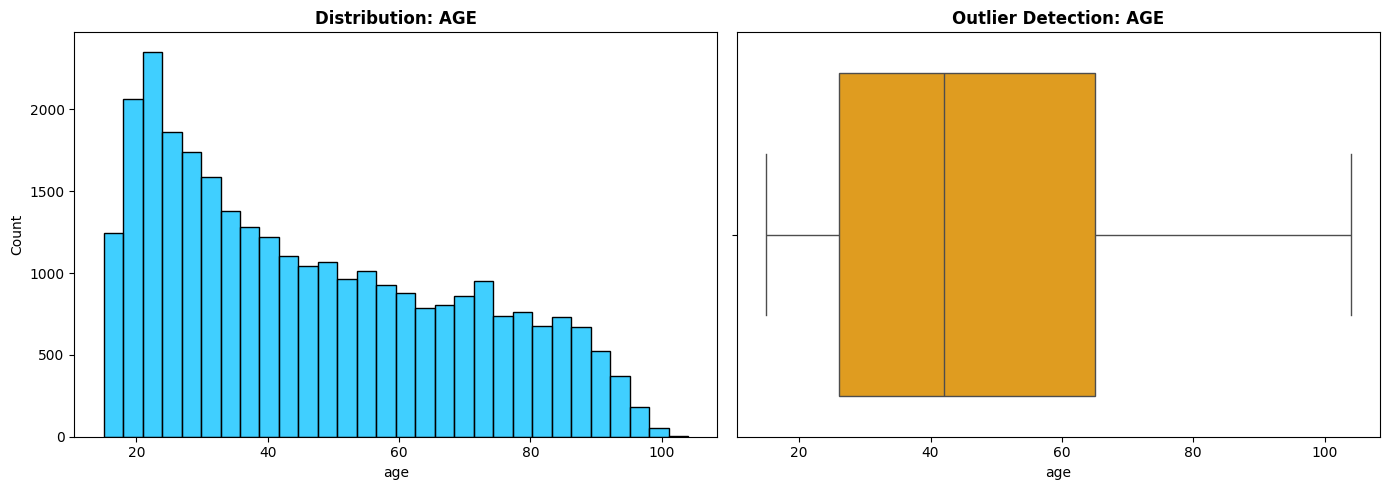

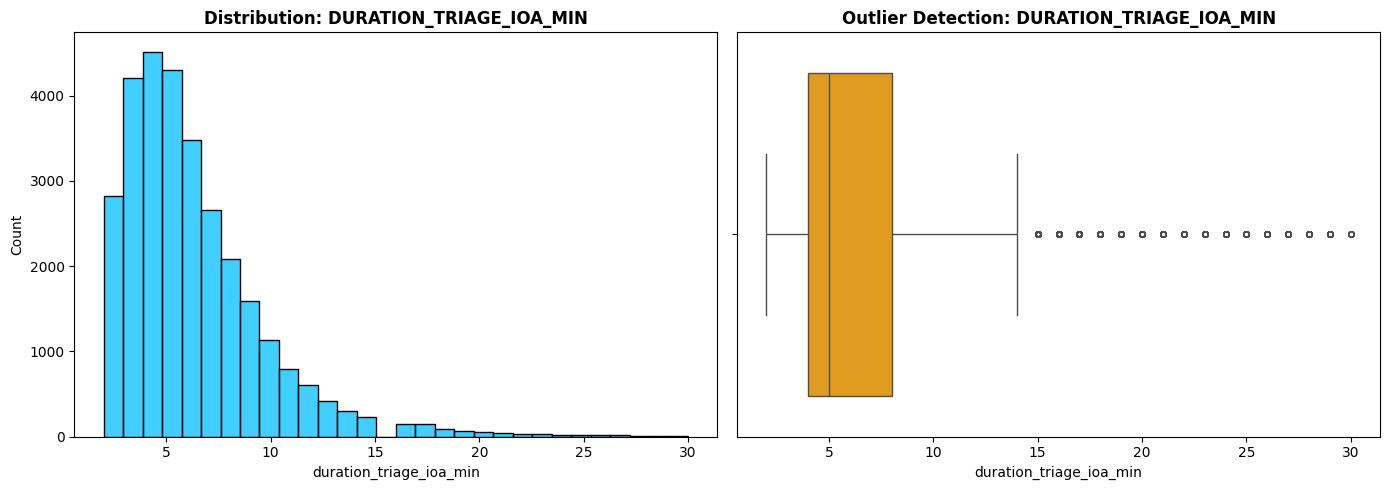

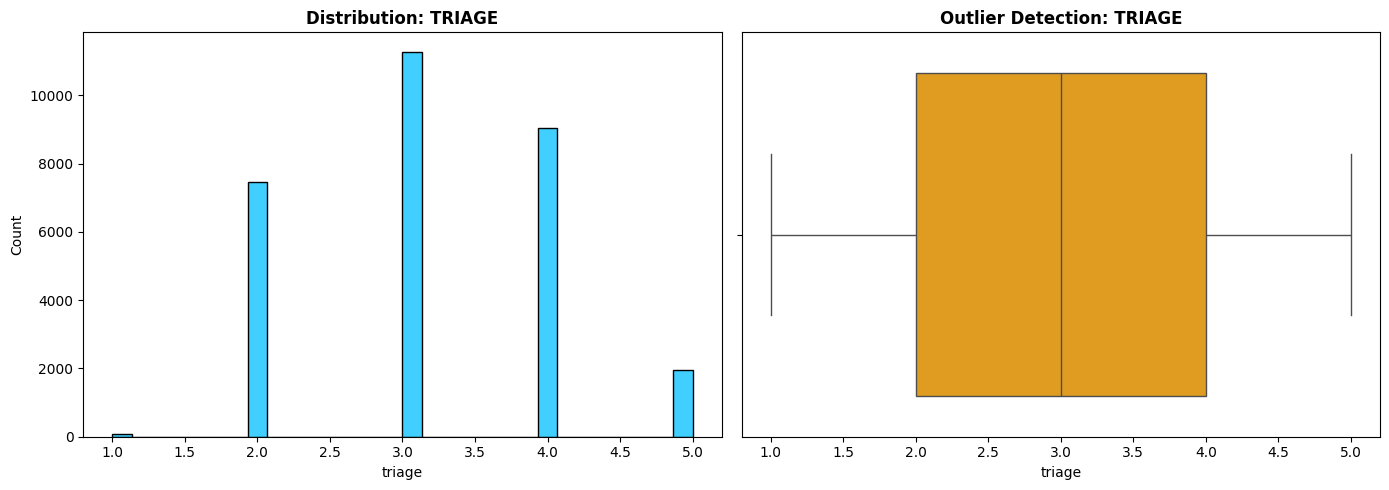

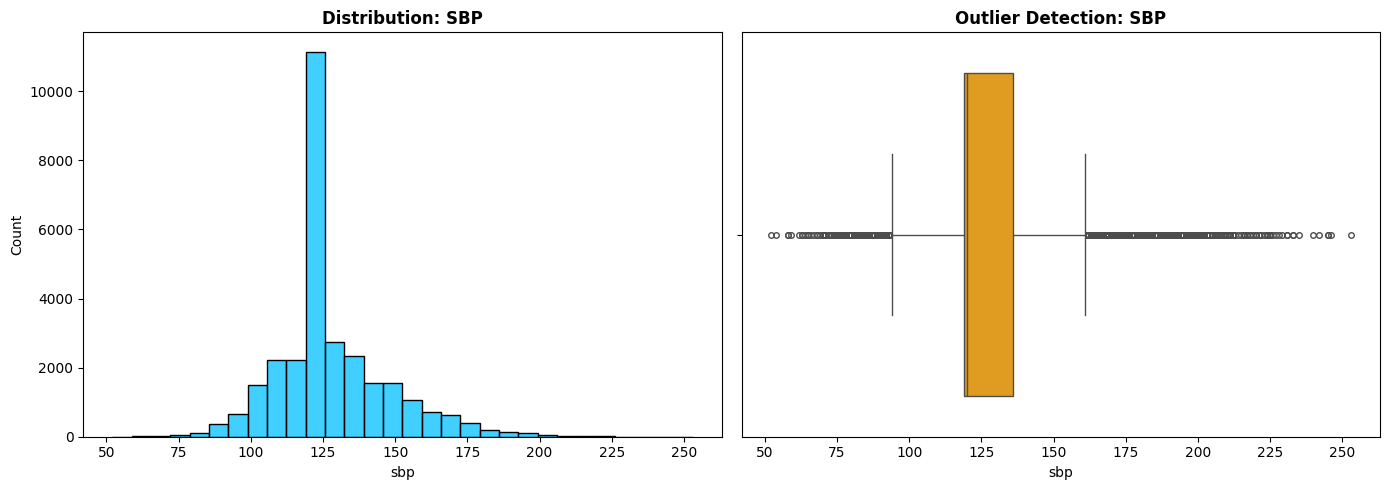

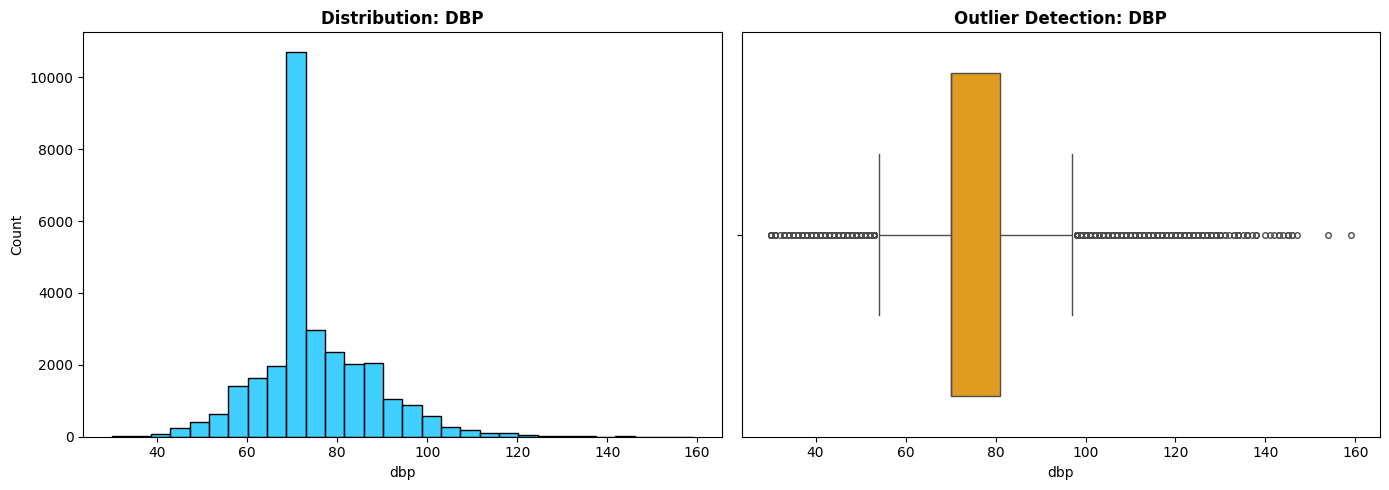

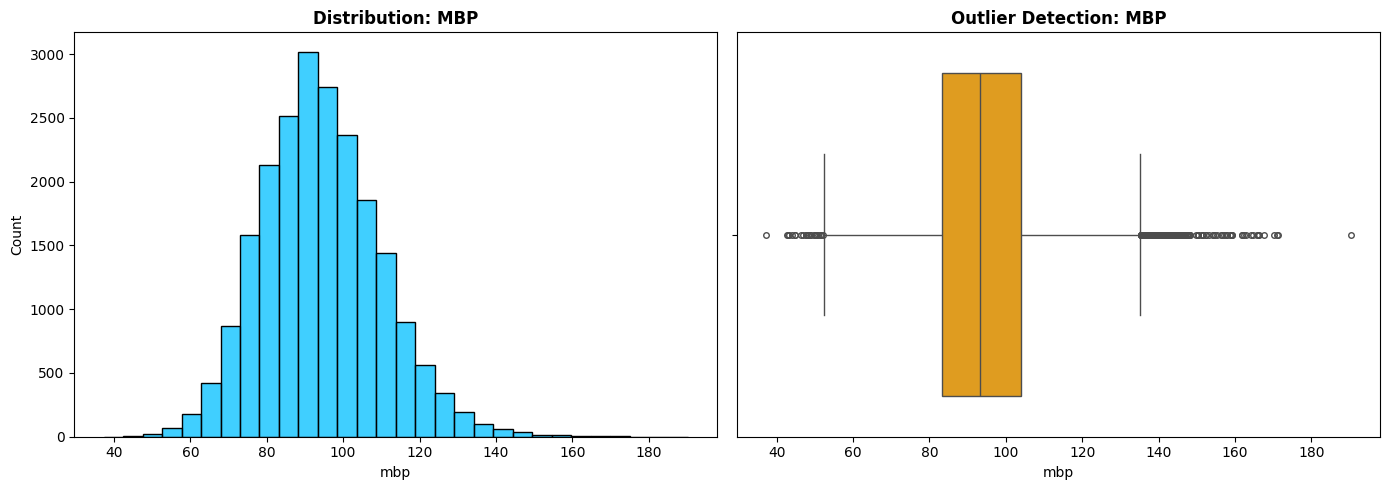

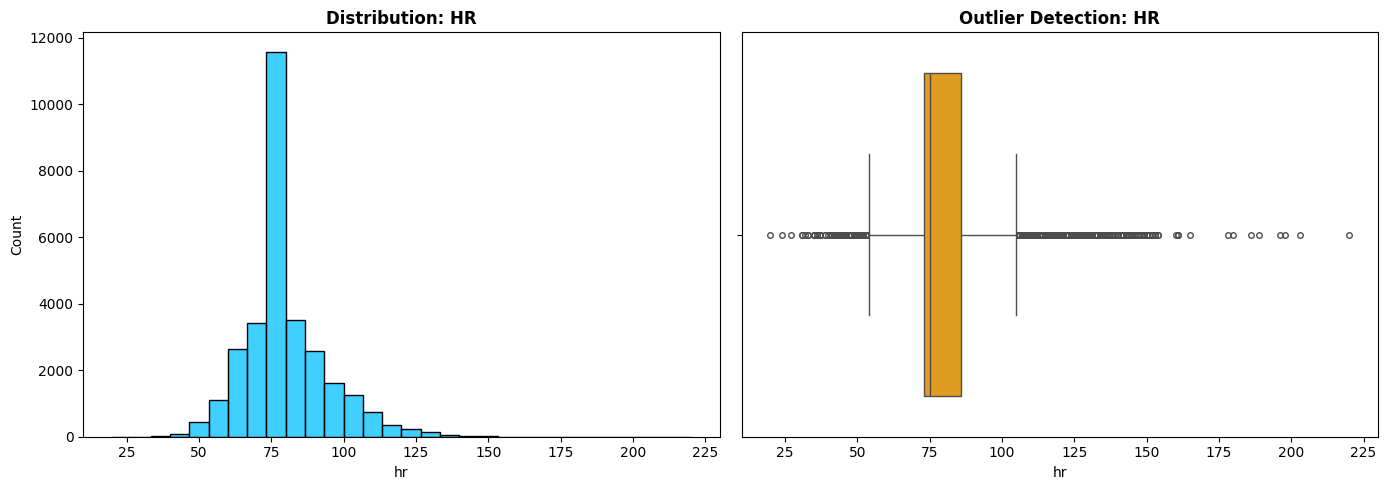

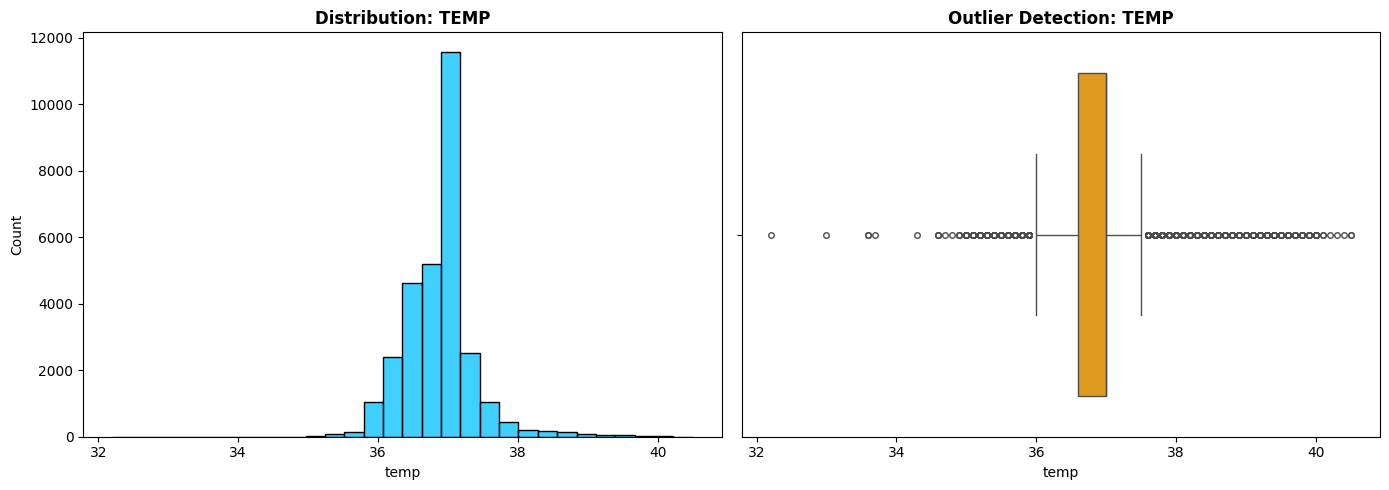

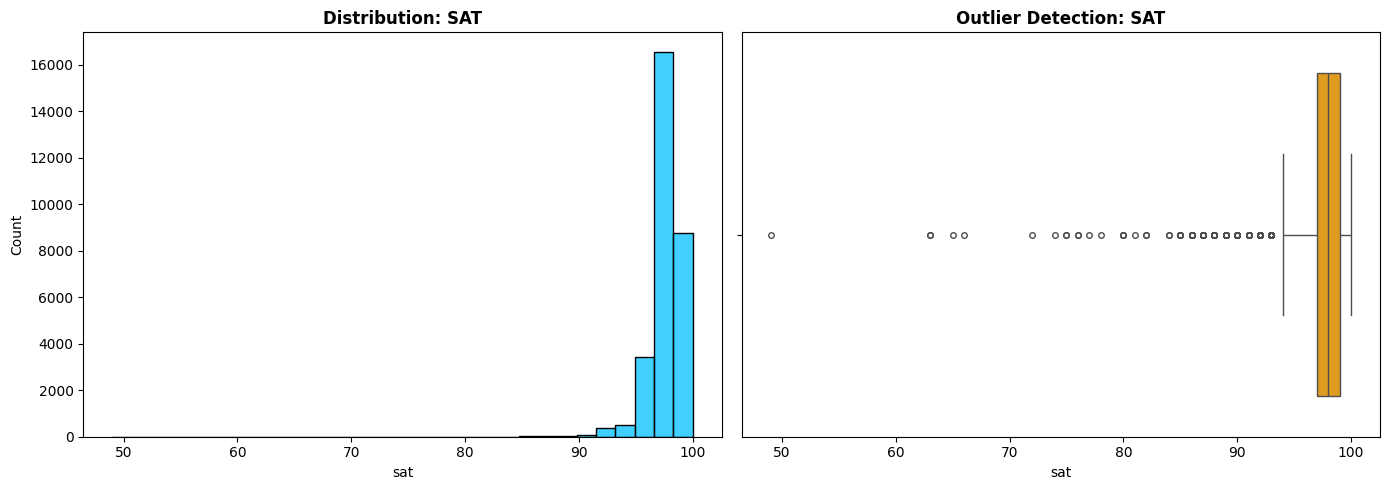

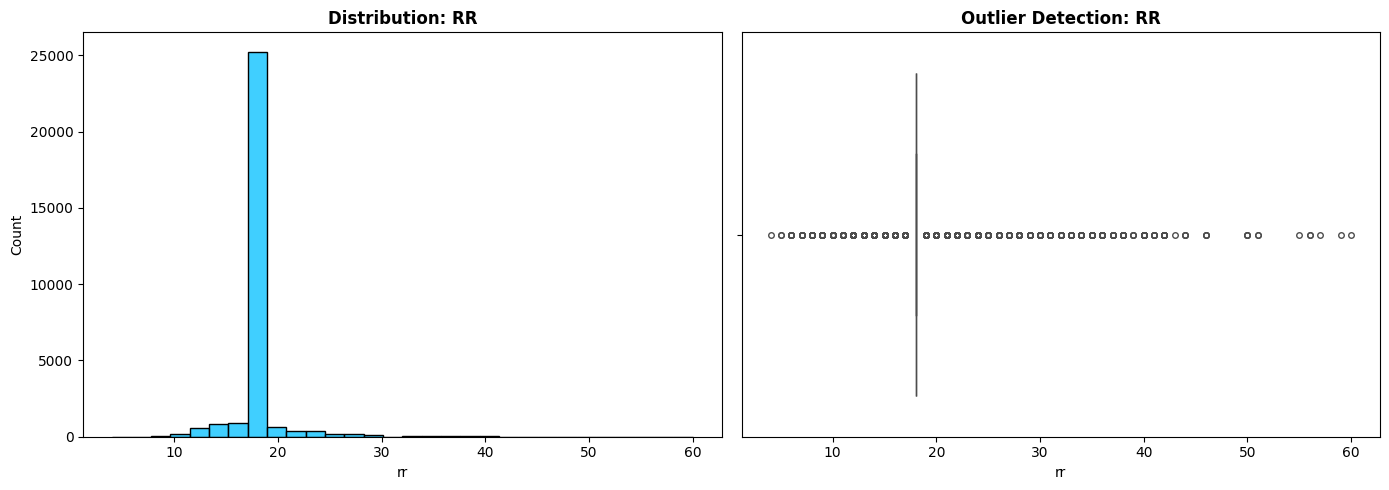

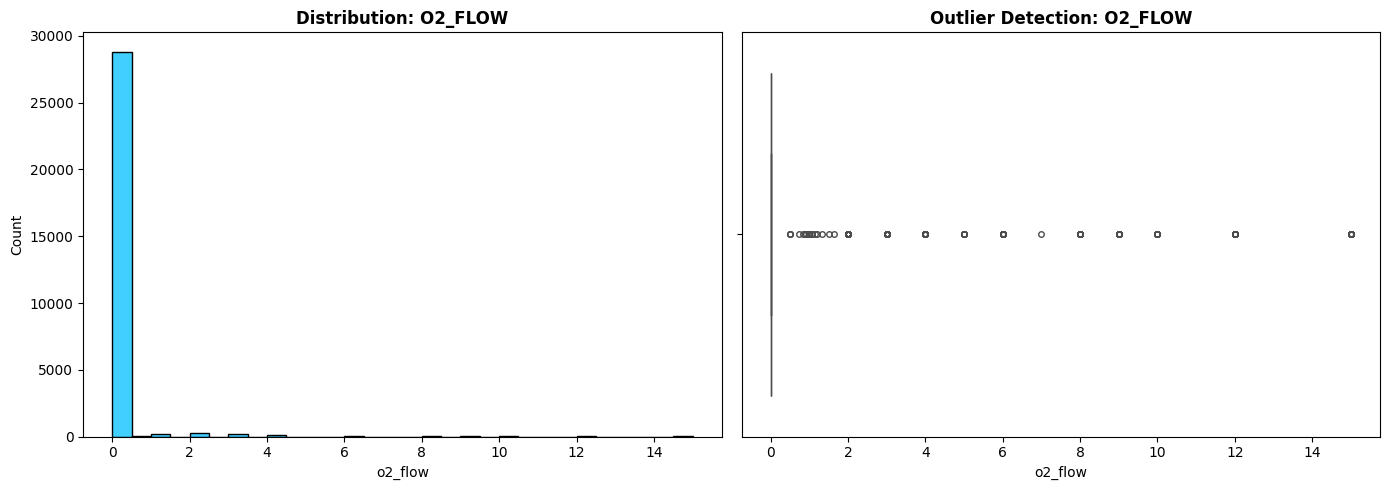

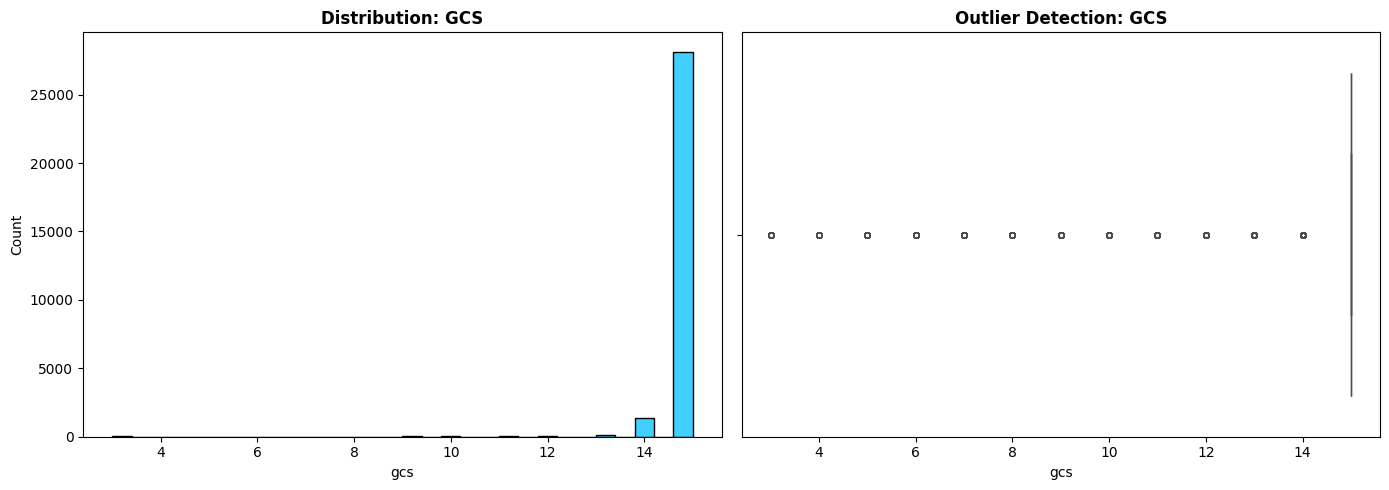

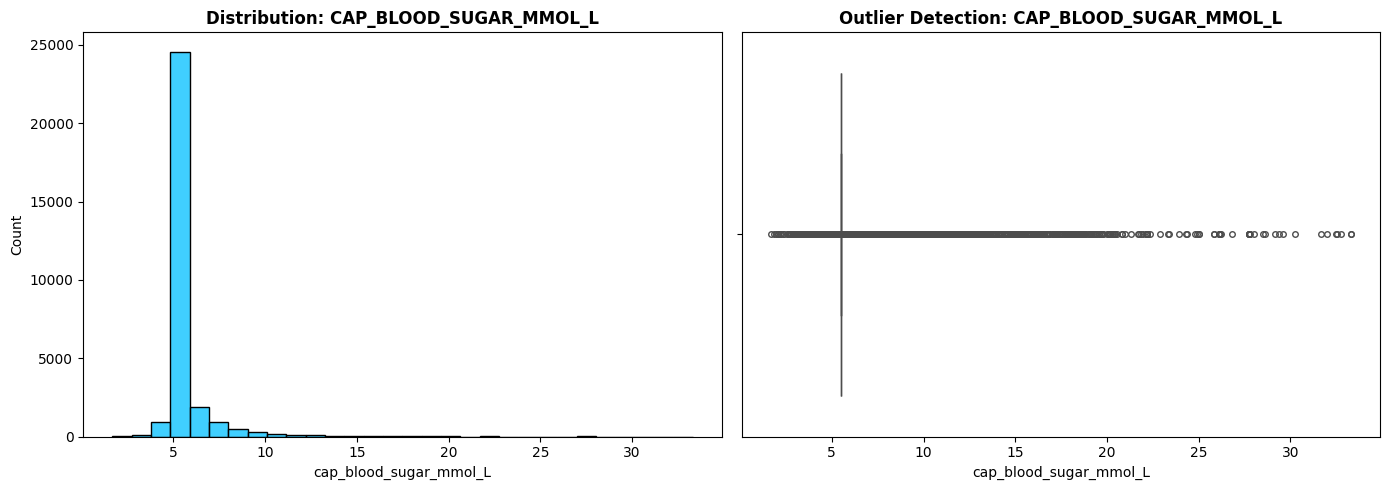

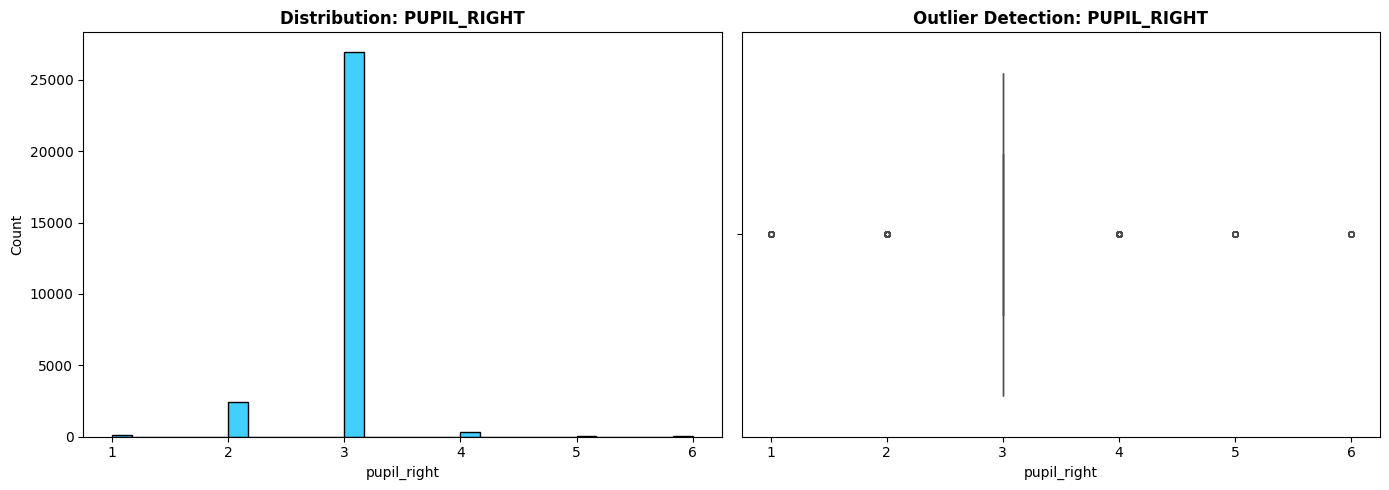

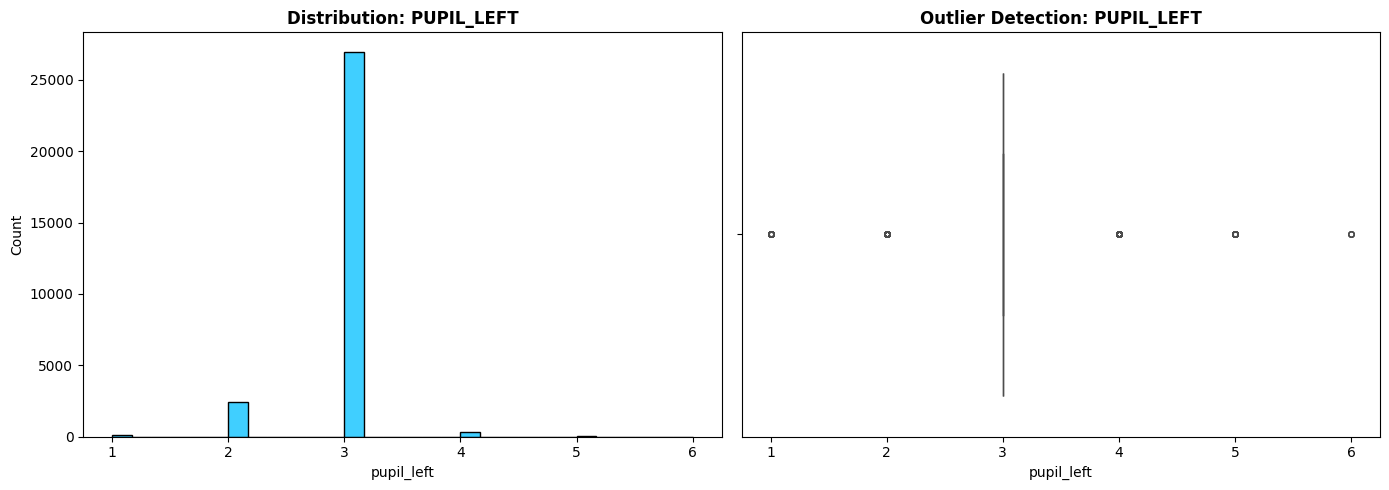

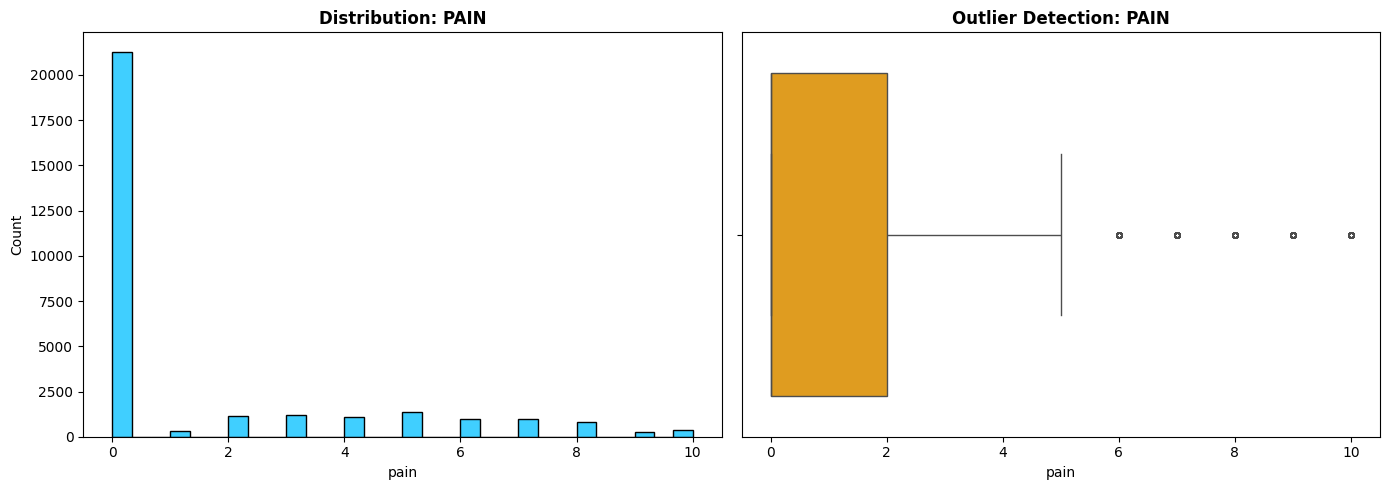

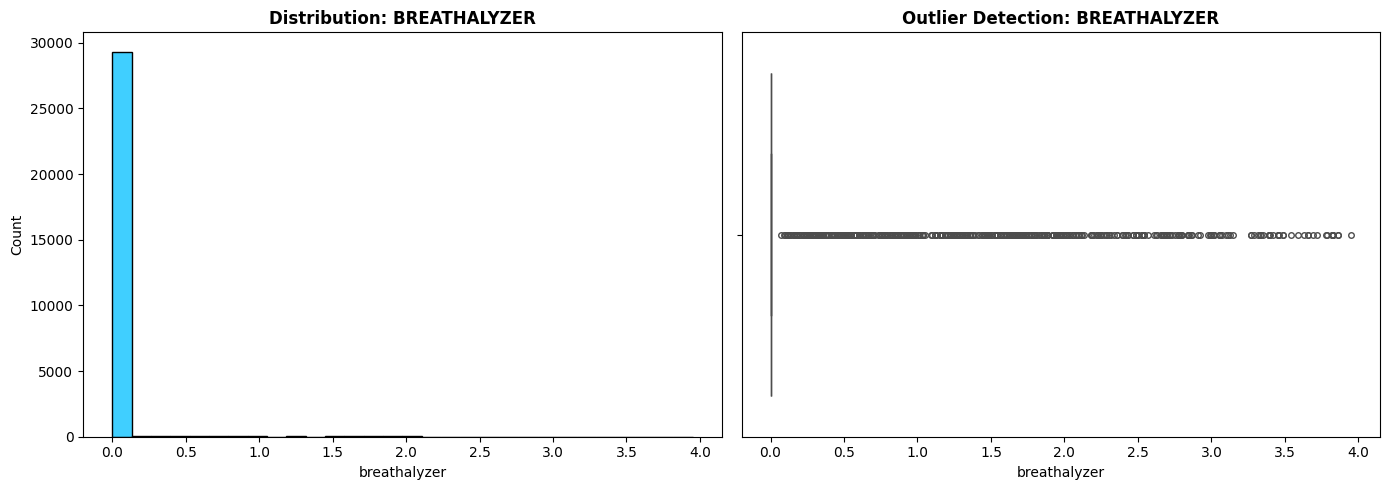

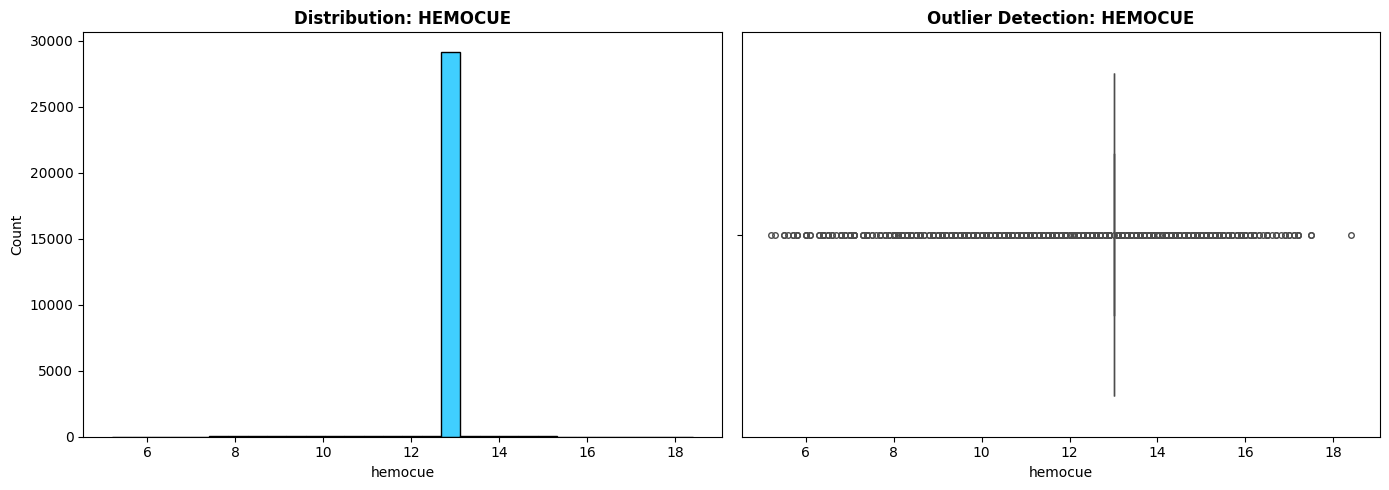

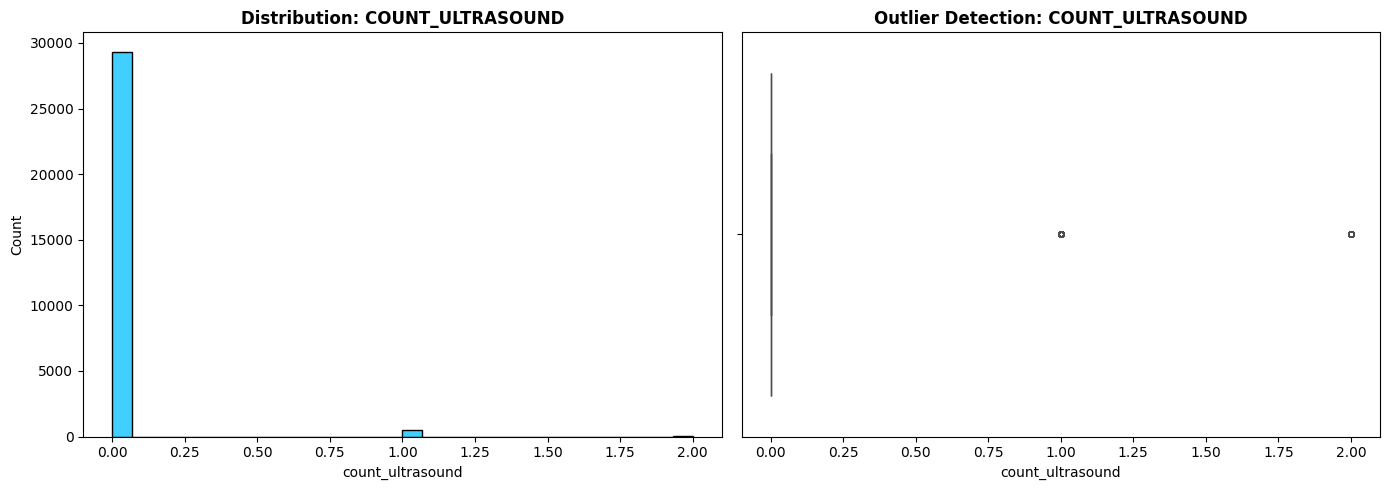

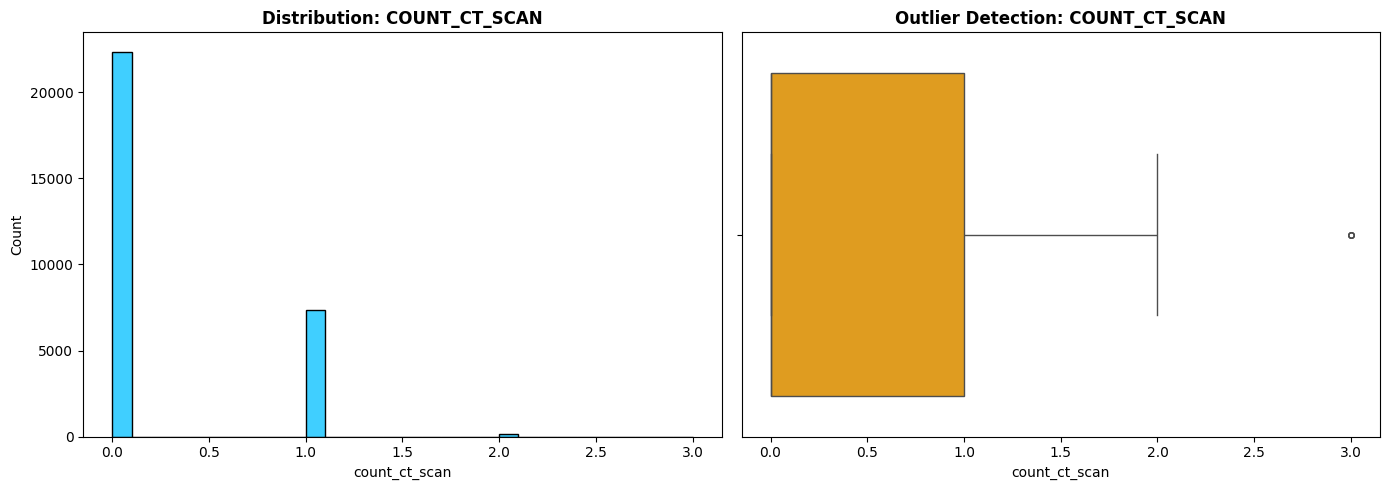

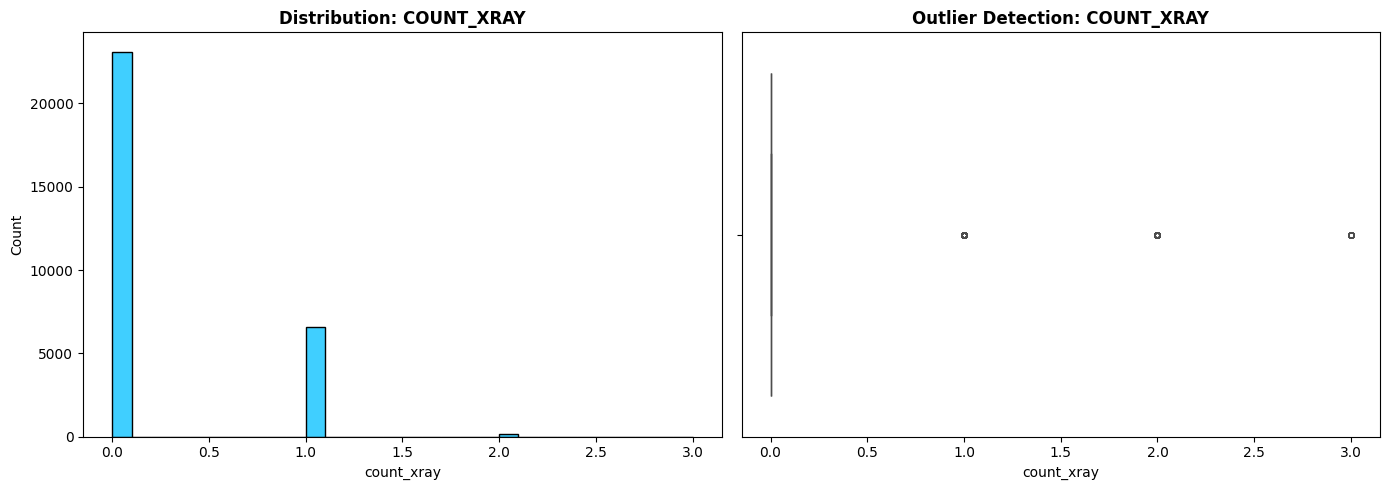

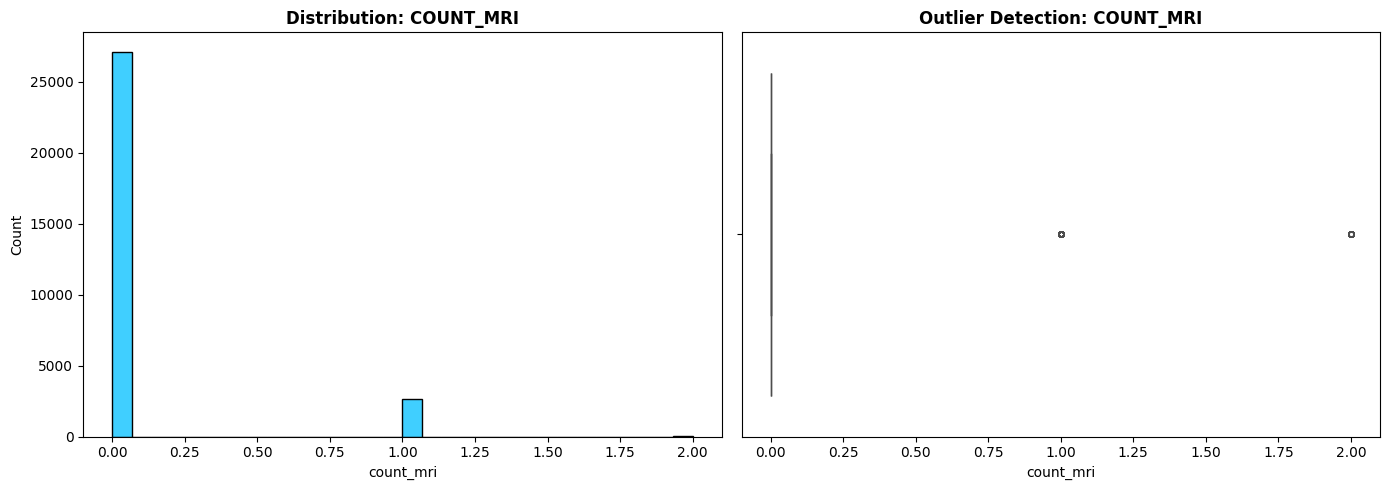

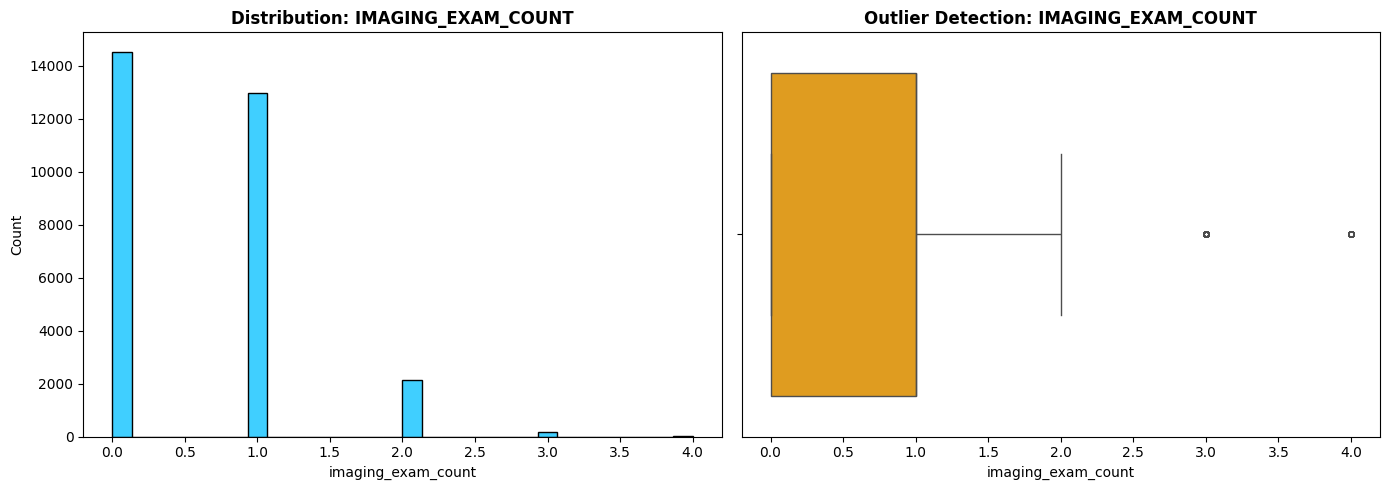

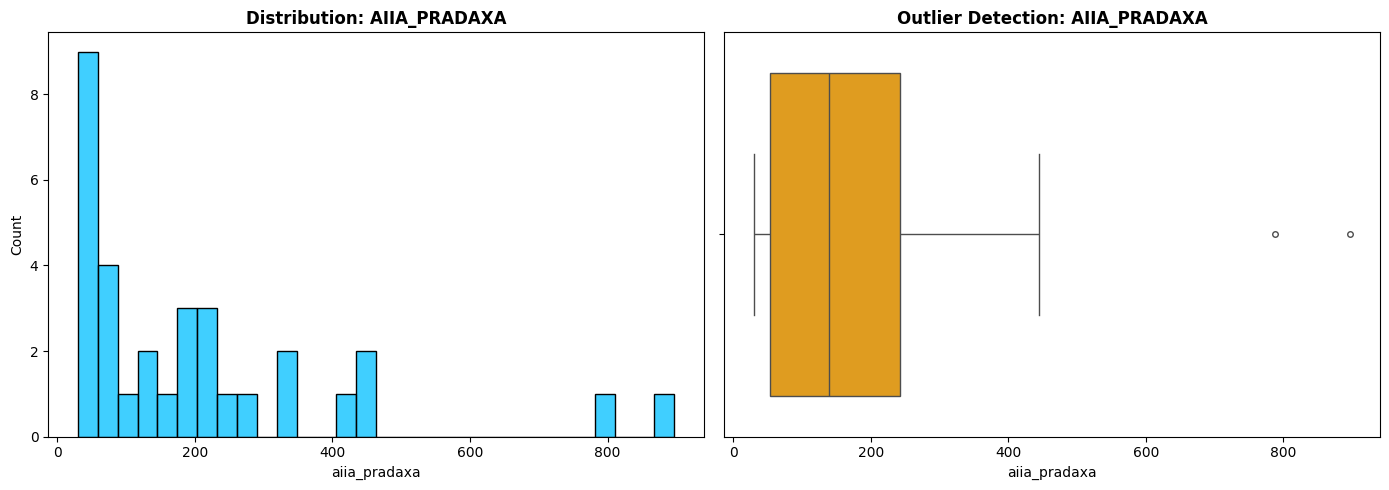

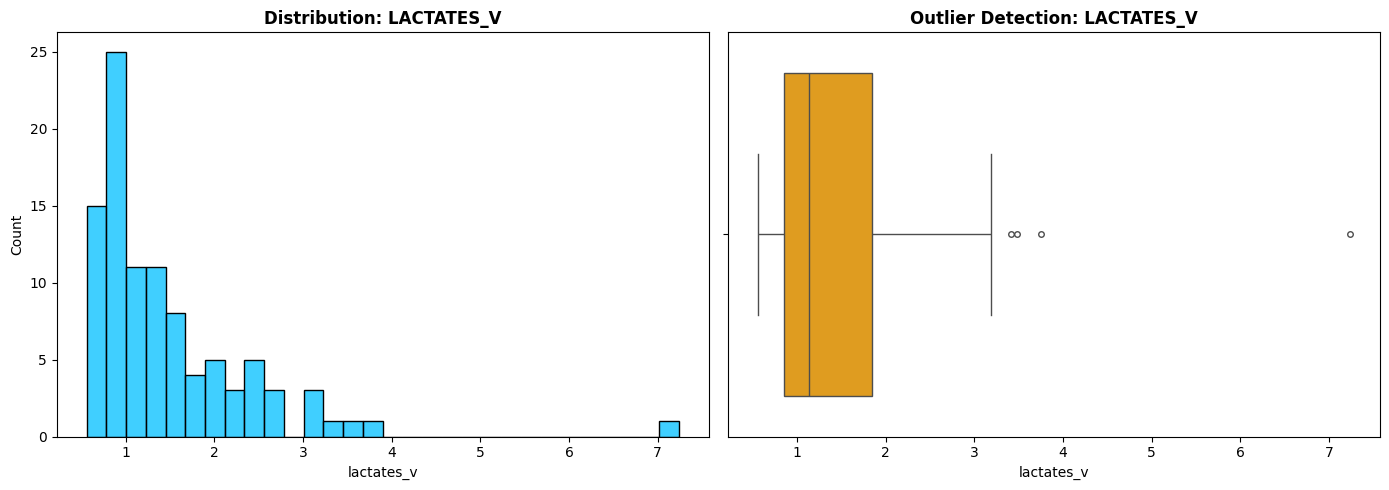

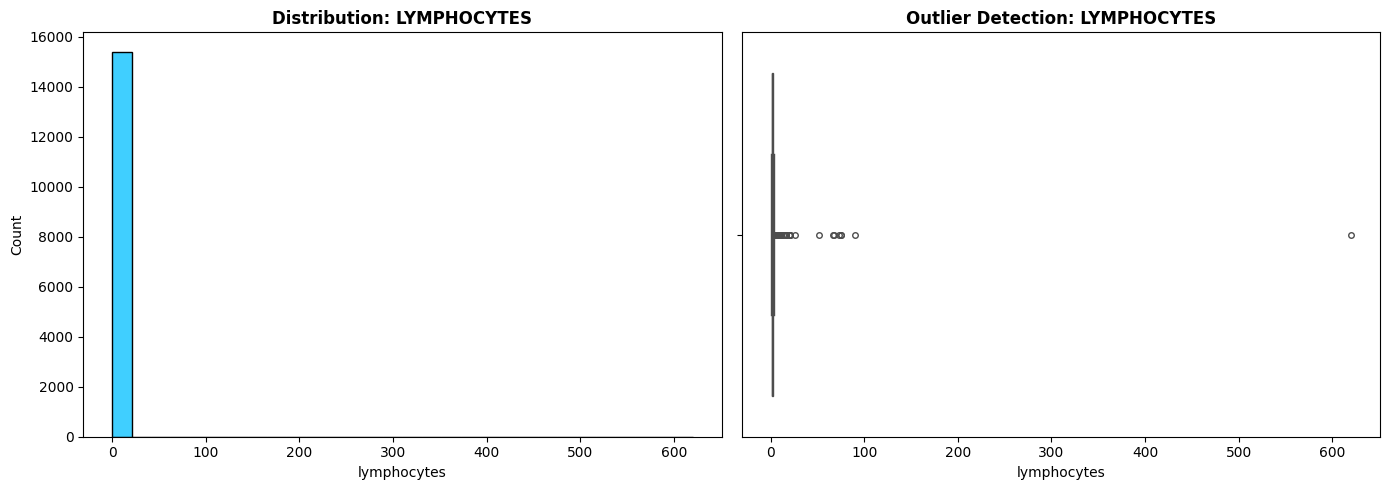

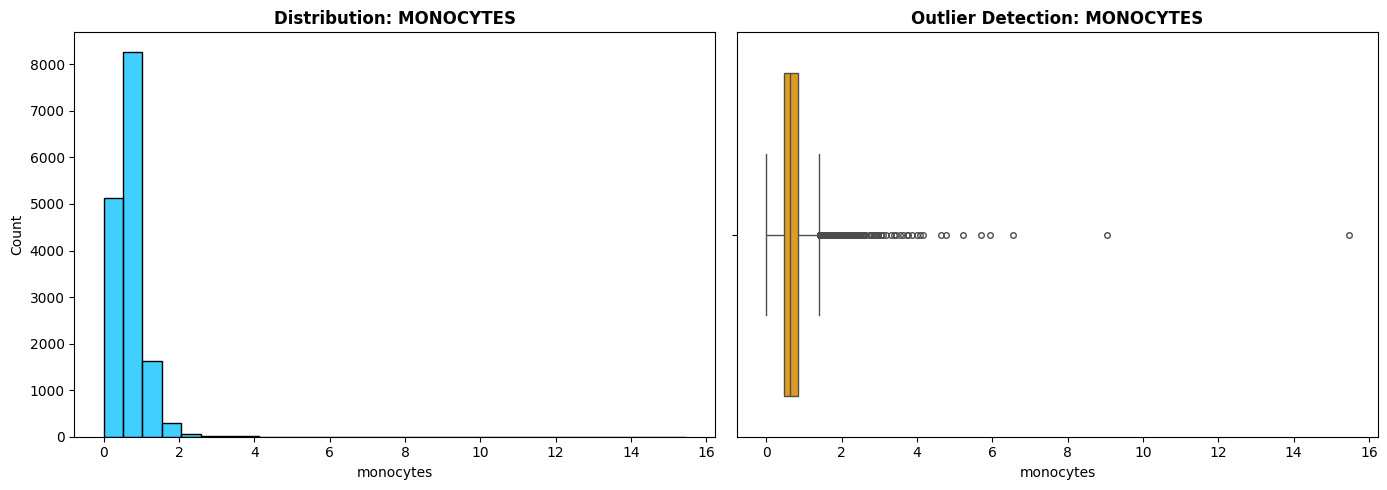

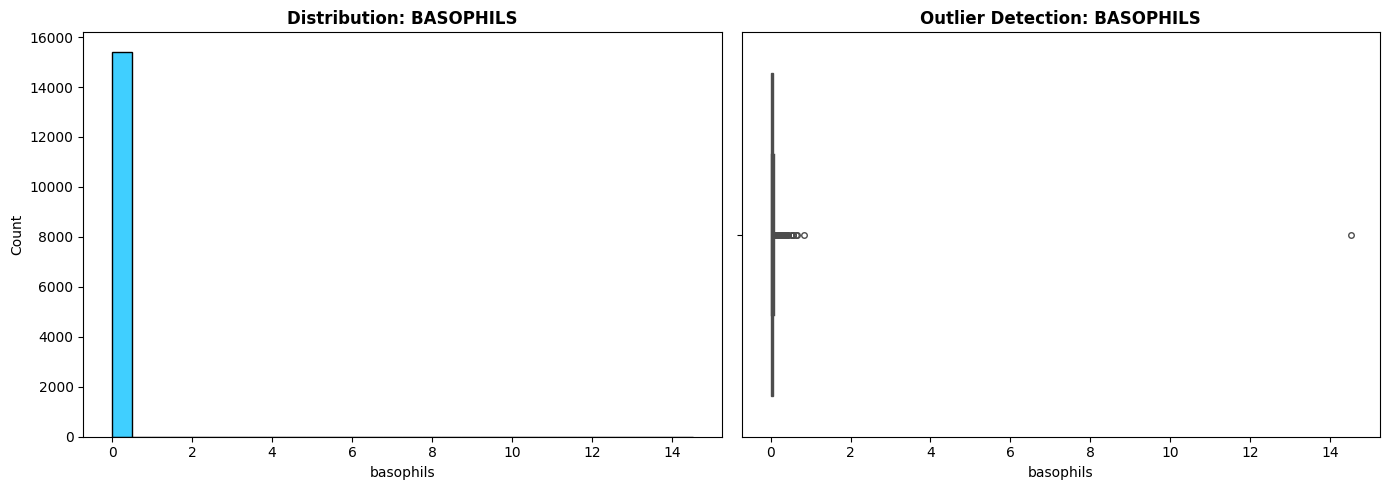

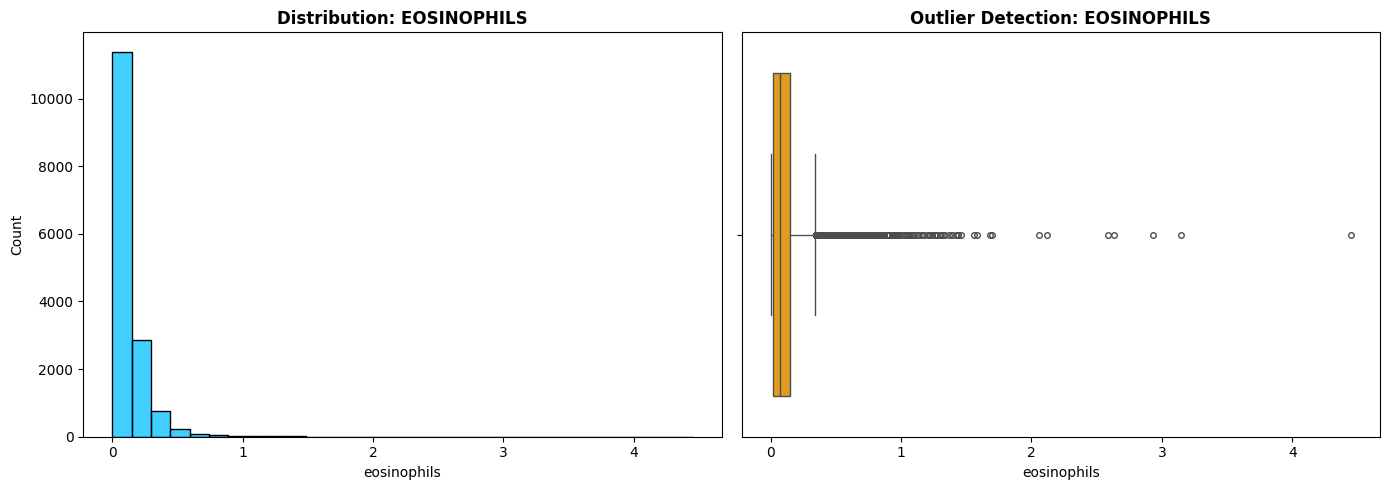

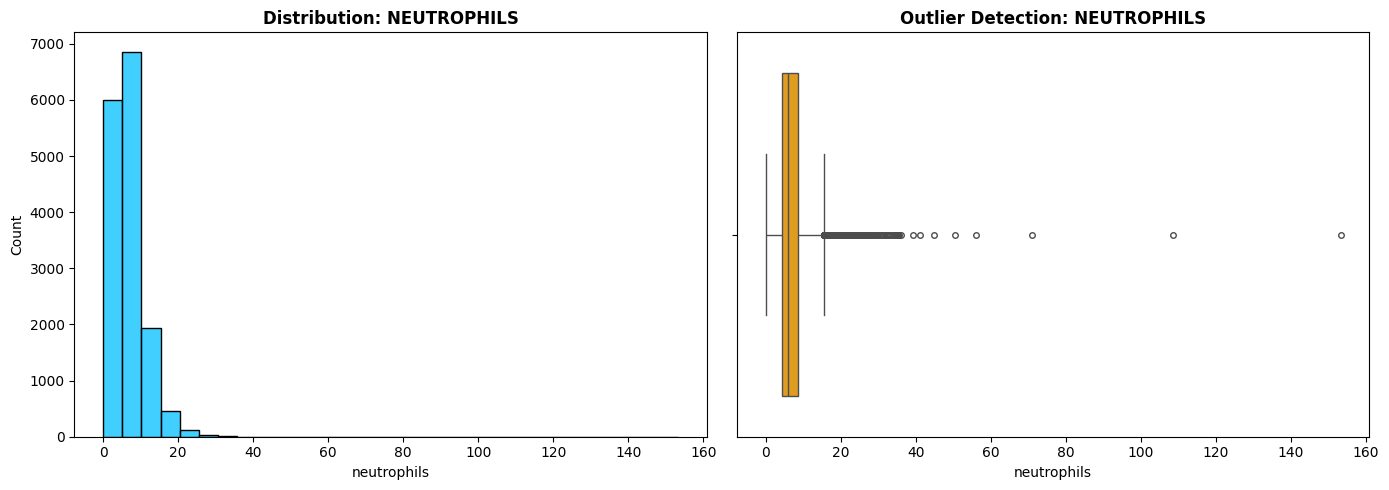

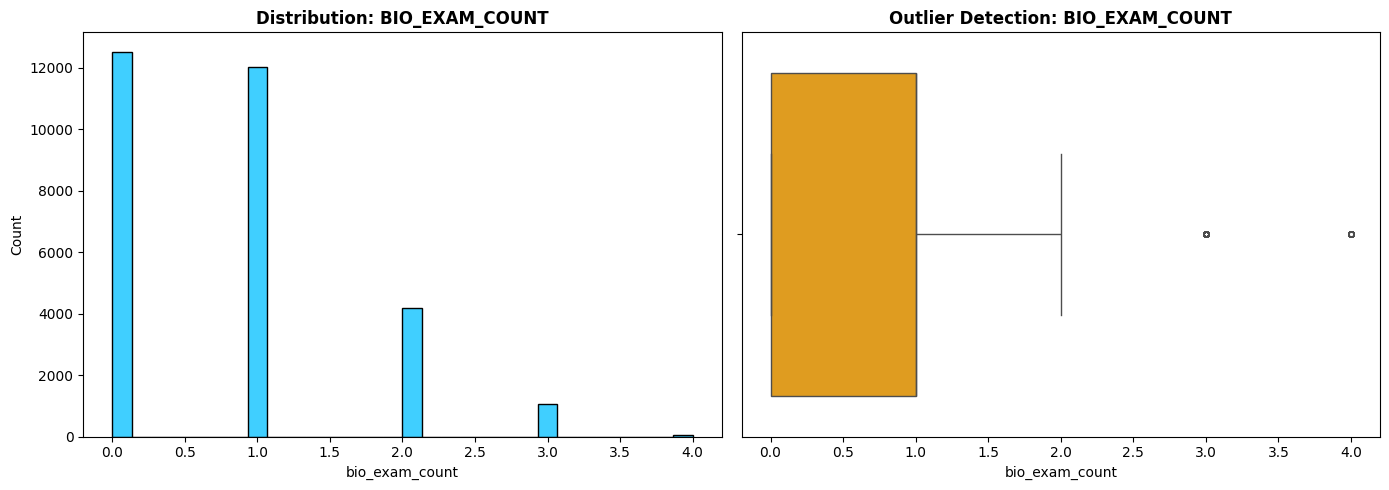

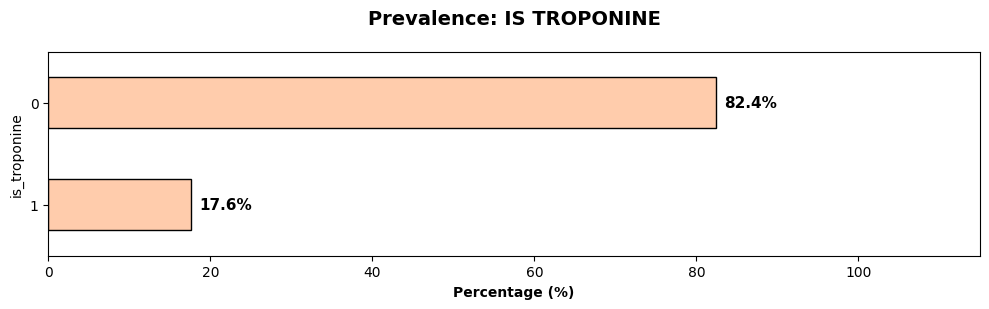

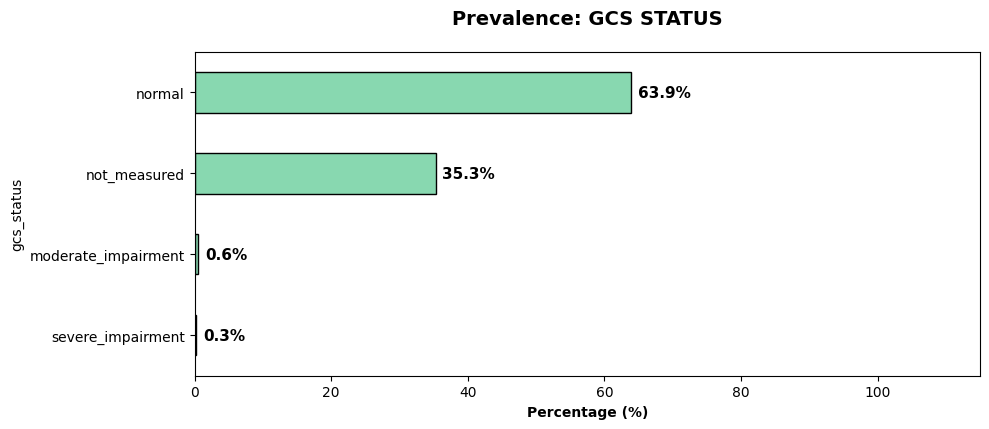

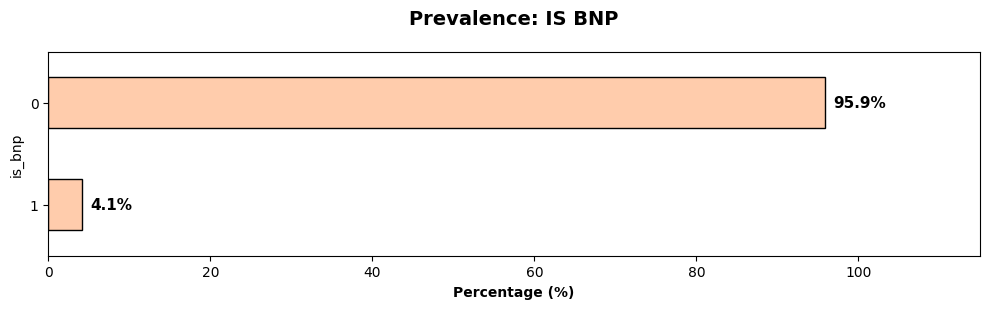

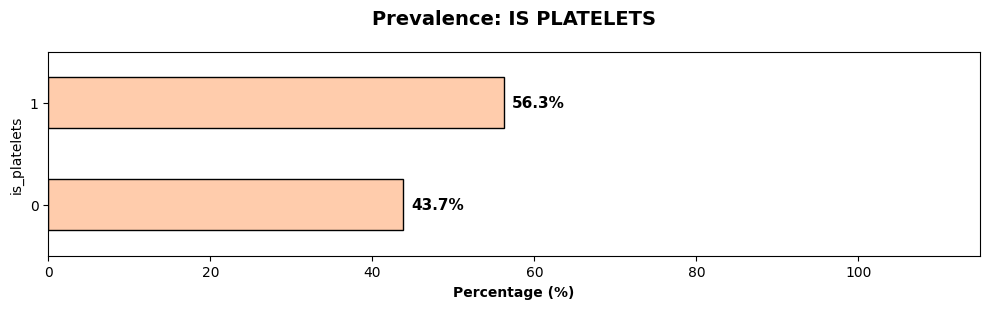

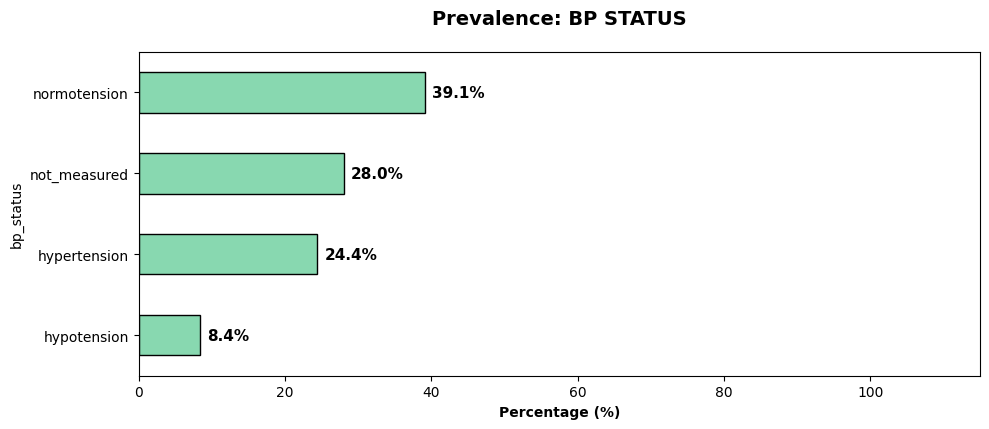

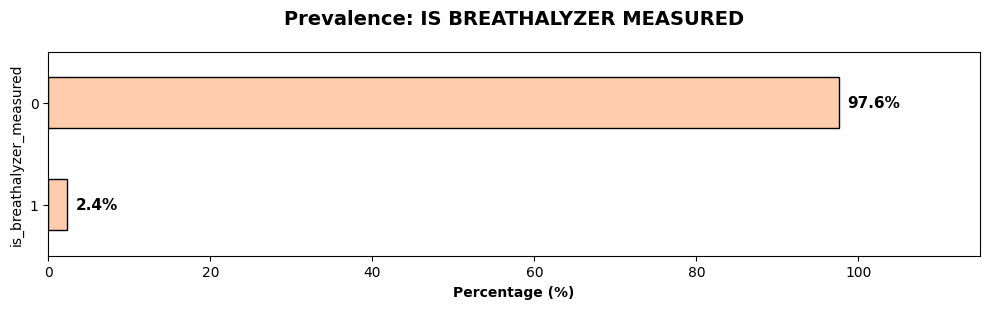

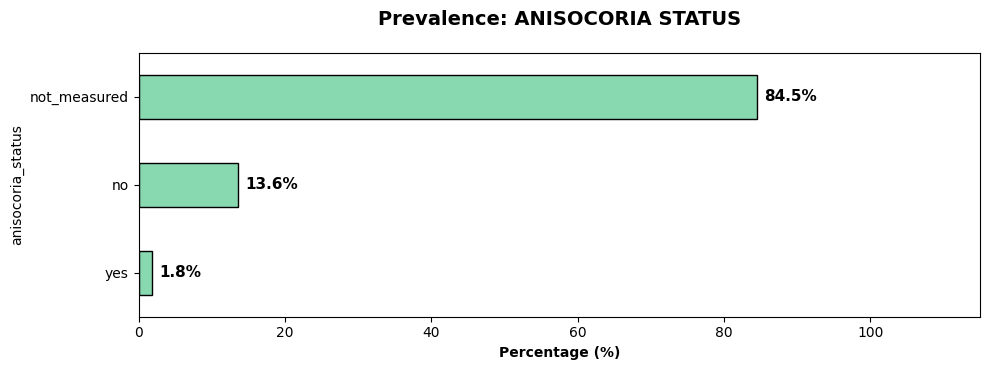

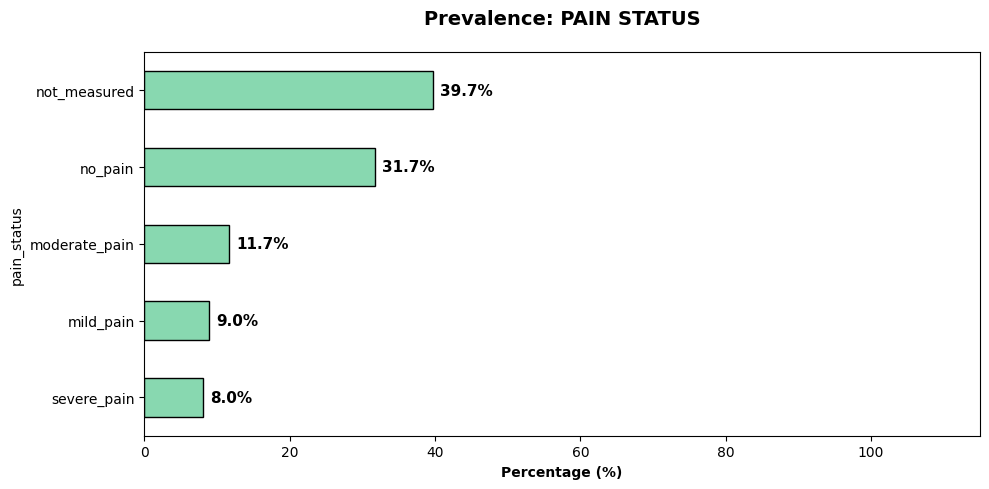

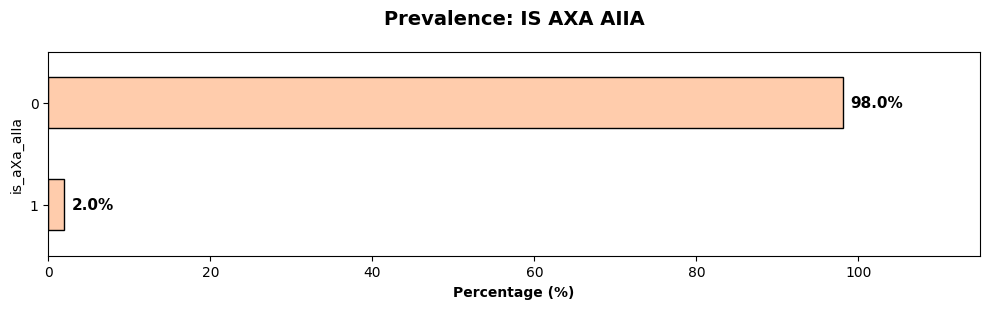

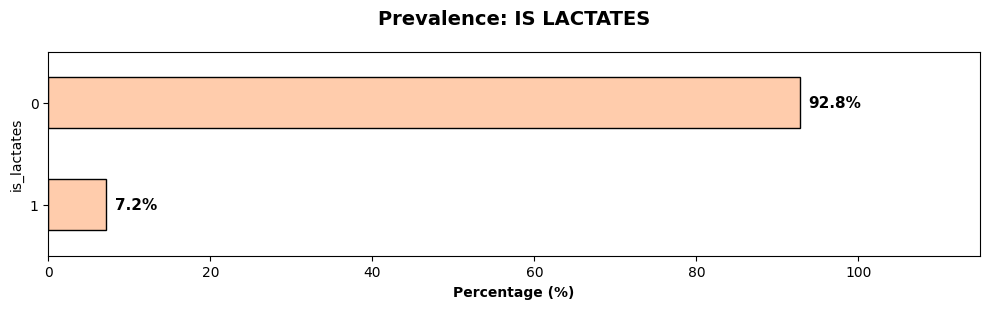

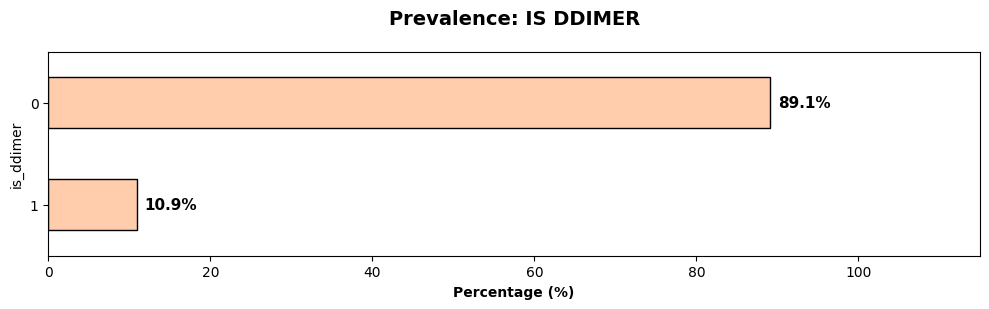

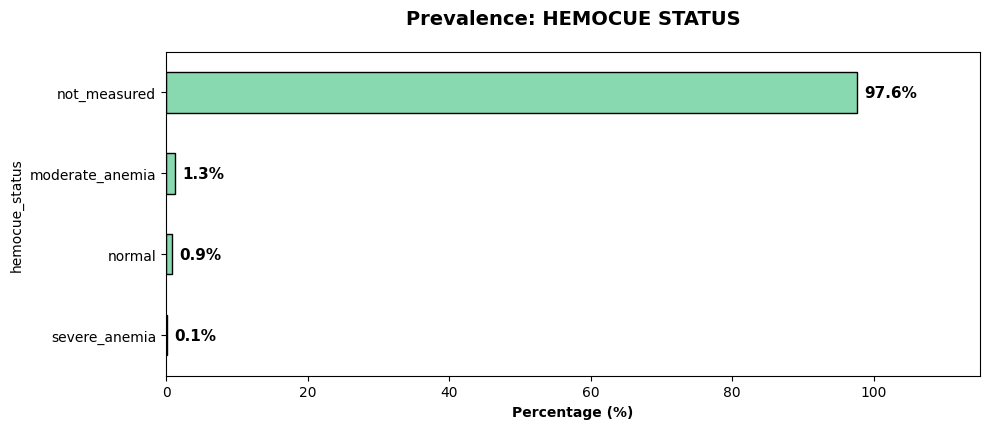

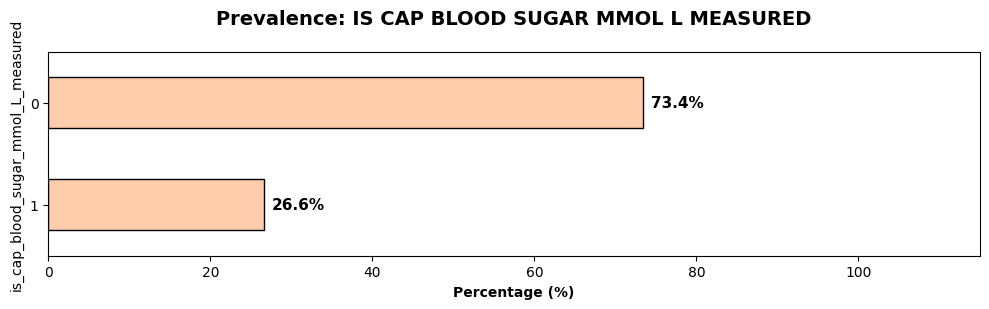

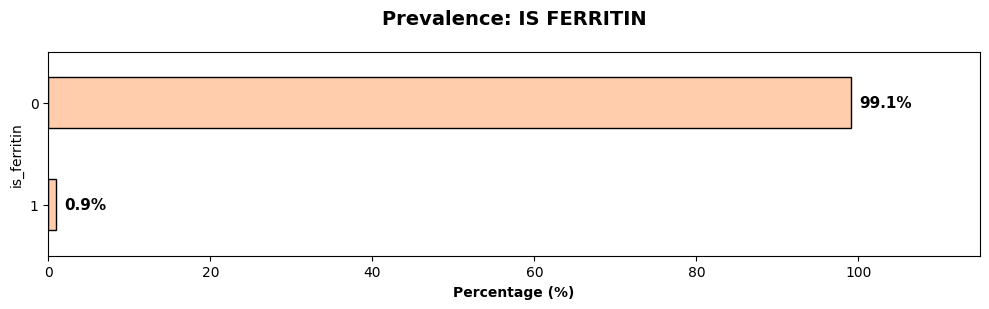

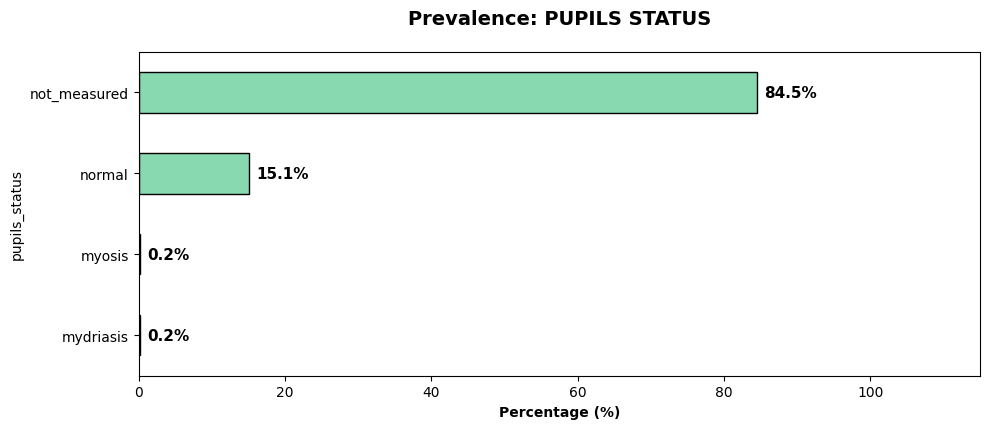

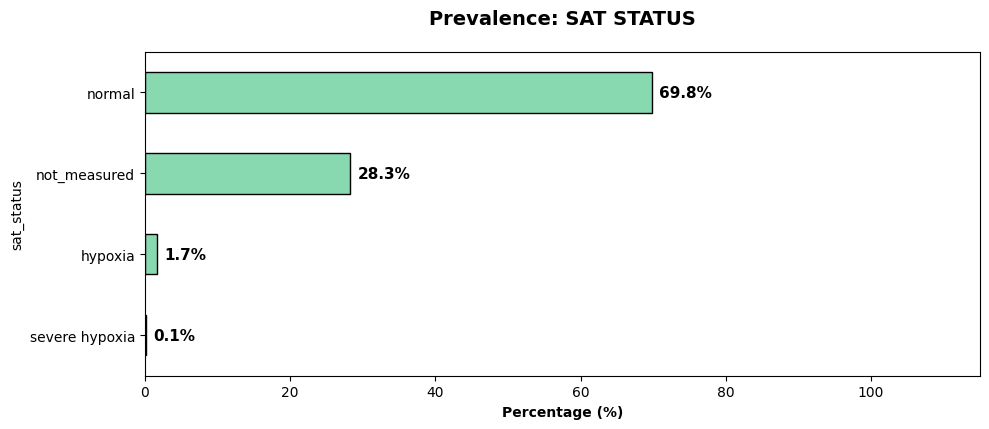

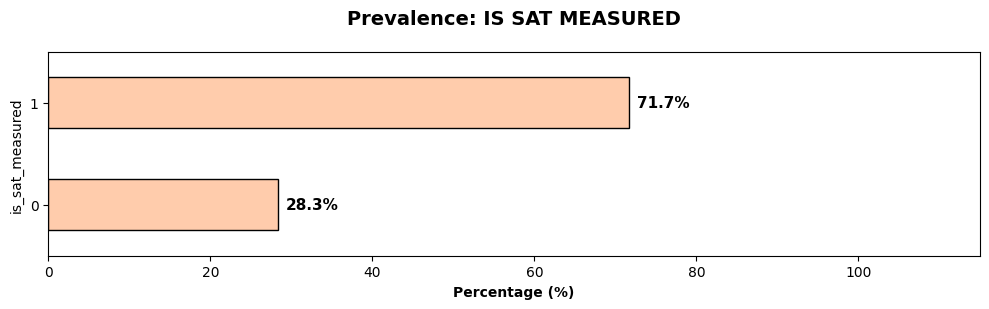

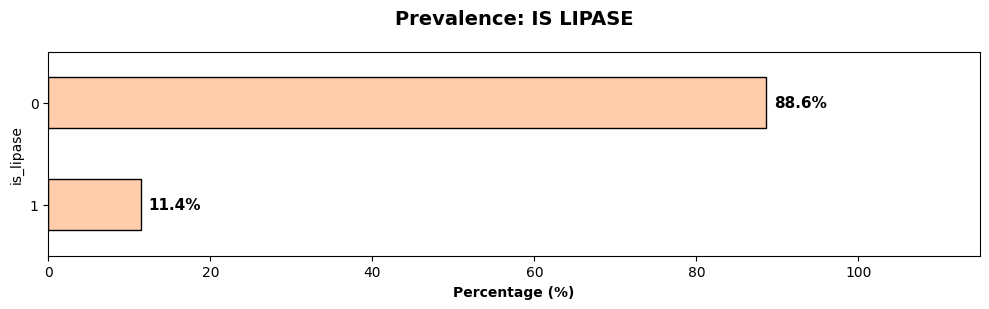

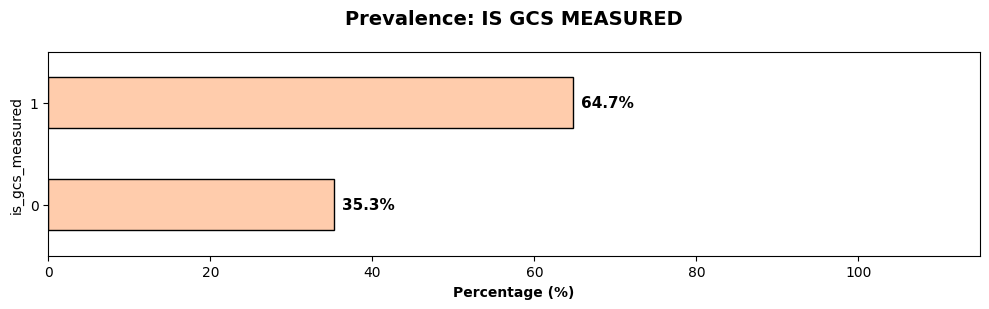

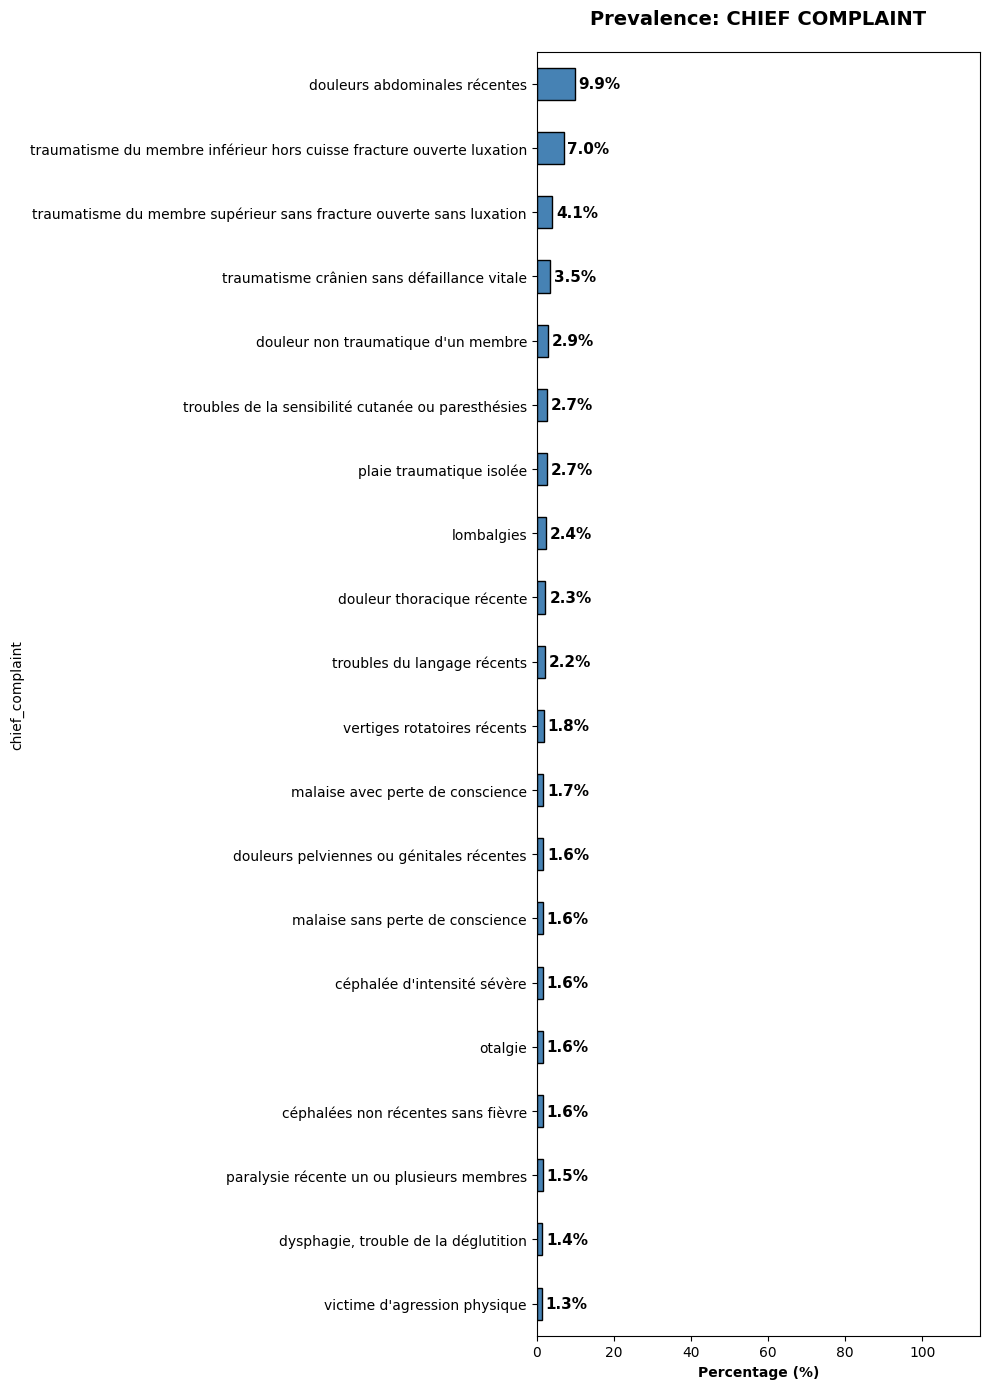

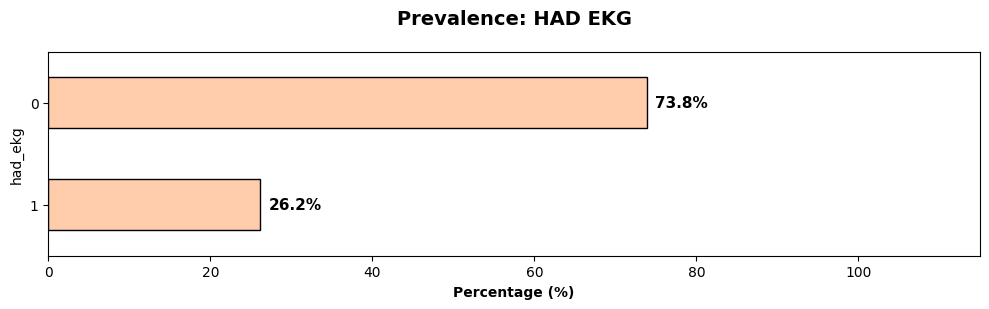

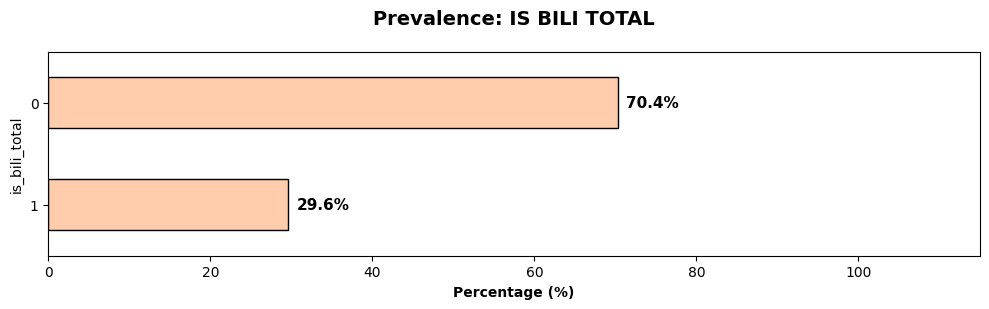

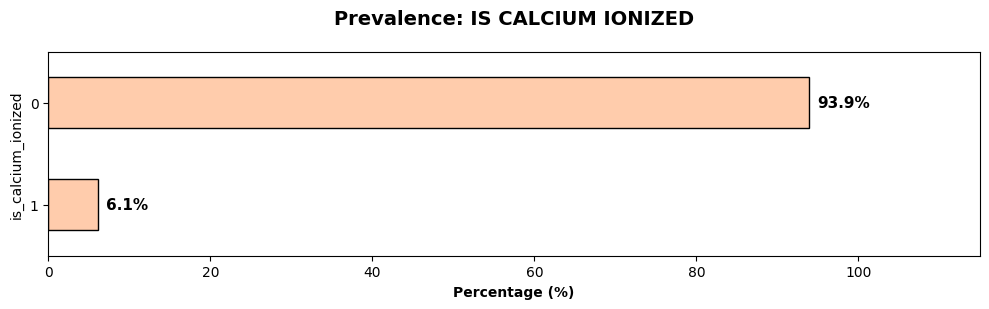

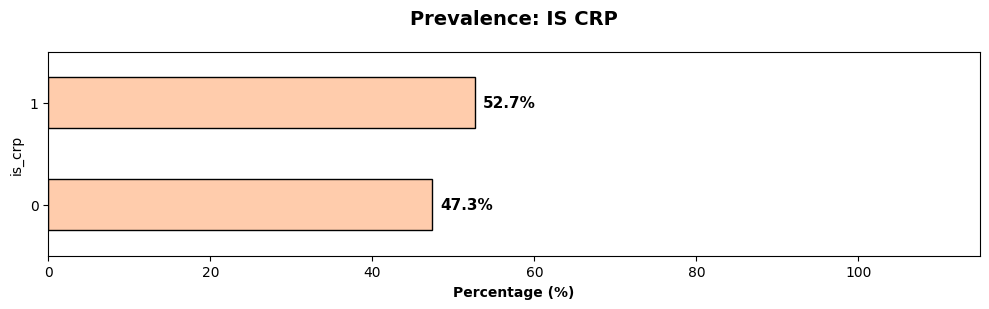

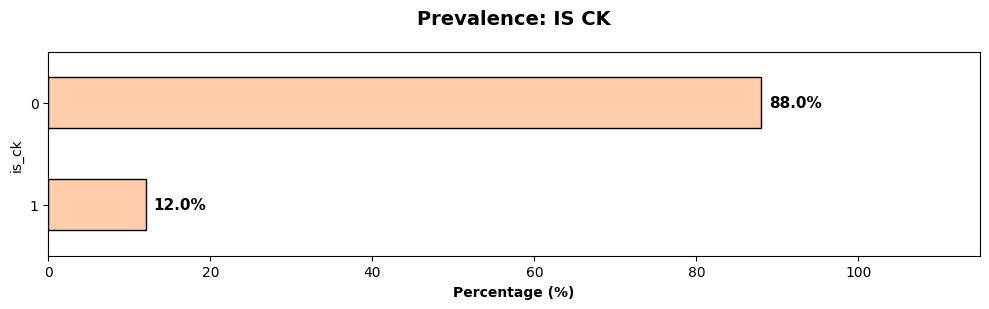

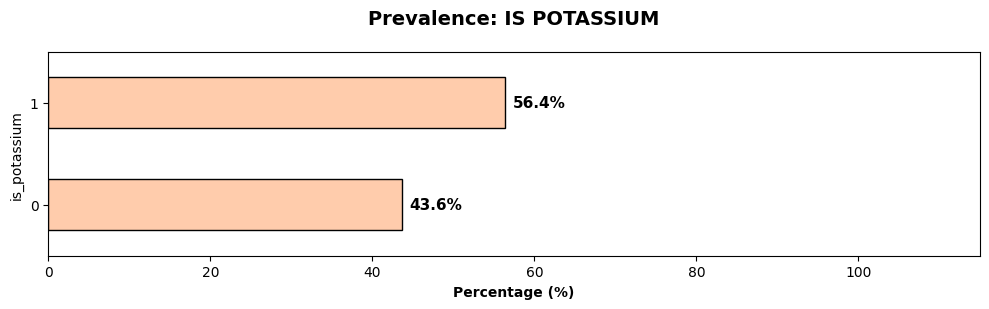

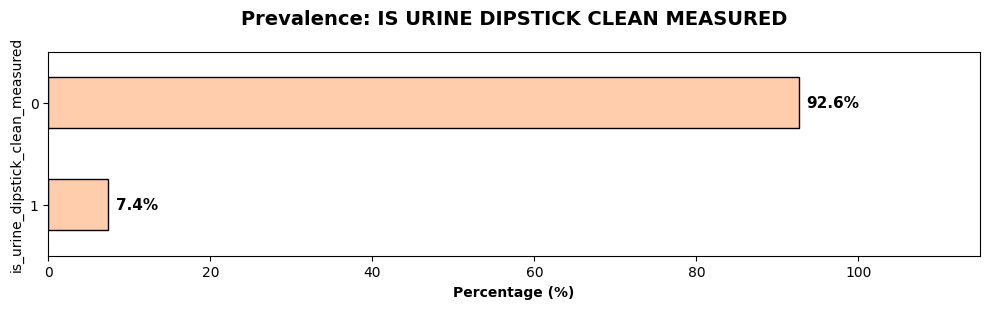

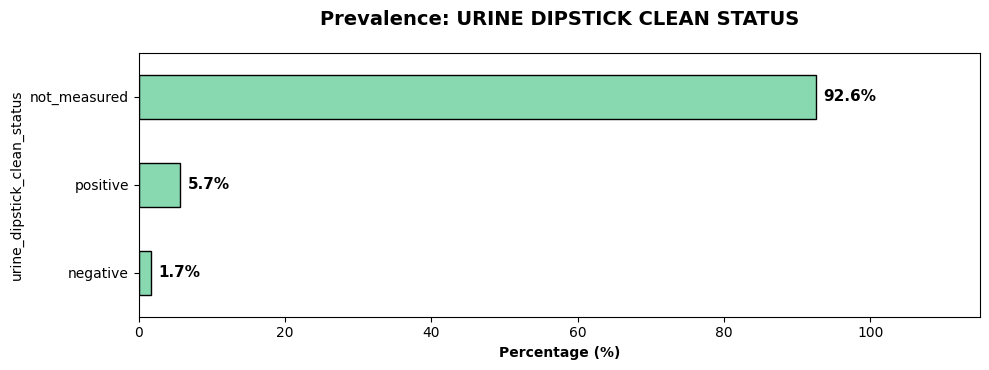

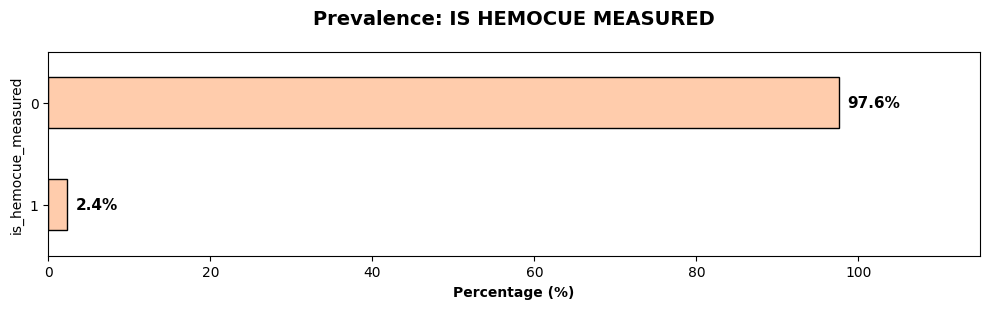

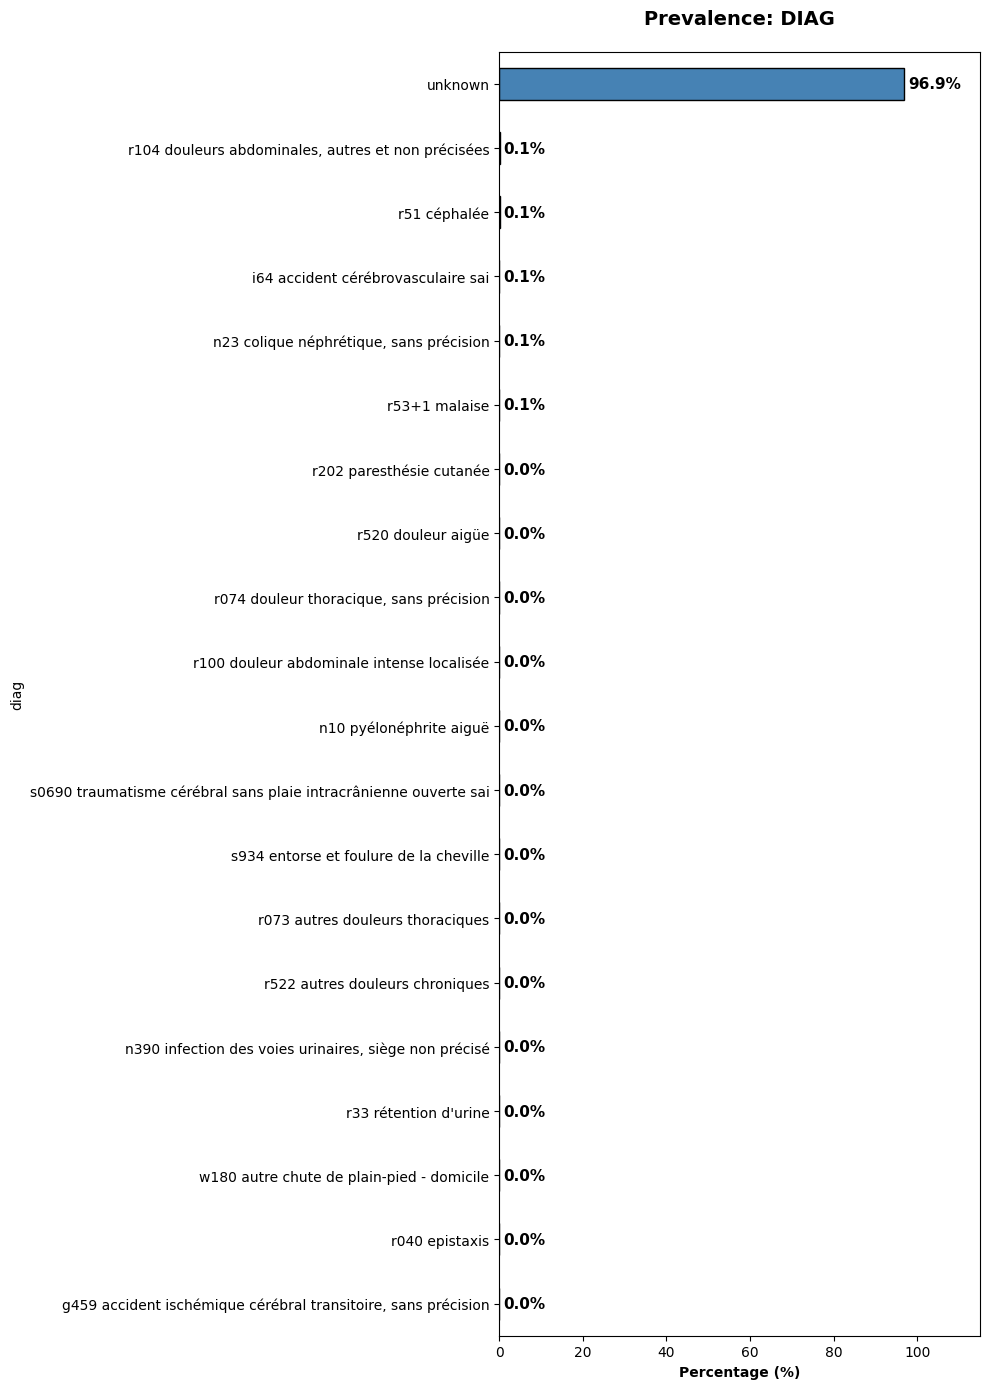

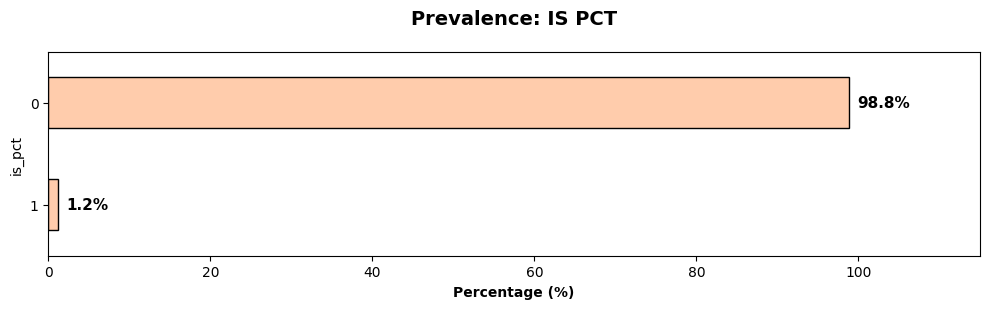

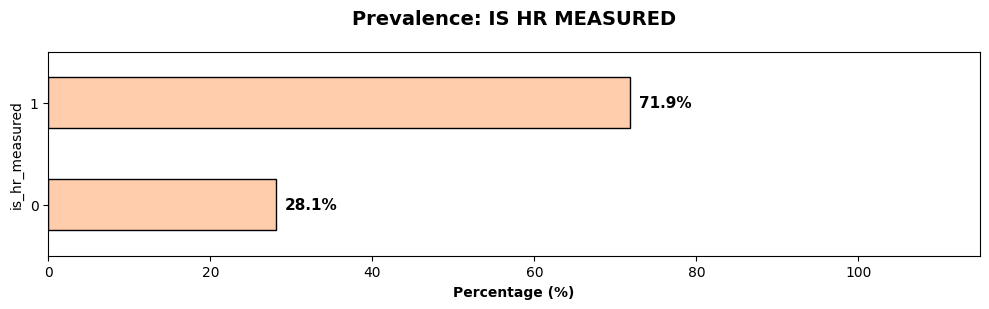

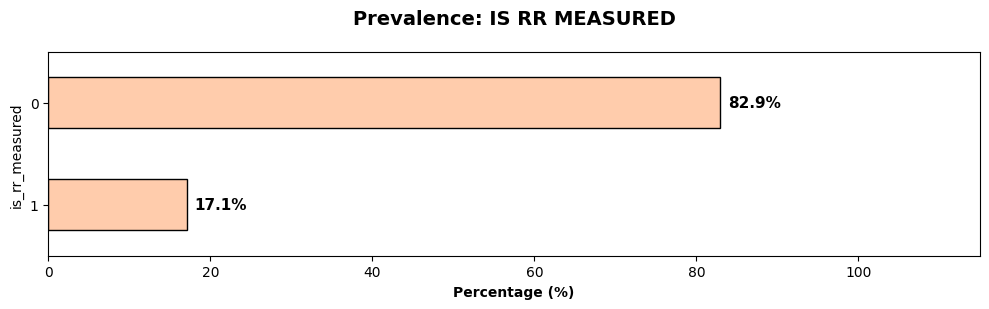

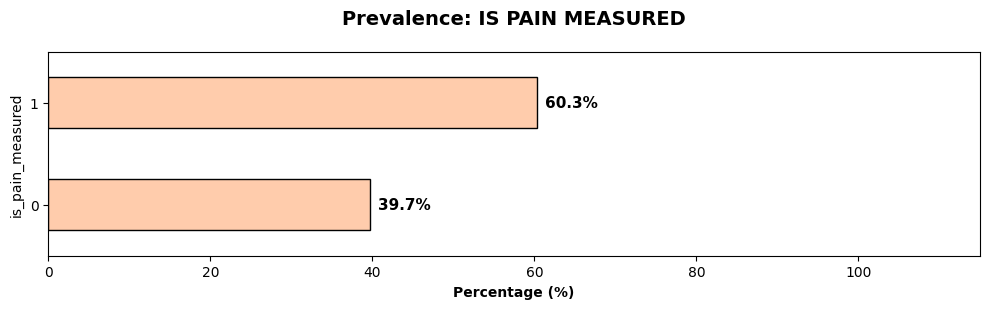

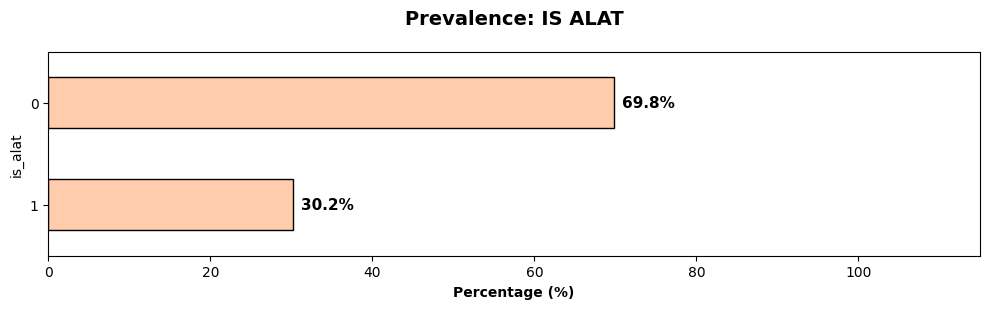

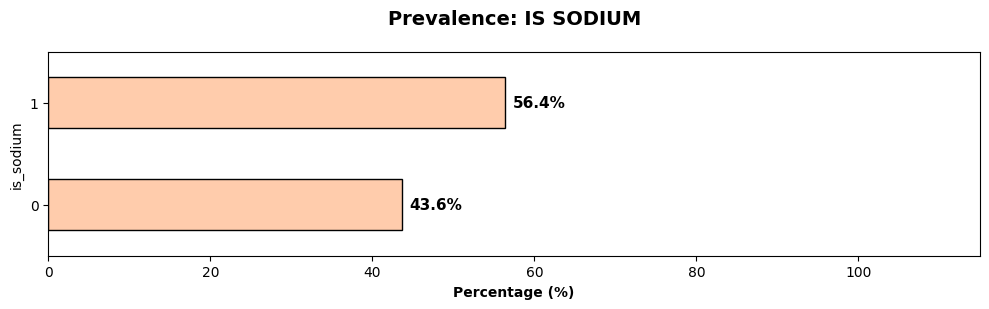

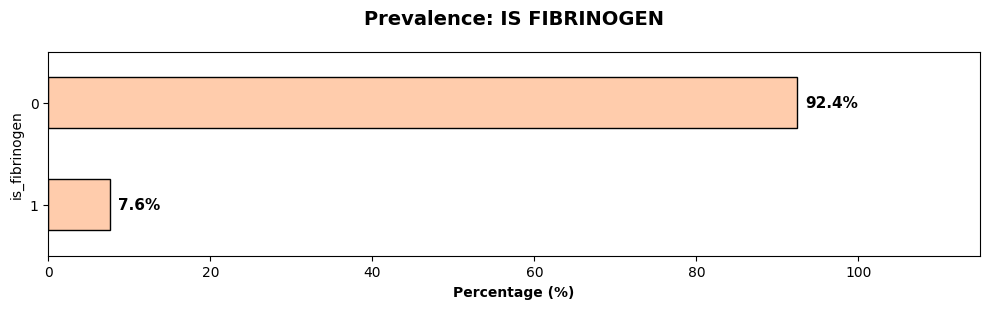

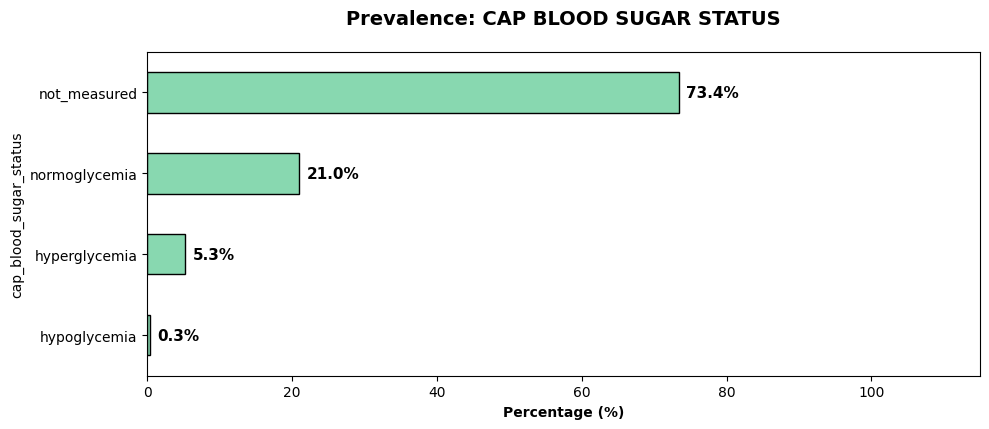

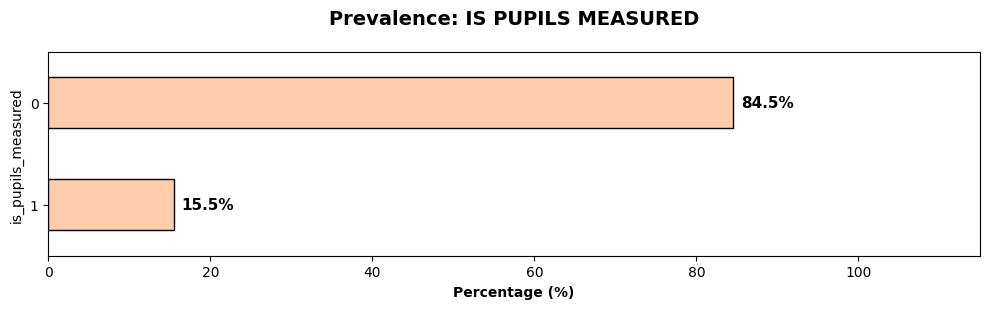

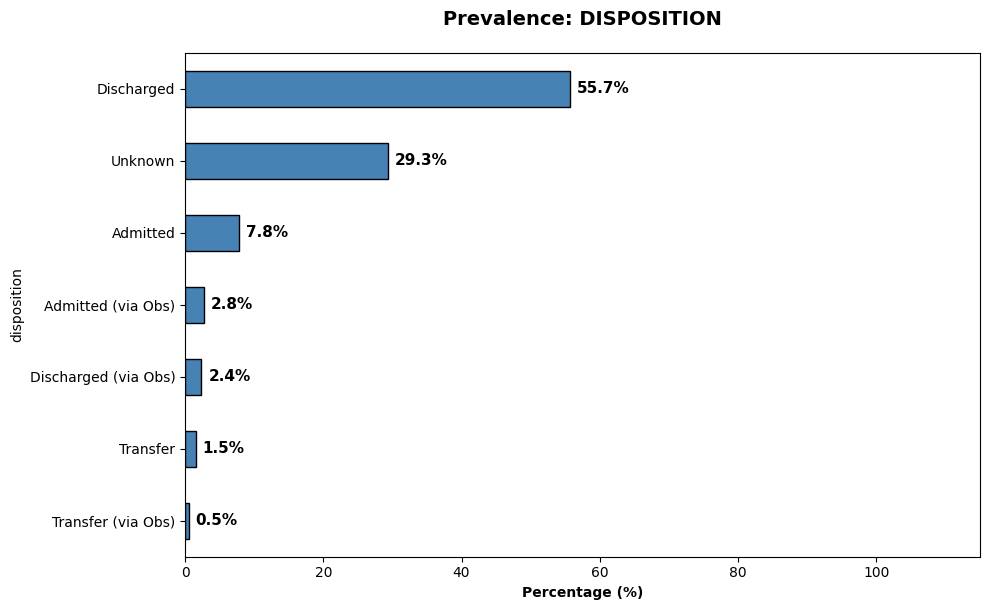

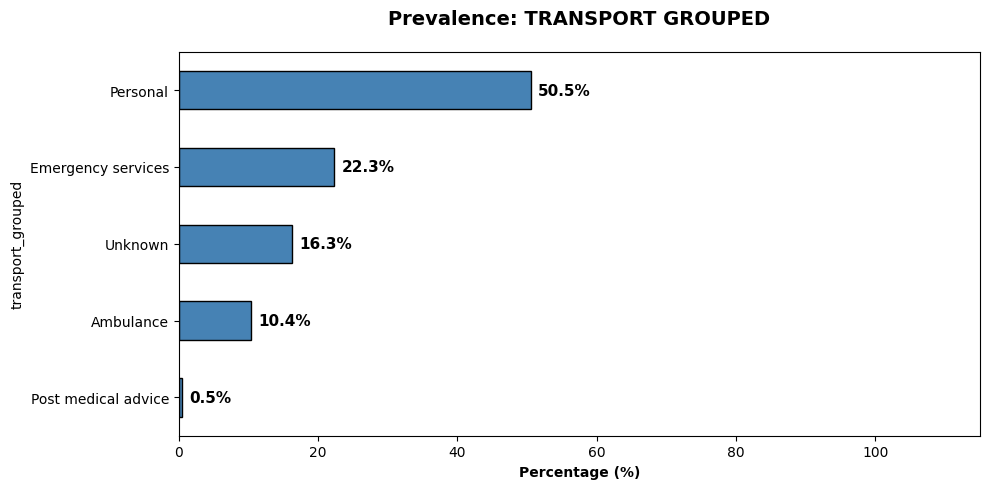

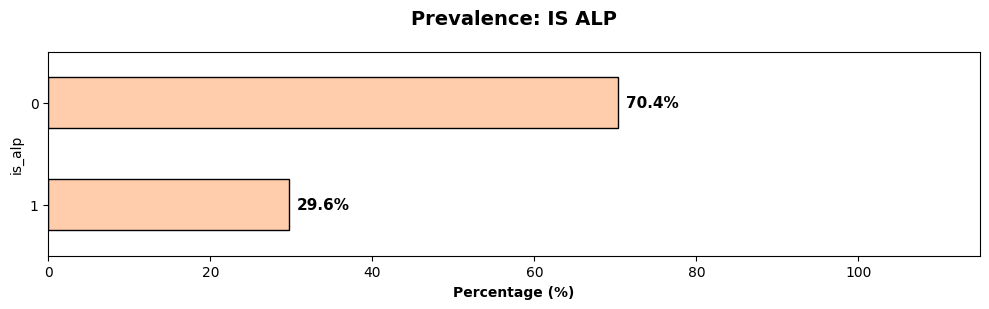

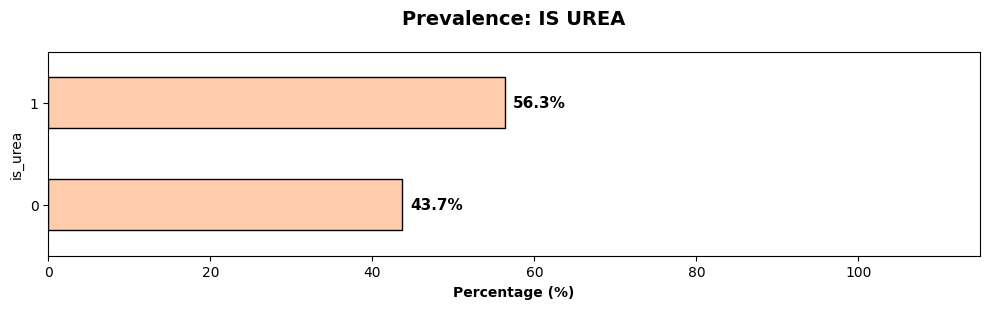

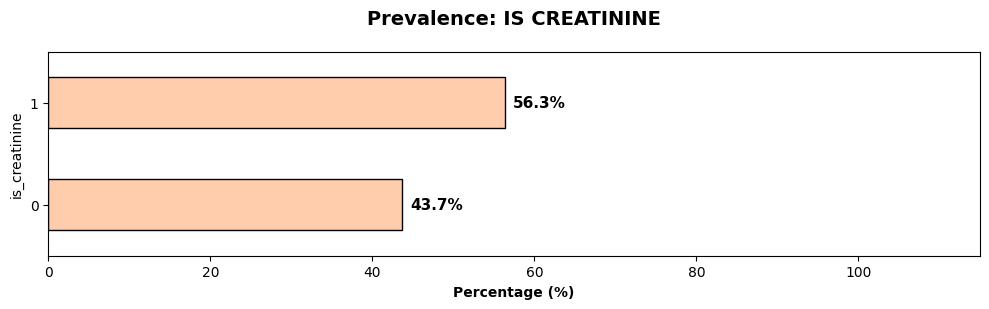

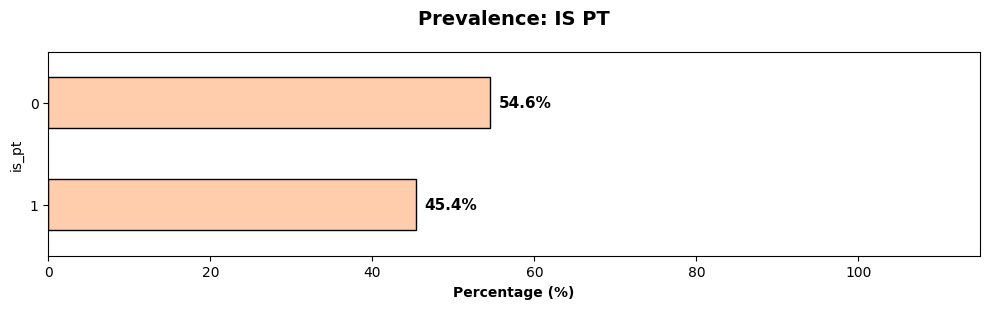

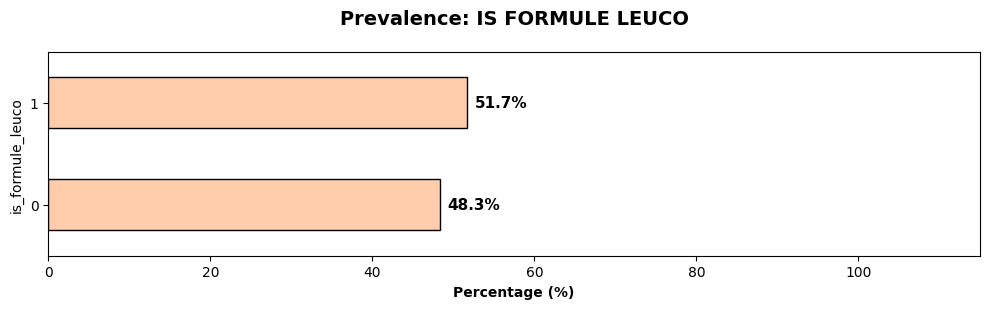

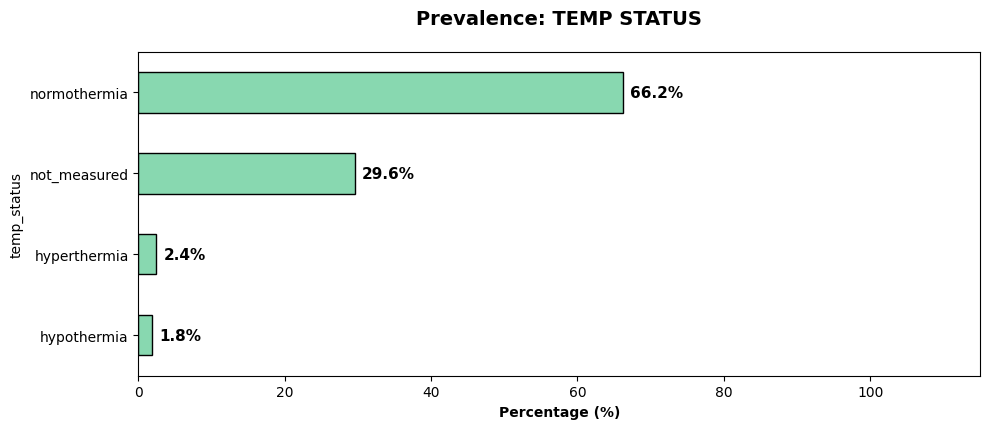

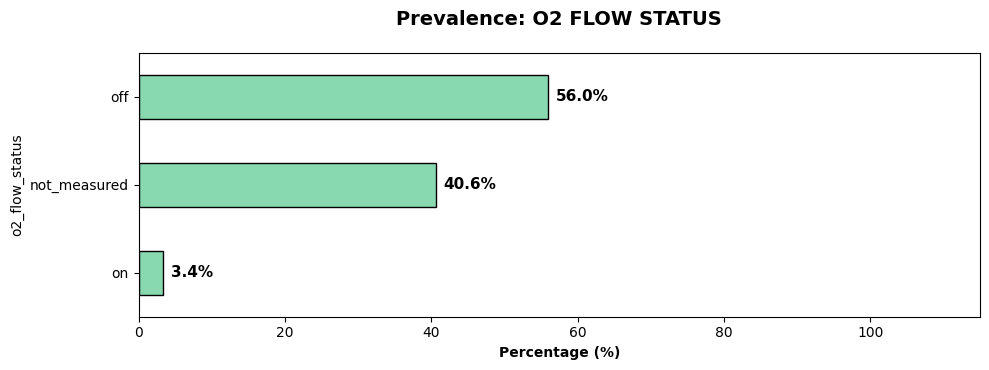

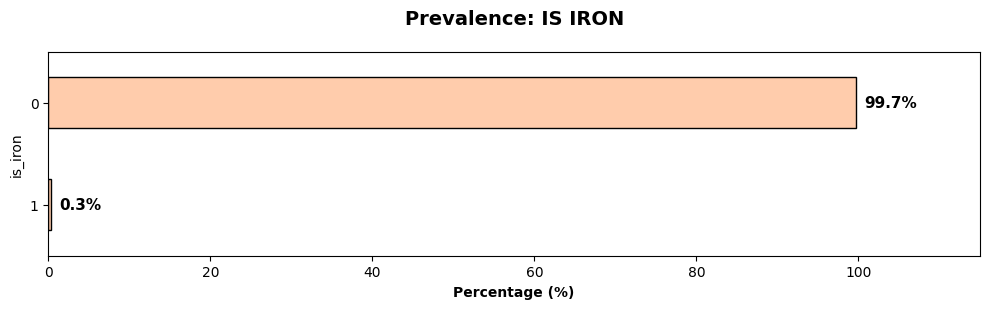

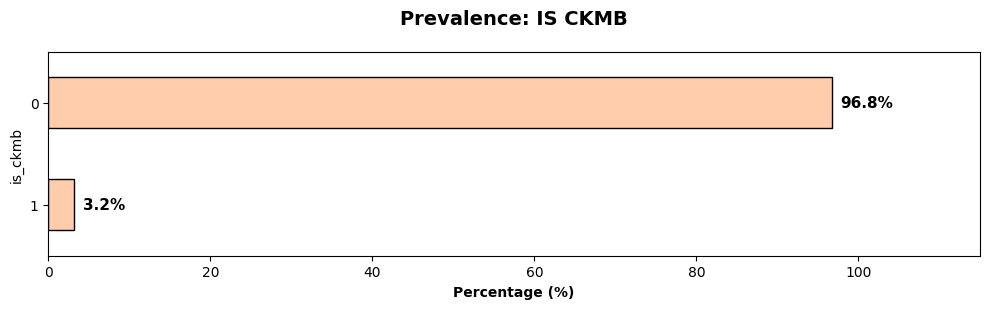

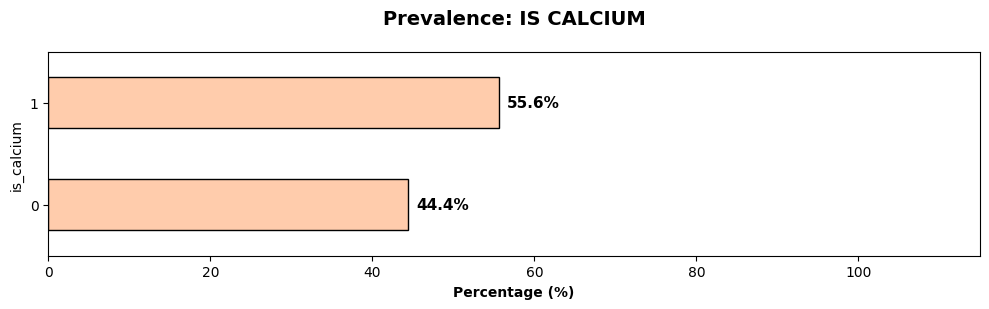

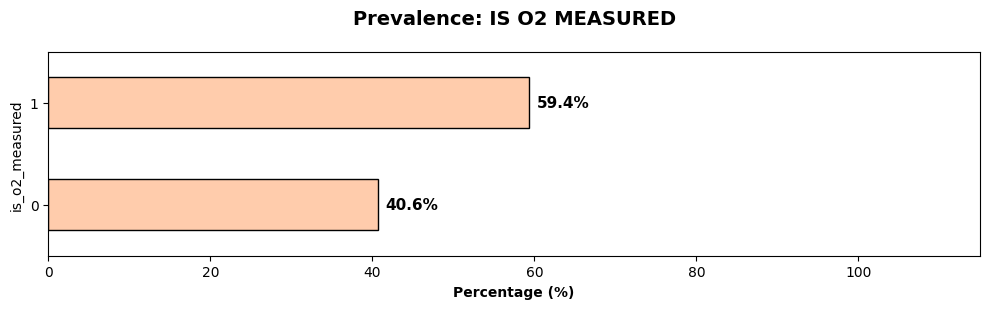

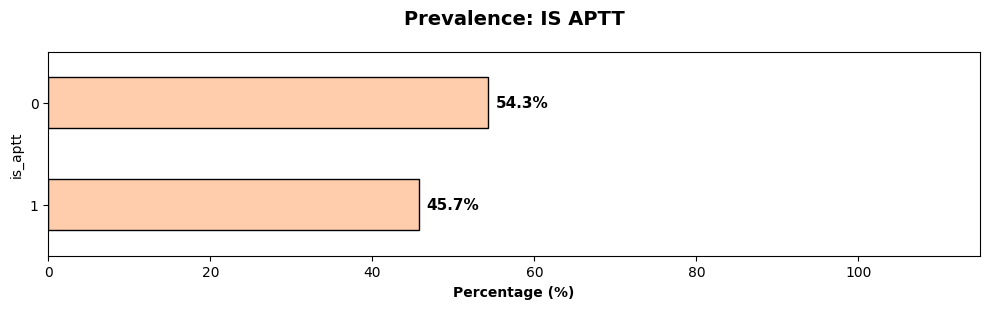

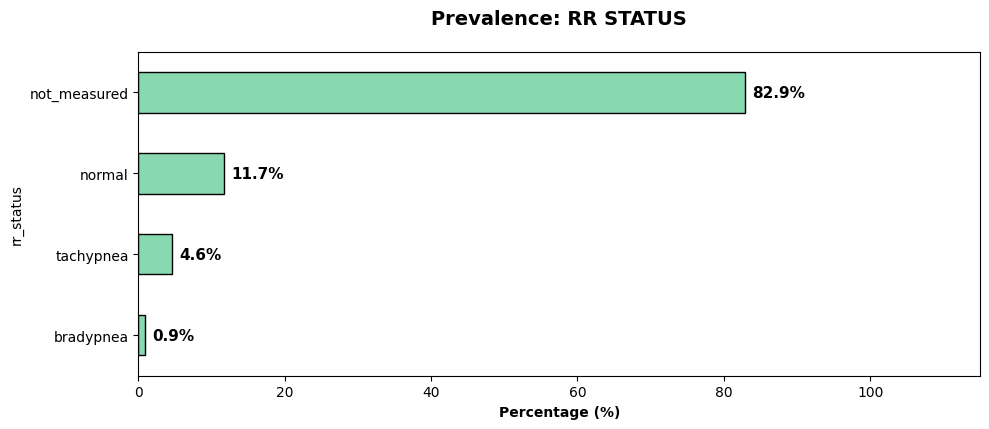

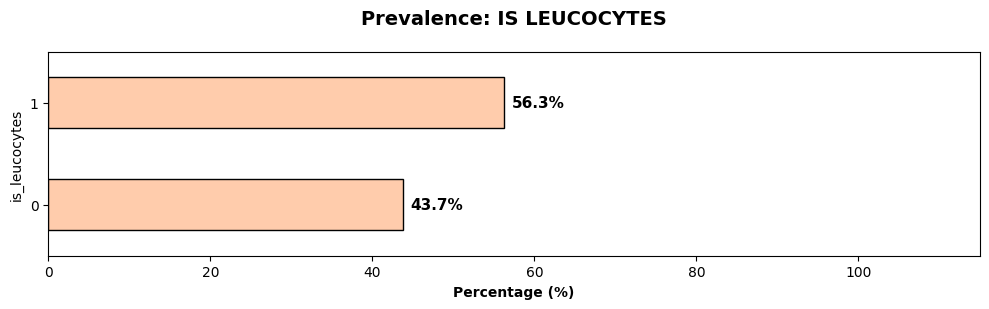

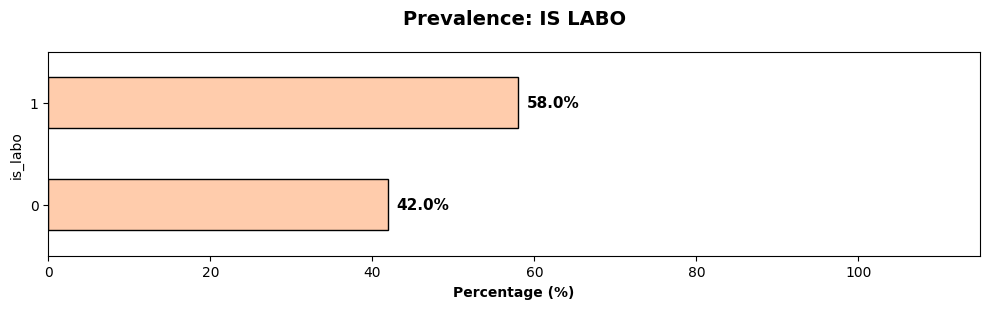

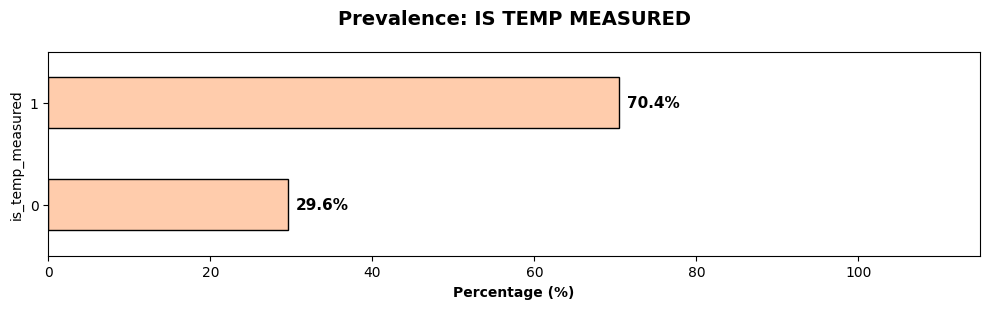

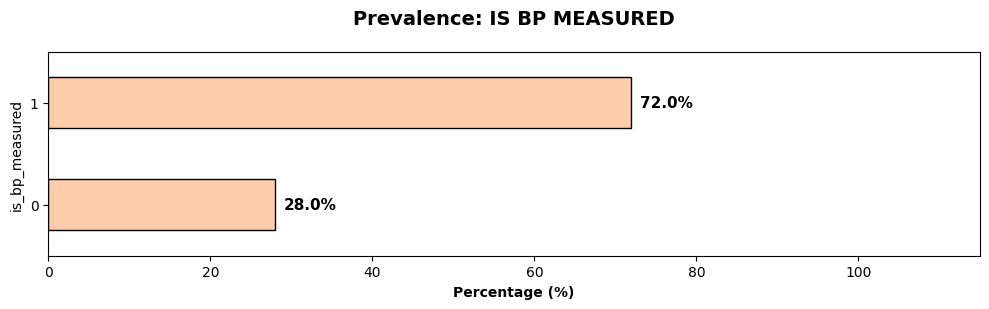

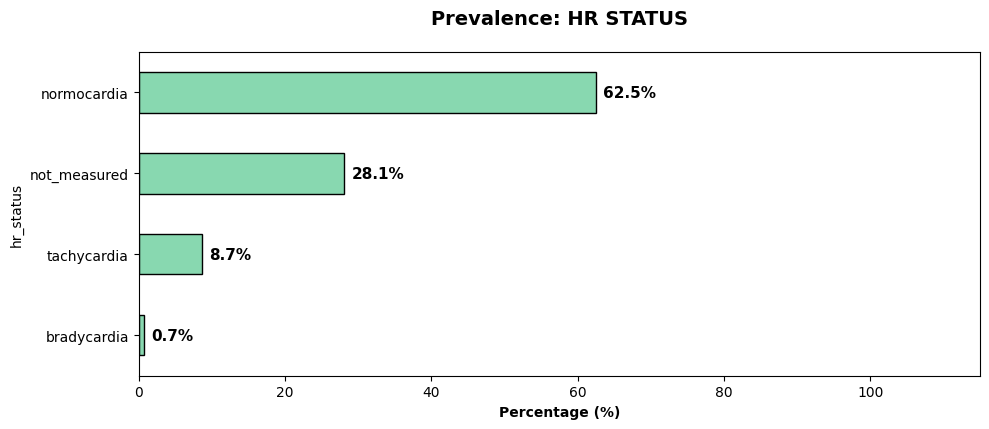

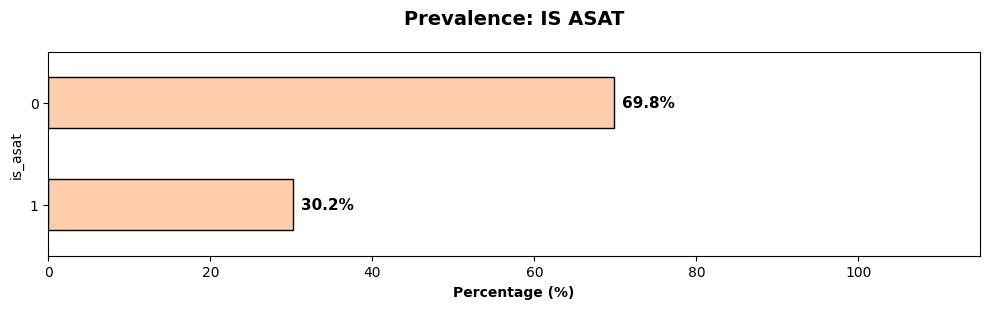

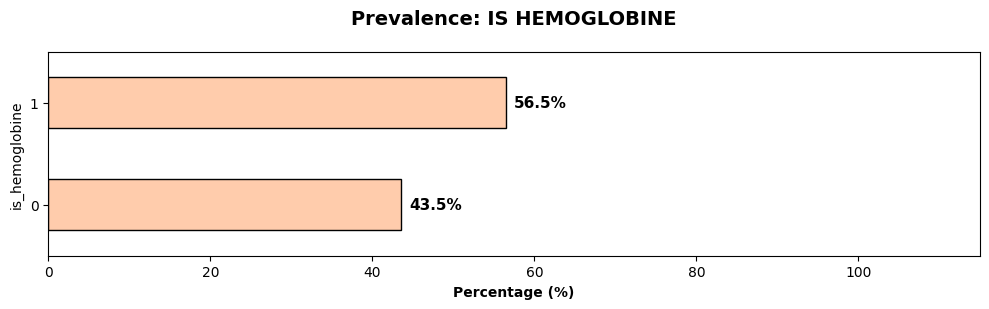

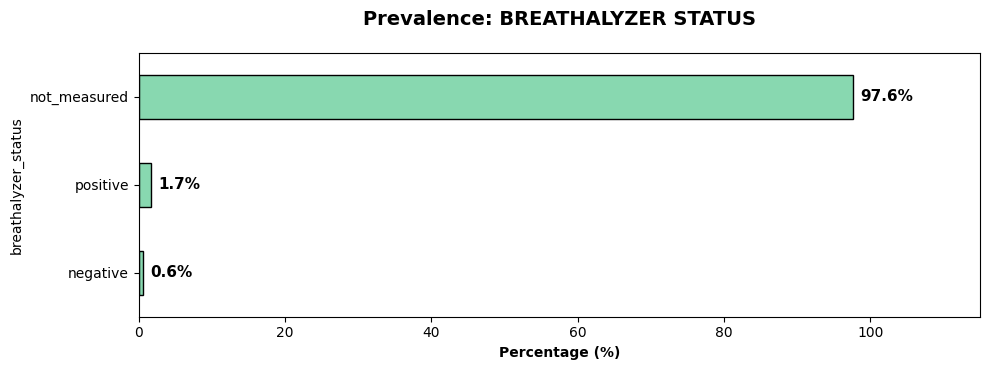

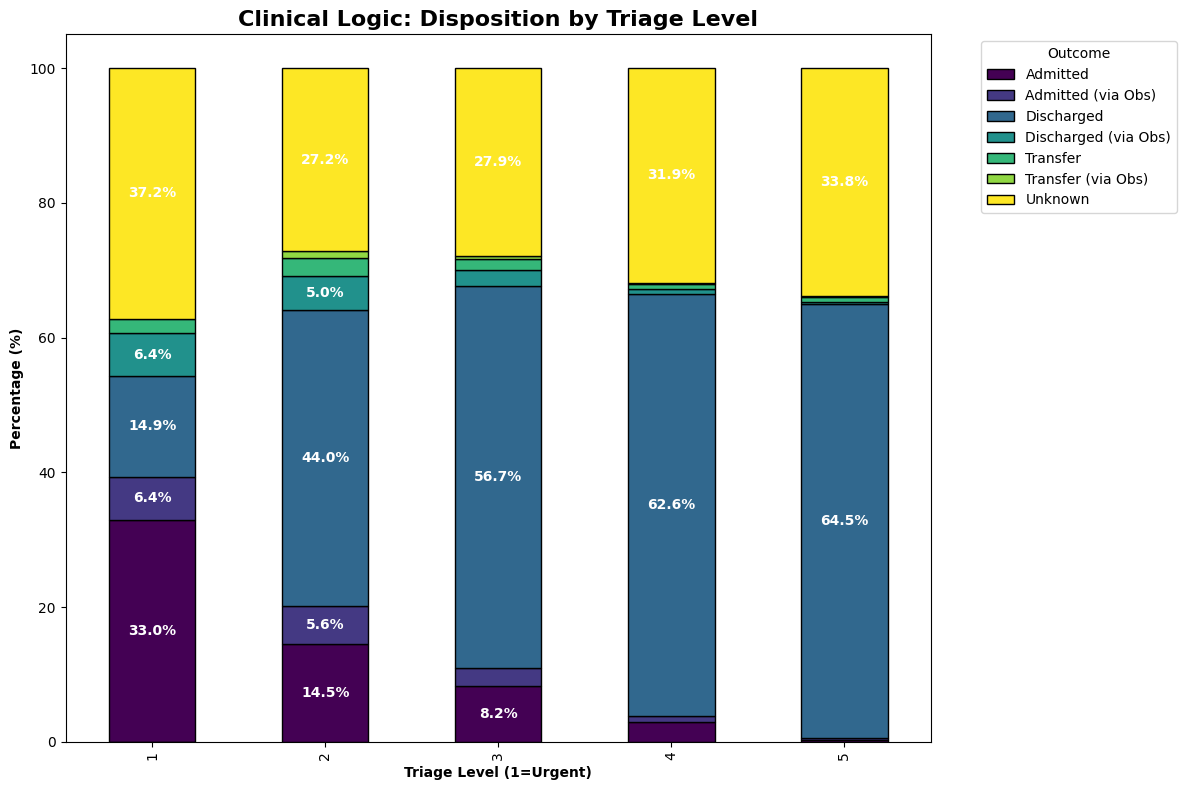

In [58]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from great_tables import GT, style, loc

# =========================================================
# CONFIGURATION & DIRECTORIES
# =========================================================
# Ensure the Results/Description directory exists
output_dir = "Results/Description"
os.makedirs(output_dir, exist_ok=True)

# Set high-visibility defaults
plt.style.use('default') # Forces white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# =========================================================
# 1. DATA COMPLETENESS HIERARCHY (GREAT TABLES)
# =========================================================
cols_target = [
    'is_sbp_measured', 'is_hr_measured', 'is_temp_measured',
    'is_sat_measured', 'is_rr_measured', 'is_gcs_measured',
    'is_hgt_mmol_L_measured', 'is_pupil_right_measured',
    'is_pain_measured', 'is_ethylotest_measured',
    'is_hemocue_measured', 'is_labo', 'has_imaging_any', 'had_ekg'
]

summary_list = []
for col in cols_target:
    if col in df.columns:
        # Fill NaN with 0 for the sake of completeness count
        temp_col = df[col].fillna(0).astype(int)
        counts = temp_col.value_counts()
        n0, n1 = counts.get(0, 0), counts.get(1, 0)
        total = n0 + n1
        pct_1 = n1 / total if total > 0 else 0

        summary_list.append({
            "variable": col.replace('is_', '').replace('_measured', '').replace('_', ' ').title(),
            "no": f"{n0} ({n0 / total:.1%})" if total > 0 else "0",
            "yes": f"{n1} ({pct_1:.1%})" if total > 0 else "0",
            "total": total,
            "raw_pct_1": pct_1
        })

df_gt_completness = pd.DataFrame(summary_list).sort_values(by="raw_pct_1", ascending=False)

# Render and Save Hierarchy Table
gt_table = (
    GT(df_gt_completness.drop(columns="raw_pct_1"))
    .tab_header(title="Data Completeness Hierarchy", subtitle="Measured Clinical Parameters")
)
# Note: gt_table.save("Results/Description/completeness_table.png") is available if 'itables' is installed
display(gt_table)

# =========================================================
# 2. QUANTITATIVE DISTRIBUTIONS (HIST & BOXPLOT)
# =========================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns
quanti_cols = [col for col in numeric_cols if df[col].nunique() > 2 and col.lower() != 'nda']

for col in quanti_cols:
    data = df[col].dropna()
    if data.empty: continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram - High contrast Blue
    sns.histplot(data, bins=30, color='DeepSkyBlue', edgecolor='black', ax=axes[0])
    axes[0].set_title(f"Distribution: {col.upper()}", fontweight='bold')

    # Boxplot - High contrast Orange
    sns.boxplot(x=data, color='Orange', ax=axes[1], fliersize=4)
    axes[1].set_title(f"Outlier Detection: {col.upper()}", fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/distribution_{col}.png", dpi=300)
    plt.show()

# =========================================================
# 3. CATEGORICAL & STATUS VARIABLES (Custom Colors)
# =========================================================
# Liste des colonnes à traiter
status_cols = [col for col in df.columns if col.endswith('_status')]
binary_cols = [col for col in df.columns if col.startswith('is_') or col == 'had_ekg']
pathway_cols = ['transport_grouped', 'chief_complaint', 'diag', 'disposition']

all_qualitative = list(set(pathway_cols + status_cols + binary_cols))

for col in all_qualitative:
    if col in df.columns:
        # Conversion en string pour éviter les bugs de catégories vides
        counts_pct = df[col].astype(str).value_counts(normalize=True).head(20) * 100

        # On ignore si c'est vide ou si il n'y a que des NaNs
        if counts_pct.empty or (len(counts_pct) == 1 and 'nan' in counts_pct.index):
            continue

        counts_pct = counts_pct.sort_values(ascending=True)

        fig, ax = plt.subplots(figsize=(10, len(counts_pct) * 0.6 + 2))

        # --- LOGIQUE DES COULEURS ---
        if col.endswith('_status'):
            color = '#88d8b0'  # Vert Pastel pour les résultats cliniques
        elif col.startswith('is_') or col == 'had_ekg':
            color = '#ffccac'  # Saumon/Pastel pour les flags de mesure
        else:
            color = 'SteelBlue' # Bleu pour l'administratif

        counts_pct.plot(kind='barh', color=color, edgecolor='black', ax=ax)

        # Ajout des étiquettes de pourcentage
        for i, v in enumerate(counts_pct):
            ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')

        title = f"Prevalence: {col.replace('_', ' ').upper()}"
        ax.set_title(title, fontsize=14, pad=20, fontweight='bold')
        ax.set_xlabel("Percentage (%)", fontweight='bold')
        ax.set_xlim(0, 115)

        plt.tight_layout()
        # Sauvegarde automatique
        plt.savefig(f"{output_dir}/categorical_{col}.png", dpi=300)
        plt.show()

# =========================================================
# 4. TRIAGE VS DISPOSITION (CLINICAL VALIDATION)
# =========================================================
table_disposition = pd.crosstab(df['triage'], df['disposition'], normalize='index') * 100

if not table_disposition.empty:
    # Ensure numeric for plotting
    table_disposition = table_disposition.astype(float).fillna(0)

    ax = table_disposition.plot(kind='bar', stacked=True, figsize=(12, 8),
                                colormap='viridis', edgecolor='black')

    plt.title('Clinical Logic: Disposition by Triage Level', fontsize=16, fontweight='bold')
    plt.ylabel('Percentage (%)', fontweight='bold')
    plt.xlabel('Triage Level (1=Urgent)', fontweight='bold')
    plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        h = p.get_height()
        if h > 5:
            ax.text(p.get_x() + p.get_width() / 2, p.get_y() + h / 2,
                    f'{h:.1f}%', ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/triage_vs_disposition.png", dpi=300)
    plt.show()

In [59]:


# =========================================================
# IMAGING EXAMINATIONS SUMMARY
# =========================================================


# columns to exclude
EXCLUDE_COLS = {
    "has_o2_support",
    "has_imaging_any",
    "has_blood_gas",
    "has_lumbar_puncture",
    "has_culture",
    "has_blood_test",
}

# 1. Filter for patients who underwent imaging
df_imaging = df[df["has_imaging_any"] == 1]
total_imaging_patients = len(df_imaging)

# 2. Identify has_* columns (excluding non-imaging flags)
has_cols = [
    col for col in df.columns
    if col.startswith("has_") and col not in EXCLUDE_COLS
]

imaging_summary = []
for col in has_cols:
    n1    = (df_imaging[col].astype(int) == 1).sum()
    pct_1 = n1 / total_imaging_patients if total_imaging_patients > 0 else 0

    imaging_summary.append({
        "variable":   col.replace("has_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": pct_1,
        "total":      total_imaging_patients,
    })

df_gt_imaging = (
    pd.DataFrame(imaging_summary)
    .sort_values(by="percentage", ascending=False)
)

# Render Imaging Table
gt_imaging = (
    GT(df_gt_imaging)
    .tab_header(
        title="Breakdown of Imaging Examinations",
        subtitle=html(f"Analysis of <b>{total_imaging_patients}</b> patients with confirmed imaging")
    )
    .cols_label(
        variable="Examination Type",
        count="Count (N)",
        percentage="Frequency (%)",
        total="Patient Base"
    )
    .fmt_percent(columns="percentage", decimals=1)
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.fill(color="#f0f7ff"), # Light blue for imaging
        locations=loc.body(columns="percentage")
    )
    .cols_align(align="center", columns=["count", "percentage", "total"])
    .tab_options(table_width="100%")
)

# =========================================================
# BIOLOGY / LAB TESTS SUMMARY
# =========================================================
# ── Lab summary ────────────────────────────────────────────────────────────────
LAB_COLS = [
    "has_blood_test",
    "has_lumbar_puncture",
    "has_blood_gas",
    "has_culture",
]

df_labo             = df[df["is_labo"] == 1]
total_labo_patients = len(df_labo)

lab_summary = []
for col in LAB_COLS:
    if col not in df.columns:
        continue
    n1    = (df_labo[col].astype(int) == 1).sum()
    pct_1 = n1 / total_labo_patients if total_labo_patients > 0 else 0
    lab_summary.append({
        "variable":   col.replace("has_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": round(pct_1 * 100, 1),
        "total":      total_labo_patients,
    })

df_gt_lab = (
    pd.DataFrame(lab_summary)
    .sort_values(by="percentage", ascending=False)
)

print(f"Lab summary — among {total_labo_patients} patients with lab work:")
display(df_gt_lab)


# blood test summary
# 1. Filter for patients with biology results
df_lab = df[df['is_labo'] == 1]
total_lab_patients = len(df_lab)

# 2. Identify biology columns (starts with 'is_', excludes 'measured' meta-data and the main flag)
lab_cols = [col for col in df.columns
             if col.startswith('is_')
             and 'measured' not in col
             and col != 'is_labo']

lab_summary = []
for col in lab_cols:
    n1 = (df_lab[col].astype(int) == 1).sum()
    pct_1 = n1 / total_lab_patients if total_lab_patients > 0 else 0

    lab_summary.append({
        "variable": col.replace('is_', '').replace('_', ' ').upper(),
        "count": n1,
        "percentage": pct_1,
        "total": total_lab_patients
    })

df_gt_lab = pd.DataFrame(lab_summary).sort_values(by="percentage", ascending=False)

# Render Biology Table
gt_labo = (
    GT(df_gt_lab)
    .tab_header(
        title="Breakdown of Biological Lab Tests",
        subtitle=html(f"Analysis of <b>{total_lab_patients}</b> patients with lab samples")
    )
    .cols_label(
        variable="Biological Analysis",
        count="Count (N)",
        percentage="Frequency (%)",
        total="Patient Base"
    )
    .fmt_percent(columns="percentage", decimals=1)
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.fill(color="#fffcf0"),  # Light yellow for biology
        locations=loc.body(columns="percentage")
    )
    .cols_align(align="center", columns=["count", "percentage", "total"])
    .tab_options(table_width="100%")
)

# To display in Jupyter/Notebook:
display(gt_imaging)
display(gt_labo)

Lab summary — among 17317 patients with lab work:


,variable,count,percentage,total
0,BLOOD TEST,17022,98.3,17317
3,CULTURE,4295,24.8,17317
2,BLOOD GAS,2208,12.8,17317
1,LUMBAR PUNCTURE,227,1.3,17317


GT(_tbl_data=               variable  count  percentage  total
1               CT SCAN   7478    0.488822  15298
2                  XRAY   6736    0.440319  15298
3                   MRI   2705    0.176820  15298
0            ULTRASOUND    498    0.032553  15298
4  RADIO INTERVENTIONAL     40    0.002615  15298
5      NUCLEAR MEDICINE      2    0.000131  15298, _body=<great_tables._gt_data.Body object at 0x722766170500>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Examination Type', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='Count (N)', column_align='center', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency (%)', column_align='center', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='Patient Base', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x722762e18980>, _spanners=Spanners([]), _heading=Heading(title='Breakdown of Imaging Examinations', subtitle=Html(text='Analysis of <b>15298</b> patients with confirmed imaging'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x72275fffa4b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x72276614faa0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='percentage', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='total', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=0, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=1, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=2, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=3, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=4, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=5, colnum=None, styles=[CellStyleFill(color='#f0f7ff')])], _locale=<great_tables._gt_data.Locale object at 0x72276621fe30>, _formats=[<great_tables._gt_data.FormatInfo object at 0x722754c41c40>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='100%'), tab

GT(_tbl_data=           variable  count  percentage  total
18      HEMOGLOBINE  16855    0.973321  17317
22        POTASSIUM  16825    0.971589  17317
24           SODIUM  16825    0.971589  17317
13       CREATININE  16813    0.970896  17317
28             UREA  16811    0.970780  17317
2        LEUCOCYTES  16789    0.969510  17317
21        PLATELETS  16785    0.969279  17317
12          CALCIUM  16600    0.958596  17317
10              CRP  15716    0.907547  17317
3     FORMULE LEUCO  15426    0.890801  17317
25             APTT  13642    0.787781  17317
26               PT  13553    0.782641  17317
5              ASAT   9007    0.520125  17317
4              ALAT   9006    0.520067  17317
20              ALP   8847    0.510885  17317
7        BILI TOTAL   8843    0.510654  17317
27        TROPONINE   5257    0.303575  17317
8                CK   3587    0.207137  17317
19           LIPASE   3401    0.196397  17317
14           DDIMER   3253    0.187850  17317
17       FIBRINOGEN   2259    0.130450  17317
1          LACTATES   2141    0.123636  17317
11  CALCIUM IONIZED   1817    0.104926  17317
6               BNP   1234    0.071259  17317
9              CKMB    962    0.055552  17317
0          AXA AIIA    583    0.033666  17317
23              PCT    355    0.020500  17317
16         FERRITIN    278    0.016054  17317
15             IRON     90    0.005197  17317, _body=<great_tables._gt_data.Body object at 0x722760795b80>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Biological Analysis', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='Count (N)', column_align='center', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency (%)', column_align='center', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='Patient Base', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x722763518440>, _spanners=Spanners([]), _heading=Heading(title='Breakdown of Biological Lab Tests', subtitle=Html(text='Analysis of <b>17317</b> patients with lab samples'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x72276745cb00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x72276745e000>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='percentage', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='total', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=0, colnum=None, styles=[CellStyleFill(color='#fffcf0')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=1, colnum=None, styles=[CellStyleFill(color='#fffcf0')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname

In [60]:
from IPython.display import display
from great_tables import GT, html, style, loc
import pandas as pd

# =========================================================
# IMAGING EXAMINATIONS SUMMARY — GENERAL POPULATION
# =========================================================

EXCLUDE_COLS = {
    "has_o2_support",
    "has_imaging_any",
    "has_blood_gas",
    "has_lumbar_puncture",
    "has_culture",
    "has_blood_test",
}

total_patients = len(df)   # ← population générale

has_cols = [
    col for col in df.columns
    if col.startswith("has_") and col not in EXCLUDE_COLS
]

imaging_summary = []
for col in has_cols:
    n1    = (df[col].astype(int) == 1).sum()
    pct_1 = n1 / total_patients if total_patients > 0 else 0
    imaging_summary.append({
        "variable":   col.replace("has_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": pct_1,
        "total":      total_patients,
    })

df_gt_imaging_pop = (
    pd.DataFrame(imaging_summary)
    .sort_values(by="percentage", ascending=False)
)

gt_imaging_pop = (
    GT(df_gt_imaging_pop)
    .tab_header(
        title="Breakdown of Imaging Examinations",
        subtitle=html(f"Analysis of <b>{total_patients}</b> patients — general population")
    )
    .cols_label(
        variable="Examination Type",
        count="Count (N)",
        percentage="Frequency (%)",
        total="Patient Base"
    )
    .fmt_percent(columns="percentage", decimals=1)
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.fill(color="#f0f7ff"),
        locations=loc.body(columns="percentage")
    )
    .cols_align(align="center", columns=["count", "percentage", "total"])
    .tab_options(table_width="100%")
)

# =========================================================
# BIOLOGY / LAB TESTS SUMMARY — GENERAL POPULATION
# =========================================================

LAB_COLS = [
    "has_blood_test",
    "has_lumbar_puncture",
    "has_blood_gas",
    "has_culture",
]

lab_summary_pop = []
for col in LAB_COLS:
    if col not in df.columns:
        continue
    n1    = (df[col].astype(int) == 1).sum()
    pct_1 = n1 / total_patients if total_patients > 0 else 0
    lab_summary_pop.append({
        "variable":   col.replace("has_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": pct_1,
        "total":      total_patients,
    })

# Detailed biology (is_* columns)
lab_cols = [
    col for col in df.columns
    if col.startswith("is_")
    and "measured" not in col
    and col != "is_labo"
]

for col in lab_cols:
    n1    = (df[col].astype(int) == 1).sum()
    pct_1 = n1 / total_patients if total_patients > 0 else 0
    lab_summary_pop.append({
        "variable":   col.replace("is_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": pct_1,
        "total":      total_patients,
    })

df_gt_lab_pop = (
    pd.DataFrame(lab_summary_pop)
    .sort_values(by="percentage", ascending=False)
)

gt_labo_pop = (
    GT(df_gt_lab_pop)
    .tab_header(
        title="Breakdown of Biological Lab Tests",
        subtitle=html(f"Analysis of <b>{total_patients}</b> patients — general population")
    )
    .cols_label(
        variable="Biological Analysis",
        count="Count (N)",
        percentage="Frequency (%)",
        total="Patient Base"
    )
    .fmt_percent(columns="percentage", decimals=1)
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.fill(color="#fffcf0"),
        locations=loc.body(columns="percentage")
    )
    .cols_align(align="center", columns=["count", "percentage", "total"])
    .tab_options(table_width="100%")
)

display(gt_imaging_pop)
display(gt_labo_pop)

GT(_tbl_data=               variable  count  percentage  total
1               CT SCAN   7478    0.250612  29839
2                  XRAY   6736    0.225745  29839
3                   MRI   2705    0.090653  29839
0            ULTRASOUND    498    0.016690  29839
4  RADIO INTERVENTIONAL     40    0.001341  29839
5      NUCLEAR MEDICINE      2    0.000067  29839, _body=<great_tables._gt_data.Body object at 0x72276072d880>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Examination Type', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='Count (N)', column_align='center', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency (%)', column_align='center', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='Patient Base', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x722765e06360>, _spanners=Spanners([]), _heading=Heading(title='Breakdown of Imaging Examinations', subtitle=Html(text='Analysis of <b>29839</b> patients — general population'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7227632709b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7227632739e0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='percentage', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='total', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=0, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=1, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=2, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=3, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=4, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=5, colnum=None, styles=[CellStyleFill(color='#f0f7ff')])], _locale=<great_tables._gt_data.Locale object at 0x722763271c10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7227632720c0>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='100%'), table

GT(_tbl_data=           variable  count  percentage  total
0        BLOOD TEST  17022    0.570461  29839
22      HEMOGLOBINE  16855    0.564865  29839
26        POTASSIUM  16825    0.563859  29839
28           SODIUM  16825    0.563859  29839
17       CREATININE  16813    0.563457  29839
32             UREA  16811    0.563390  29839
6        LEUCOCYTES  16789    0.562653  29839
25        PLATELETS  16785    0.562519  29839
16          CALCIUM  16600    0.556319  29839
14              CRP  15716    0.526693  29839
7     FORMULE LEUCO  15426    0.516974  29839
29             APTT  13642    0.457187  29839
30               PT  13553    0.454204  29839
9              ASAT   9007    0.301853  29839
8              ALAT   9006    0.301820  29839
24              ALP   8847    0.296491  29839
11       BILI TOTAL   8843    0.296357  29839
31        TROPONINE   5257    0.176179  29839
3           CULTURE   4295    0.143939  29839
12               CK   3587    0.120212  29839
23           LIPASE   3401    0.113978  29839
18           DDIMER   3253    0.109018  29839
21       FIBRINOGEN   2259    0.075706  29839
2         BLOOD GAS   2208    0.073997  29839
5          LACTATES   2141    0.071752  29839
15  CALCIUM IONIZED   1817    0.060893  29839
10              BNP   1234    0.041355  29839
13             CKMB    962    0.032240  29839
4          AXA AIIA    583    0.019538  29839
27              PCT    355    0.011897  29839
20         FERRITIN    278    0.009317  29839
1   LUMBAR PUNCTURE    227    0.007607  29839
19             IRON     90    0.003016  29839, _body=<great_tables._gt_data.Body object at 0x722763272ba0>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Biological Analysis', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='Count (N)', column_align='center', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency (%)', column_align='center', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='Patient Base', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7227607bc080>, _spanners=Spanners([]), _heading=Heading(title='Breakdown of Biological Lab Tests', subtitle=Html(text='Analysis of <b>29839</b> patients — general population'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x722760c53fb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x722760c51b20>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='percentage', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='total', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=0, colnum=None, styles=[CellStyleFill(color='#fffcf0')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mas

In [61]:
# clean list of unique modalities
print("📋 disposition levels :")
print(df['disposition'].unique().tolist())

# same with number of patient
print("\n📊 number per level :")
print(df['disposition'].value_counts())

📋 disposition levels :
['Discharged', 'Admitted (via Obs)', 'Unknown', 'Admitted', 'Discharged (via Obs)', 'Transfer', 'Transfer (via Obs)']

📊 number per level :
disposition
Discharged              16619
Unknown                  8753
Admitted                 2317
Admitted (via Obs)        825
Discharged (via Obs)      710
Transfer                  458
Transfer (via Obs)        157
Name: count, dtype: int64


In [62]:
# ========================================================
# MAPPING DISPOSITION -> 4 LVL (ALLUVIAL) - ENGLISH VERSION
# ========================================================

mapping_dispo = {
    # 1. Discharge (Home)
    'Discharged': 'Discharged',

    # 2. Unknown
    'Unknown': 'Unknown',

    # 3. Hospitalization / Transfer (High acuity)
    'Admitted': 'Hospitalization / Transfer',
    'Transfer': 'Hospitalization / Transfer',
    'Admitted (via Obs)': 'Hospitalization / Transfer',
    'Transfer (via Obs)': 'Hospitalization / Transfer',

    # 4. Observation Unit then Home (Low-Medium acuity)
    'Discharged (via Obs)': 'Discharged (via Obs)'
}

# ATTENTION : On retire le .lower() car tes clés commencent par des majuscules !
df['disposition_4lvl'] = df['disposition'].str.strip().map(mapping_dispo)

# Sécurité : Si une valeur n'est pas dans le dictionnaire, on met 'Unknown'
df['disposition_4lvl'] = df['disposition_4lvl'].fillna('Unknown')

# Vérification finale
print("📊 FINAL COUNTS (disposition_4lvl) :")
print(df['disposition_4lvl'].value_counts())

📊 FINAL COUNTS (disposition_4lvl) :
disposition_4lvl
Discharged                    16619
Unknown                        8753
Hospitalization / Transfer     3757
Discharged (via Obs)            710
Name: count, dtype: int64


In [63]:
import plotly.graph_objects as go
import pandas as pd

# ================================================================
# CONFIGURATION
# ================================================================
COL_TRIAGE    = 'triage'
COL_DISPOSITION = 'disposition_4lvl'

# ================================================================
# COLORS (Harmonized Keys)
# ================================================================
triage_colors = {
    'Triage 1': '#e74c3c',
    'Triage 2': '#e67e22',
    'Triage 3': '#f1c40f',
    'Triage 4': '#27ae60',
    'Triage 5': '#2980b9',
}

disposition_colors = {
    'Discharged': '#27ae60',
    'Unknown': '#5a5e6b',
    'Hospitalization / Transfer': '#e74c3c',
    'Discharged (via Obs)': '#f1c40f',
}

def get_node_color(label):
    for palette in [triage_colors, disposition_colors]:
        if label in palette:
            return palette[label]
    return '#a6acaf'

# ================================================================
# DATA PREPARATION
# ================================================================
df_alluvial = df.copy()

# Suppression des NaNs éventuels pour éviter "Triage nan"
df_alluvial = df_alluvial.dropna(subset=[COL_TRIAGE, COL_DISPOSITION])

# Création des labels (Assure-toi que le nom correspond aux clés du dico ci-dessus)
df_alluvial['_triage_label'] = 'Triage ' + df_alluvial[COL_TRIAGE].astype(int).astype(str)
df_alluvial['_disposition_label'] = df_alluvial[COL_DISPOSITION].astype(str)

# ================================================================
# NODES
# ================================================================
def get_present_vals(order_list, series):
    present = set(series.unique())
    return [v for v in order_list if v in present]

triage_vals = get_present_vals(
    ['Triage 5', 'Triage 4', 'Triage 3', 'Triage 2', 'Triage 1'],
    df_alluvial['_triage_label']
)

disposition_vals = get_present_vals(
    ['Unknown', 'Discharged', 'Discharged (via Obs)', 'Hospitalization / Transfer'],
    df_alluvial['_disposition_label']
)

all_labels  = triage_vals + disposition_vals
label_idx   = {label: i for i, label in enumerate(all_labels)}
node_colors = [get_node_color(l) for l in all_labels]

# ================================================================
# POSITIONS
# ================================================================
def assign_y(labels):
    n = len(labels)
    if n <= 1: return [0.5]
    return [round(0.10 + i * (0.80 / (n - 1)), 4) for i in range(n)]

pos = {}
for label, y in zip(triage_vals, assign_y(triage_vals)):
    pos[label] = (0.01, y)
for label, y in zip(disposition_vals, assign_y(disposition_vals)):
    pos[label] = (0.99, y)

node_x = [pos[l][0] for l in all_labels]
node_y = [pos[l][1] for l in all_labels]

# ================================================================
# LINKS (The coloring fix happens here)
# ================================================================
grp = (df_alluvial.groupby(['_triage_label', '_disposition_label'])
       .size()
       .reset_index(name='count'))

all_sources, all_targets, all_values, all_colors = [], [], [], []

for _, row in grp.iterrows():
    src, tgt = row['_triage_label'], row['_disposition_label']
    if src not in label_idx or tgt not in label_idx:
        continue

    all_sources.append(label_idx[src])
    all_targets.append(label_idx[tgt])
    all_values.append(int(row['count']))

    # Correction : on cherche 'Triage X' dans triage_colors
    hex_c = triage_colors.get(src, '#a6acaf')
    # Conversion Hex -> RGBA pour la transparence
    r, g, b = int(hex_c[1:3], 16), int(hex_c[3:5], 16), int(hex_c[5:7], 16)
    all_colors.append(f'rgba({r},{g},{b},0.4)')

# ================================================================
# FIGURE
# ================================================================
fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(
        pad=15, thickness=20,
        line=dict(color='#cccccc', width=0.5),
        label=all_labels, color=node_colors,
        x=node_x, y=node_y,
        hovertemplate='<b>%{label}</b><br>%{value} patients<extra></extra>',
    ),
    link=dict(
        source=all_sources, target=all_targets,
        value=all_values, color=all_colors,
        hovertemplate='%{source.label} → %{target.label}<br><b>%{value} patients</b><extra></extra>',
    ),
)])

# ================================================================
# FIGURE LAYOUT
# ================================================================
fig.update_layout(
    title=dict(
        text='Patient Flow: Triage → Disposition (Colored)',
        font=dict(size=18, color='black'), # S'assurer que le titre est noir
        x=0.01
    ),
    font=dict(size=12, family='Arial', color='black'), # Texte en noir

    # --- LES MODIFICATIONS POUR LE FOND BLANC ---
    paper_bgcolor='white',      # Fond tout autour du graphique
    plot_bgcolor='white',       # Fond de la zone de tracé
    template='plotly_white',    # Thème global blanc
    # --------------------------------------------

    height=750,
    margin=dict(t=100, b=50, l=100, r=150),
)

In [64]:
# 1. Liste propre pour ton dictionnaire de couleurs
print("📋 Liste des modalités (pour copier-coller dans ton dictionnaire) :")
print(df['transport_grouped'].unique().tolist())

# 2. Aperçu des effectifs pour vérifier si certaines catégories sont très rares
print("\n📊 Effectifs par mode de transport :")
print(df['transport_grouped'].value_counts())

📋 Liste des modalités (pour copier-coller dans ton dictionnaire) :
['Unknown', 'Post medical advice', 'Personal', 'Emergency services', 'Ambulance']

📊 Effectifs par mode de transport :
transport_grouped
Personal               15078
Emergency services      6661
Unknown                 4860
Ambulance               3097
Post medical advice      143
Name: count, dtype: int64


In [65]:
# ======================================================================
# ALLUVIAL WITH LAB TEST, IMAGING AND EKG
# ======================================================================




import plotly.graph_objects as go
import pandas as pd

# ================================================================
# 1. CONFIGURATION
# ================================================================
COL_TRANSPORT   = 'transport_grouped'
COL_TRI         = 'triage'
COL_EKG         = 'had_ekg'
COL_LABO        = 'is_labo'
COL_RADIO       = 'has_imaging_any'
COL_DISPOSITION = 'disposition_4lvl'

MEASURE_COLS = [
    'is_temp_measured', 'is_sat_measured', 'is_hr_measured',
    'is_bp_measured', 'is_rr_measured', 'is_pupils_measured',
    'is_o2_measured', 'is_hemocue_measured', 'is_breathalyzer_measured',
    'is_urine_dipstick_clean_measured', 'is_gcs_measured', 'is_pain_measured', 'is_cap_blood_sugar_mmol_L_measured'
]

# ================================================================
# 2. COLOR PALETTES (Using your exact labels)
# ================================================================
transport_colors = {
    'Unknown':              '#5a5e6b',
    'Personal':             '#3498db',
    'Post medical advice':  '#9b59b6',
    'Ambulance':            '#e67e22',
    'Emergency services':   '#2ecc71',
}

measure_colors = {
    '8+ measures':  '#27ae60',
    '4-7 measures': '#f1c40f',
    '1-3 measures': '#e67e22',
    '0 measures':   '#e74c3c',
}

triage_colors = {
    'Triage 1': '#e74c3c',
    'Triage 2': '#e67e22',
    'Triage 3': '#f1c40f',
    'Triage 4': '#27ae60',
    'Triage 5': '#2980b9',
}

exam_colors = {
    'Lab Test': '#9b59b6',
    'Imaging':  '#1abc9c',
    'EKG':      '#e74c3c',
}

disposition_colors = {
    'Discharged':                    '#27ae60',
    'Unknown  ':                     '#5a5e6b',
    'Hospitalization / Transfer':    '#e74c3c',
    'Discharged (via Obs)':          '#f1c40f',
}

def get_node_color(label):
    for palette in [transport_colors, measure_colors, triage_colors, exam_colors, disposition_colors]:
        if label in palette: return palette[label]
    return '#a6acaf'

# ================================================================
# 3. DATA PREPARATION
# ================================================================
df_alluvial = df.copy()

# Simple assignment, no mapping needed since labels match
df_alluvial['_transport_label'] = df_alluvial[COL_TRANSPORT].fillna('Unknown')
df_alluvial['_tri_label']       = 'Triage ' + df_alluvial[COL_TRI].astype(int).astype(str)

def score_to_cat(x):
    if x == 0:   return '0 measures'
    elif x <= 3: return '1-3 measures'
    elif x <= 7: return '4-7 measures'
    else:        return '8+ measures'


df_alluvial['_measures_score'] = df_alluvial[MEASURE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).astype(int)
df_alluvial['_measures_label'] = df_alluvial['_measures_score'].apply(score_to_cat)
df_alluvial['_ekg_label'] = df_alluvial[COL_EKG].apply(lambda v: 'EKG' if int(v) == 1 else None)
df_alluvial['_labo_label']    = df_alluvial[COL_LABO].apply(lambda v: 'Lab Test' if int(v) == 1 else None)
df_alluvial['_radio_label']   = df_alluvial[COL_RADIO].apply(lambda v: 'Imaging' if int(v) == 1 else None)
# add space at the end of unknowed because the plot is mixing with the transport unknown
df_alluvial['_disposition_label'] = df_alluvial['disposition_4lvl'].replace('Unknown', 'Unknown  ') # 2 spaces

# ================================================================
# 4. NODES DEFINITION & ORDER
# ================================================================
def get_present_vals(order_list, series):
    present = set(series.dropna().unique())
    return [v for v in order_list if v in present]

transport_vals = get_present_vals(['Emergency services', 'Ambulance', 'Post medical advice', 'Personal', 'Unknown'], df_alluvial['_transport_label'])
measure_vals   = get_present_vals(['8+ measures', '4-7 measures', '1-3 measures', '0 measures'], df_alluvial['_measures_label'])
tri_vals       = get_present_vals(['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5'], df_alluvial['_tri_label'])
ekg_vals       = get_present_vals(['EKG'], df_alluvial['_ekg_label'])
labo_vals      = get_present_vals(['Lab Test'], df_alluvial['_labo_label'])
radio_vals     = get_present_vals(['Imaging'], df_alluvial['_radio_label'])
disposition_vals   = get_present_vals(['Hospitalization / Transfer','Discharged (via Obs)', 'Discharged','Unknown  '], df_alluvial['_disposition_label']) # 2 spaces here too

all_labels = transport_vals + measure_vals + tri_vals + ekg_vals + labo_vals + radio_vals + disposition_vals
label_idx  = {label: i for i, label in enumerate(all_labels)}
node_colors = [get_node_color(l) for l in all_labels]

# ================================================================
# 5. FIXED X-POSITIONS
# ================================================================
col_x = {
    'transport': 0.01,
    'measures': 0.15,
    'tri': 0.30,
    'ekg': 0.45,   # Nouvelle colonne
    'labo': 0.60,
    'radio': 0.80,
    'disposition': 0.99
}

def assign_y(labels):
    n = len(labels)
    if n <= 1: return [0.5]
    return [round(0.10 + i * (0.80 / (n - 1)), 4) for i in range(n)]

pos = {}
for key, vals in [('transport', transport_vals), ('measures', measure_vals), ('tri', tri_vals),
                  ('ekg', ekg_vals), ('labo', labo_vals), ('radio', radio_vals),
                  ('disposition', disposition_vals)]:
    for label, y in zip(vals, assign_y(vals)):
        pos[label] = (col_x[key], y)

node_x = [pos[l][0] for l in all_labels]
node_y = [pos[l][1] for l in all_labels]


# ================================================================
# 6. LINKS (Colored by Triage)
# ================================================================

def make_links(df_sub, col_from, col_to):
    #creating list for groupby, without duplicates
    group_cols = list(dict.fromkeys([col_from, col_to, '_tri_label']))

    # Groupement
    grp = df_sub.groupby(group_cols).size().reset_index(name='count')

    sources, targets, values, colors = [], [], [], []
    for _, row in grp.iterrows():
        src, tgt = str(row[col_from]), str(row[col_to])

        if src in label_idx and tgt in label_idx:
            sources.append(label_idx[src])
            targets.append(label_idx[tgt])
            values.append(int(row['count']))

            # grabing color from traige lvl
            tri_val = row['_tri_label']
            hex_c = triage_colors.get(tri_val, '#a6acaf')
            # Conversion Hex en RGBA pour la transparence
            r, g, b = int(hex_c[1:3], 16), int(hex_c[3:5], 16), int(hex_c[5:7], 16)
            colors.append(f'rgba({r},{g},{b},0.35)')

    return sources, targets, values, colors

# --- LIST INITIALIZATION ---
s_all, t_all, v_all, c_all = [], [], [], []

# 1. MAIN FLOW (Transport -> Measures -> Triage)
s,t_l,v,c = make_links(df_alluvial, '_transport_label', '_measures_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial, '_measures_label', '_tri_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 2. FLOW FROM TRIAGE TO EKG (OR SKIP EKG)
# Triage -> EKG (Only for those who had one)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna()], '_tri_label', '_ekg_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# Triage -> Labo (If NO EKG but Labo)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].notna()], '_tri_label', '_labo_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# Triage -> Radio (If NO EKG, NO Labo but Radio)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].notna()], '_tri_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# Triage -> Disposition (If NO exams at all)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna()], '_tri_label', '_disposition_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 3. FLOW FROM EKG
# EKG -> Labo
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].notna()], '_ekg_label', '_labo_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# EKG -> Radio (If NO Labo)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].notna()], '_ekg_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# EKG -> Disposition (If NO Labo, NO Radio)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna()], '_ekg_label', '_disposition_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 4. FLOW FROM LABO
# Labo -> Radio
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].notna()], '_labo_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# Labo -> Disposition (If NO Radio)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].isna()], '_labo_label', '_disposition_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 5. FLOW FROM RADIO
# Radio -> Disposition
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_radio_label'].notna()], '_radio_label', '_disposition_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c


# ================================================================
# 7. FIGURE LAYOUT (White Theme)
# ================================================================
fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(pad=20, thickness=18, label=all_labels, color=node_colors, x=node_x, y=node_y,
              line=dict(color='#cccccc', width=0.5)),
    link=dict(source=s_all, target=t_all, value=v_all, color=c_all)
)])

fig.update_layout(
    title=dict(
        text='Patient Journey: Admission Steps and Outcome',
        font=dict(size=18, color='black'),
        x=0.01,
        y=0.98 # Remonte un peu le titre
    ),
    font=dict(size=11, family='Arial', color='black'),
    paper_bgcolor='white',
    plot_bgcolor='white',
    template='plotly_white',

    # picture size
    height=950,
    margin=dict(
        t=80,
        b=100,
        l=100,
        r=150
    ),
)

fig.show()

In [66]:
from tableone import TableOne

# 1. Préparation des colonnes à analyser
# On utilise tes colonnes harmonisées
columns = [
    'transport_grouped',
    '_measures_label',
    'had_ekg',
    'is_labo',
    'has_imaging_any',
    'disposition_4lvl',
    'triage'
]

# 2. Lister les variables catégorielles
categorical = [
    'transport_grouped',
    '_measures_label',
    'had_ekg',
    'is_labo',
    'has_imaging_any',
    'disposition_4lvl'
]

# 3. Création du tableau
# groupby='triage' : crée une colonne par niveau de tri (1 à 5)
# pval=True : calcule la p-value (Chi-2 pour les catégories)
mytable = TableOne(
    df_alluvial,
    columns=columns,
    categorical=categorical,
    groupby='triage',
    rename={'_measures_label': 'Vital Signs Count'},
    pval=True,
    display_all=True # Affiche tous les niveaux de transport/devenir
)

# 4. Affichage et Export
print(mytable.tabulate(tablefmt="pretty"))
mytable.to_excel('tableau_analyse_triage.xlsx')

+--------------------------+----------------------------+---------+--------------+-----------+-------------+-------------+-------------+-------------+---------+
|                          |                            | Missing |   Overall    |     1     |      2      |      3      |      4      |      5      | P-Value |
+--------------------------+----------------------------+---------+--------------+-----------+-------------+-------------+-------------+-------------+---------+
|            n             |                            |         |    29839     |    94     |    7459     |    11279    |    9051     |    1956     |         |
| transport_grouped, n (%) |         Ambulance          |         | 3097 (10.4)  |  4 (4.3)  | 1026 (13.8) | 1494 (13.2) |  548 (6.1)  |  25 (1.3)   | <0.001  |
|                          |     Emergency services     |         | 6661 (22.3)  | 67 (71.3) | 3165 (42.4) | 2526 (22.4) |  841 (9.3)  |  62 (3.2)   |         |
|                          |      

## Description of imaging exam by triage level ###



🔍 CHECKING DATA SEQUENCING (Left-to-Right filling)
--------------------------------------------------
✅ MRI sequencing is perfect.
--------------------------------------------------
📊 IMAGING DISTRIBUTION BY TRIAGE LEVEL (PERCENTAGES)


,ULTRASOUND,CT_SCAN,XRAY,MRI,RADIO_INTERVENTIONAL,NUCLEAR_MEDICINE
triage_label,,,,,,
Triage 1,0.00,22.34,11.70,12.77,0.00,0.00
Triage 2,2.48,34.36,19.00,15.51,0.32,0.00
Triage 3,1.81,31.01,21.53,10.40,0.12,0.00
Triage 4,1.10,14.41,27.36,3.83,0.02,0.02
Triage 5,0.46,4.70,20.65,0.82,0.05,0.00


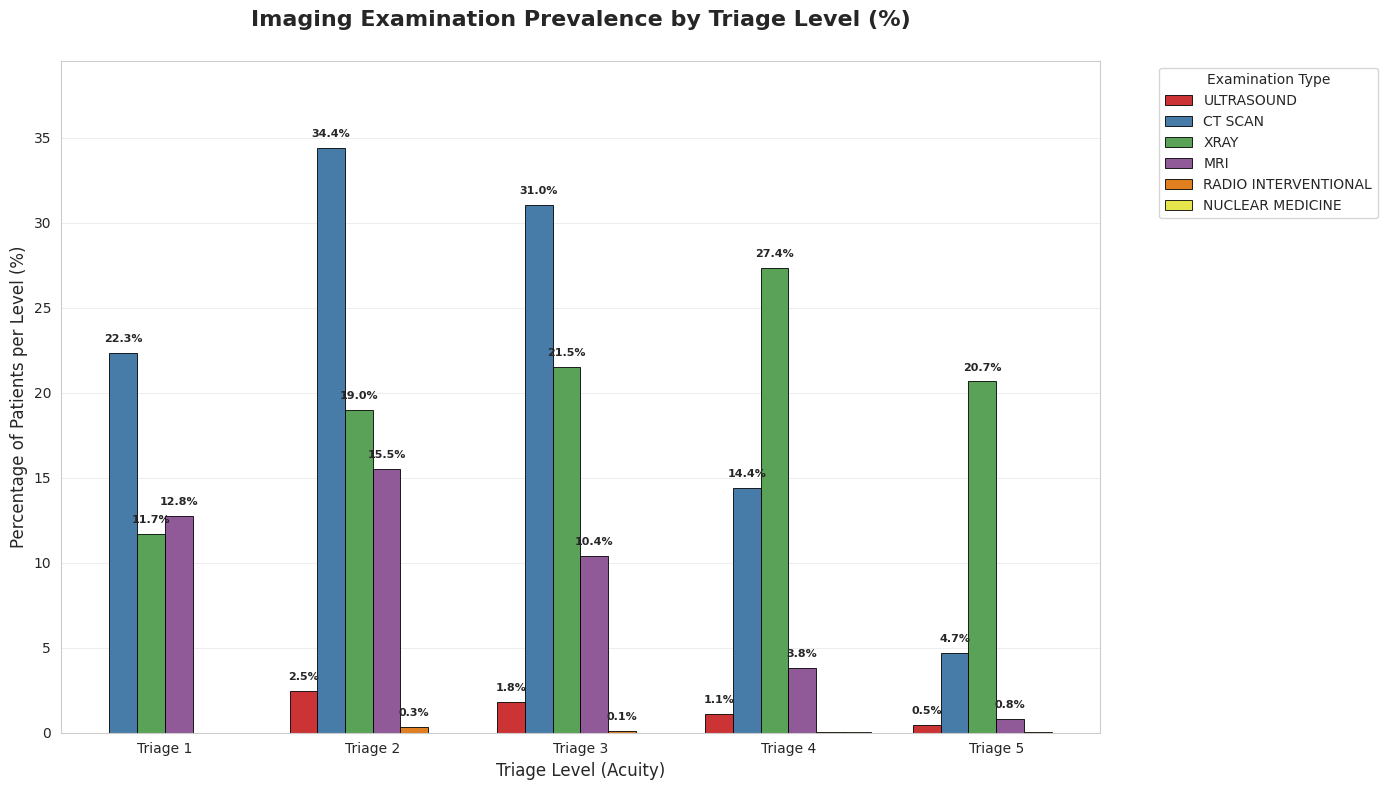

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display



#=======================
# DATA CHECK (check that every patient who has an exam 2 ou 3 or more have an exam 1)
#=====================
# Define the prefixes to check
categories = ['scanner_', 'radio_conventional_', 'mri_', 'echography_', 'nuclear_medicine_']

print("🔍 CHECKING DATA SEQUENCING (Left-to-Right filling)")
print("-" * 50)

for prefix in categories:
    # Get columns for this category in order (1, 2, 3...)
    cols = sorted([c for c in df.columns if c.startswith(prefix)])

    if len(cols) > 1:
        # Check if any patient has 'NONE' in col_N but something in col_N+1
        violations = df[
            (df[cols[0]] == "NONE") &
            (df[cols[1:]].ne("NONE").any(axis=1))
        ]

        if len(violations) > 0:
            print(f"⚠️  ALERT: {len(violations)} patients have gaps in {prefix.upper()}!")
            print(f"   (Exam 2 or 3 exists, but Exam 1 is 'NONE')")
        else:
            print(f"✅ {prefix.upper().replace('_', '')} sequencing is perfect.")

print("-" * 50)

# ================================================================
# 1. DATA PREPARATION
# ================================================================
df_plot = df.copy()

# Standardize Triage labels
df_plot['triage_label'] = 'Triage ' + df_plot['triage'].astype(int).astype(str)

# Identify imaging columns (excluding global flags and oxygen)
imaging_flags = [c for c in df_plot.columns if c.startswith('has_')
                 and c not in ['has_imaging_any', 'has_o2_support']]

# ================================================================
# 2. CALCULATIONS (COUNTS & PERCENTAGES)
# ================================================================
# 1. Raw Counts (N) - Forced to int to allow summation
repartition_counts = df_plot.groupby('triage_label')[imaging_flags].agg(lambda x: x.astype(int).sum())

# 2. Percentages (%)
totals_per_triage = df_plot['triage_label'].value_counts()
repartition_pct = repartition_counts.div(totals_per_triage, axis=0) * 100

# ================================================================
# 3. SUMMARY TABLE (DISPLAY)
# ================================================================
print("📊 IMAGING DISTRIBUTION BY TRIAGE LEVEL (PERCENTAGES)")

excluded_cols = [
    "has_blood_test",
    "has_blood_gas",
    "has_culture",
    "has_lumbar_puncture"
]

summary_table = repartition_pct.drop(
    columns=[col for col in excluded_cols if col in repartition_pct.columns]
).round(2).copy()

summary_table.columns = [c.replace('has_', '').upper() for c in summary_table.columns]

display(summary_table)

# ================================================================
# 4. VISUALIZATION (HIGH-CONTRAST BAR CHART)
# ================================================================


repartition_pct_filtered = repartition_pct.drop(
    columns=[col for col in excluded_cols if col in repartition_pct.columns]
)

# Melt for Seaborn
df_long = repartition_pct_filtered.reset_index().melt(
    id_vars='triage_label',
    var_name='Exam Type',
    value_name='% Patients'
)

df_long['Exam Type'] = (
    df_long['Exam Type']
    .str.replace('has_', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.upper()
)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_long,
    x='triage_label',
    y='% Patients',
    hue='Exam Type',
    palette='Set1',
    edgecolor='black',
    linewidth=0.6
)

plt.title('Imaging Examination Prevalence by Triage Level (%)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Percentage of Patients per Level (%)', fontsize=12)
plt.xlabel('Triage Level (Acuity)', fontsize=12)
plt.legend(title='Examination Type', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0.1:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold'
        )

plt.ylim(0, df_long['% Patients'].max() * 1.15)
plt.tight_layout()
plt.show()

📦 RAW VOLUME: TOP 15 SPECIFIC EXAMS


,Exam Label,Total Count
0,xray emergency survey,4731
1,ct head / brain,2129
2,ct abdomen pelvis,1632
3,mri angiography brain,1352
4,xray chest,520
5,mri brain,517
6,ct brain facial bones,508
7,ct angiography brain neck,454
8,mri stroke protocol,453
9,ct angiography chest pulmonary embolism,411


/tmp/ipykernel_599530/4221173012.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




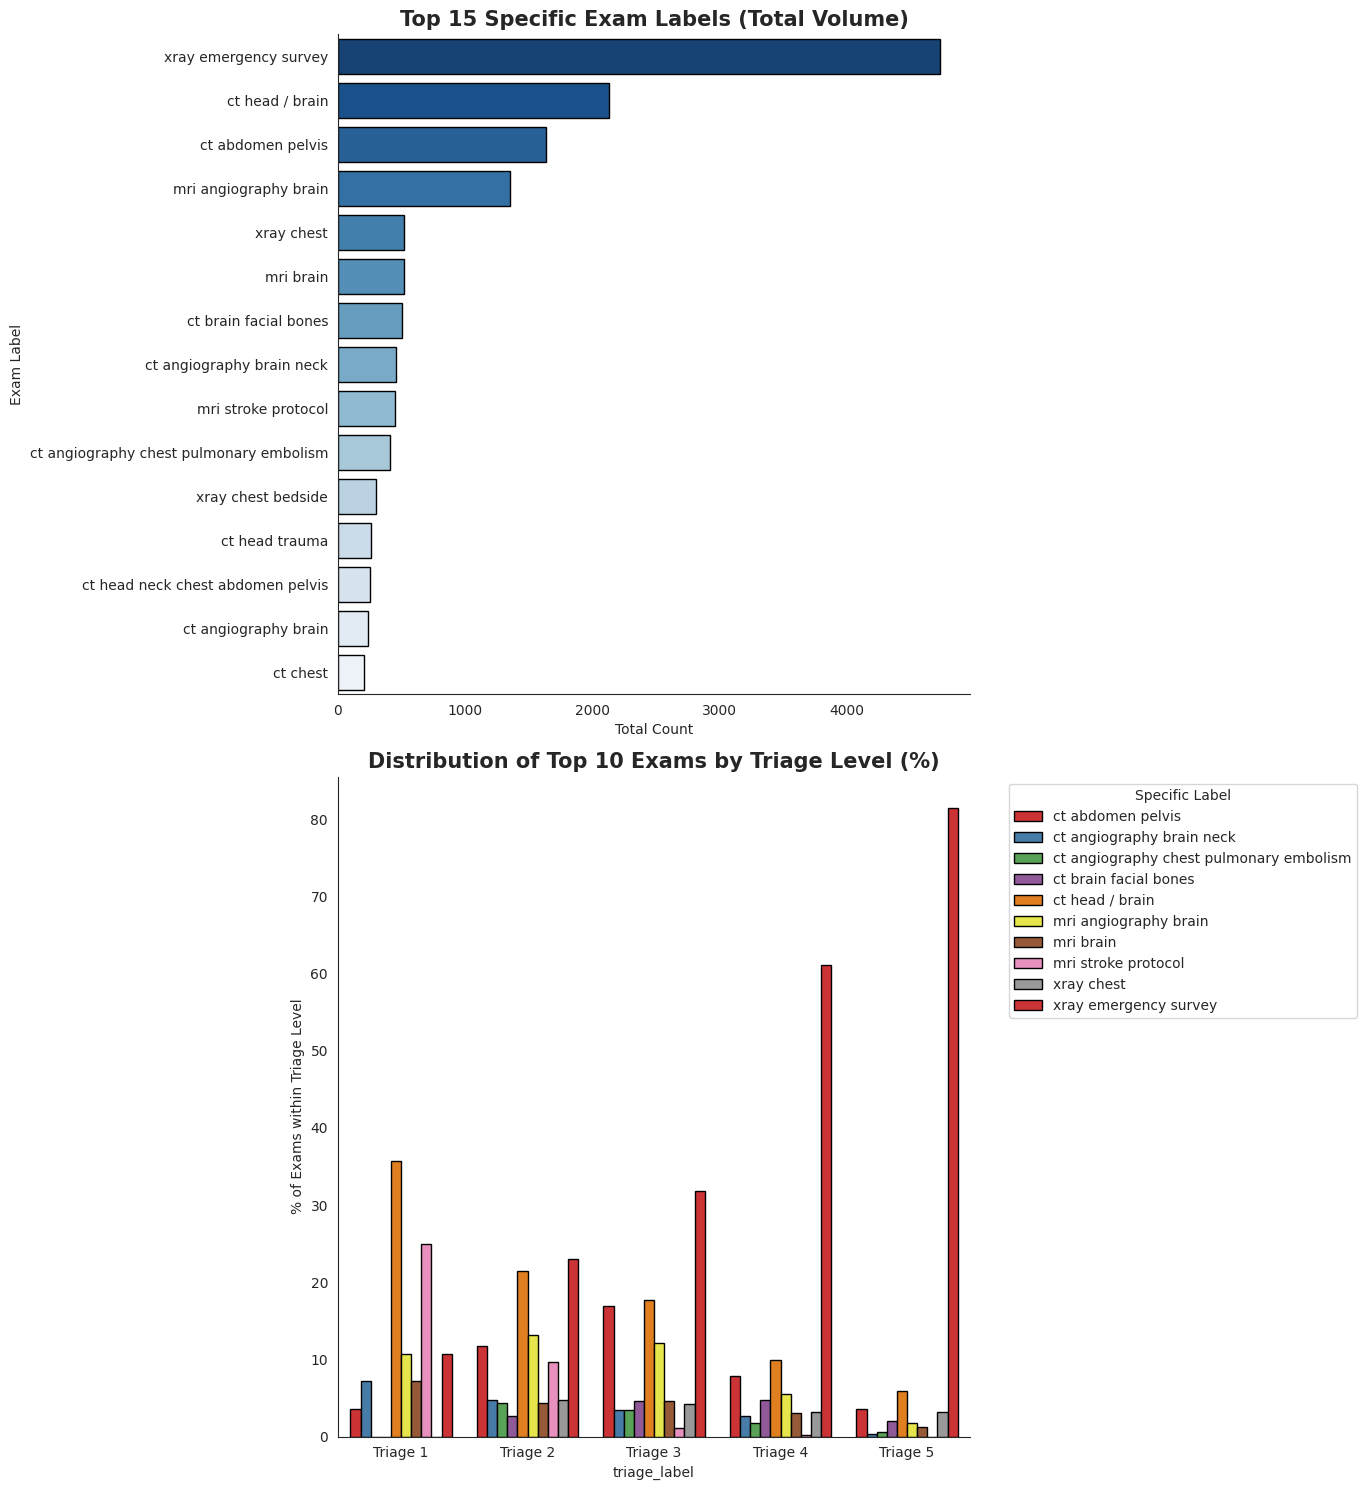

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# ================================================================
# 1. MELTING THE DATA (From Wide to Long)
# ================================================================
# We identify all columns that contain the actual exam labels
label_cols = [c for c in df.columns if any(x in c for x in ['ct_scan_', 'xray_', 'mri_', 'ultrasound_', 'radio_interventional_', 'nuclear_medecine_'])]

# We melt the dataframe: one row per exam per patient
df_long_labels = df.melt(
    id_vars=['nda', 'triage'],
    value_vars=label_cols,
    var_name='Column_Source',
    value_name='Exam_Label'
)

# Filter out 'NONE' and empty values
df_long_labels = df_long_labels[df_long_labels['Exam_Label'] != "NONE"].copy()
df_long_labels['triage_label'] = 'Triage ' + df_long_labels['triage'].astype(int).astype(str)

# ================================================================
# 2. RAW DISTRIBUTION (TOP 15 MOST FREQUENT EXAMS)
# ================================================================
raw_dist = df_long_labels['Exam_Label'].value_counts().reset_index()
raw_dist.columns = ['Exam Label', 'Total Count']

print("📦 RAW VOLUME: TOP 15 SPECIFIC EXAMS")
display(raw_dist.head(15))

# ================================================================
# 3. DISTRIBUTION BY TRIAGE (NORMALIZED)
# ================================================================
# We look at the top 10 exams overall and see how they are distributed across triage levels
top_10_names = raw_dist.head(10)['Exam Label'].tolist()
df_top_10 = df_long_labels[df_long_labels['Exam_Label'].isin(top_10_names)]

# Create a cross-tabulation (Count of exam per triage)
triage_dist = pd.crosstab(df_top_10['triage_label'], df_top_10['Exam_Label'], normalize='index') * 100

# ================================================================
# 4. VISUALIZATION (CLEAN WHITE)
# ================================================================
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 15), facecolor='white')

# Plot 1: Raw Volume
sns.barplot(data=raw_dist.head(15), x='Total Count', y='Exam Label', palette='Blues_r', ax=ax1, edgecolor='black')
ax1.set_title('Top 15 Specific Exam Labels (Total Volume)', fontsize=15, fontweight='bold')
ax1.set_facecolor('white')

# Plot 2: Top 10 Exams across Triage Levels
triage_plot_data = triage_dist.reset_index().melt(id_vars='triage_label', value_name='% of Exams')
sns.barplot(data=triage_plot_data, x='triage_label', y='% of Exams', hue='Exam_Label', palette='Set1', ax=ax2, edgecolor='black')
ax2.set_title('Distribution of Top 10 Exams by Triage Level (%)', fontsize=15, fontweight='bold')
ax2.set_ylabel('% of Exams within Triage Level')
ax2.legend(title='Specific Label', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_facecolor('white')

sns.despine()
plt.tight_layout()
plt.show()


✅ Analysis of pre-existing count columns:


,Category,Total Patients,Single Exam (n),Multiple Exams (n),Multi-Exam Rate (%)
1,XRAY,6736,6582,154,2.29
0,CT SCAN,7478,7336,142,1.90
2,MRI,2705,2660,45,1.66
3,ULTRASOUND,498,487,11,2.21
4,NUCLEAR MEDICINE,2,2,0,0.00
5,RADIO INTERVENTIONAL,40,40,0,0.00


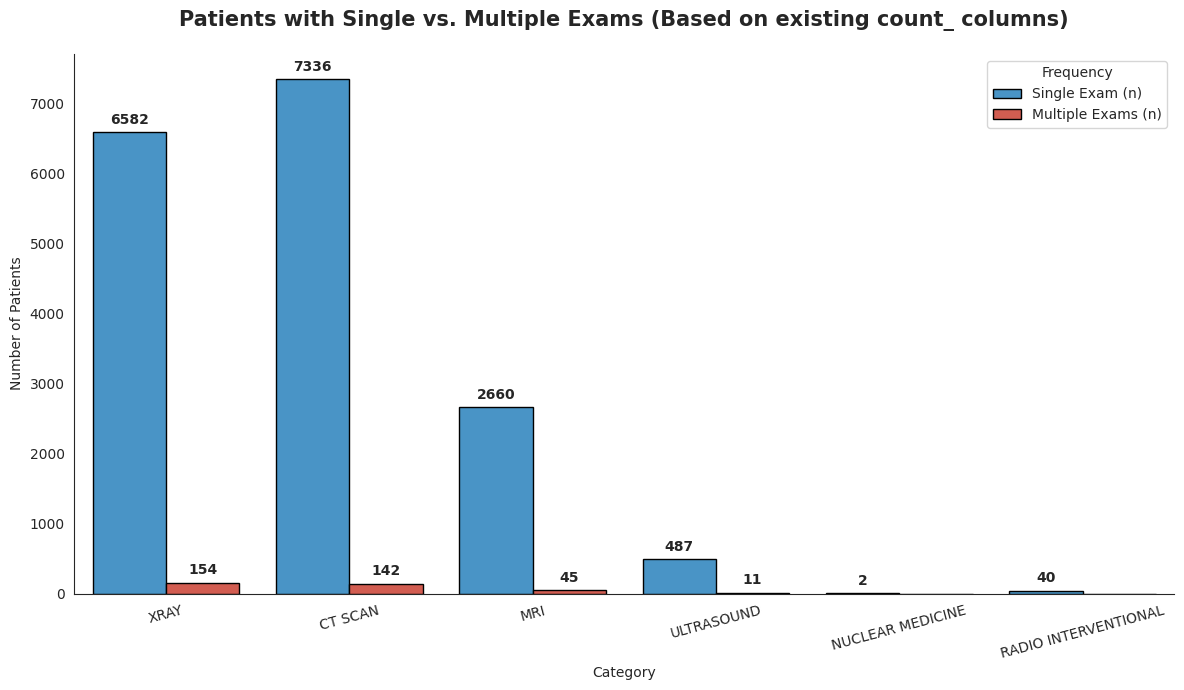

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# ================================================================
#  CONFIGURATION (Basée sur tes colonnes existantes)
# ================================================================
# On définit les catégories pour faire le lien avec tes colonnes count_
imaging_types = ['ct_scan', 'xray', 'mri', 'ultrasound',
                 'nuclear_medicine', 'radio_interventional']

# ================================================================
#  ANALYZE MULTIPLE EXAMS PER PATIENT
# ================================================================
multi_exam_stats = []

for cat in imaging_types:
    col = f'count_{cat}'

    if col in df.columns:
        category_label = cat.upper().replace('_', ' ')

        # Filter patients with at least 1 exam of this type
        # On s'assure que c'est bien numérique
        active_patients = df[df[col] > 0]
        total_active = len(active_patients)

        if total_active > 0:
            single = len(active_patients[active_patients[col] == 1])
            multiple = len(active_patients[active_patients[col] >= 2])

            multi_exam_stats.append({
                'Category': category_label,
                'Total Patients': total_active,
                'Single Exam (n)': single,
                'Multiple Exams (n)': multiple,
                'Multi-Exam Rate (%)': round((multiple / total_active) * 100, 2)
            })

# ================================================================
#  DISPLAY & VISUALIZATION
# ================================================================
if not multi_exam_stats:
    print("❌ Error: No 'count_' columns found in the dataframe. Please check your CSV column names.")
else:
    df_results = pd.DataFrame(multi_exam_stats).sort_values(by='Multiple Exams (n)', ascending=False)

    print("\n✅ Analysis of pre-existing count columns:")
    display(df_results)

    # Plotting
    sns.set_style("white")
    plt.figure(figsize=(12, 7), facecolor='white')

    # On prépare les données pour Seaborn
    df_plot = df_results.melt(id_vars='Category',
                               value_vars=['Single Exam (n)', 'Multiple Exams (n)'],
                               var_name='Frequency', value_name='Patient Count')

    ax = sns.barplot(data=df_plot, x='Category', y='Patient Count', hue='Frequency',
                     palette=['#3498db', '#e74c3c'], edgecolor='black')

    plt.title('Patients with Single vs. Multiple Exams (Based on existing count_ columns)',
              fontsize=15, fontweight='bold', pad=20)
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=15)
    plt.legend(title='Frequency')

    # Annotate bars
    for p in ax.patches:
        height = int(p.get_height())
        if height > 0:
            ax.annotate(f'{height}', (p.get_x() + p.get_width()/2., height),
                        ha='center', va='center', xytext=(0, 9),
                        textcoords='offset points', fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()

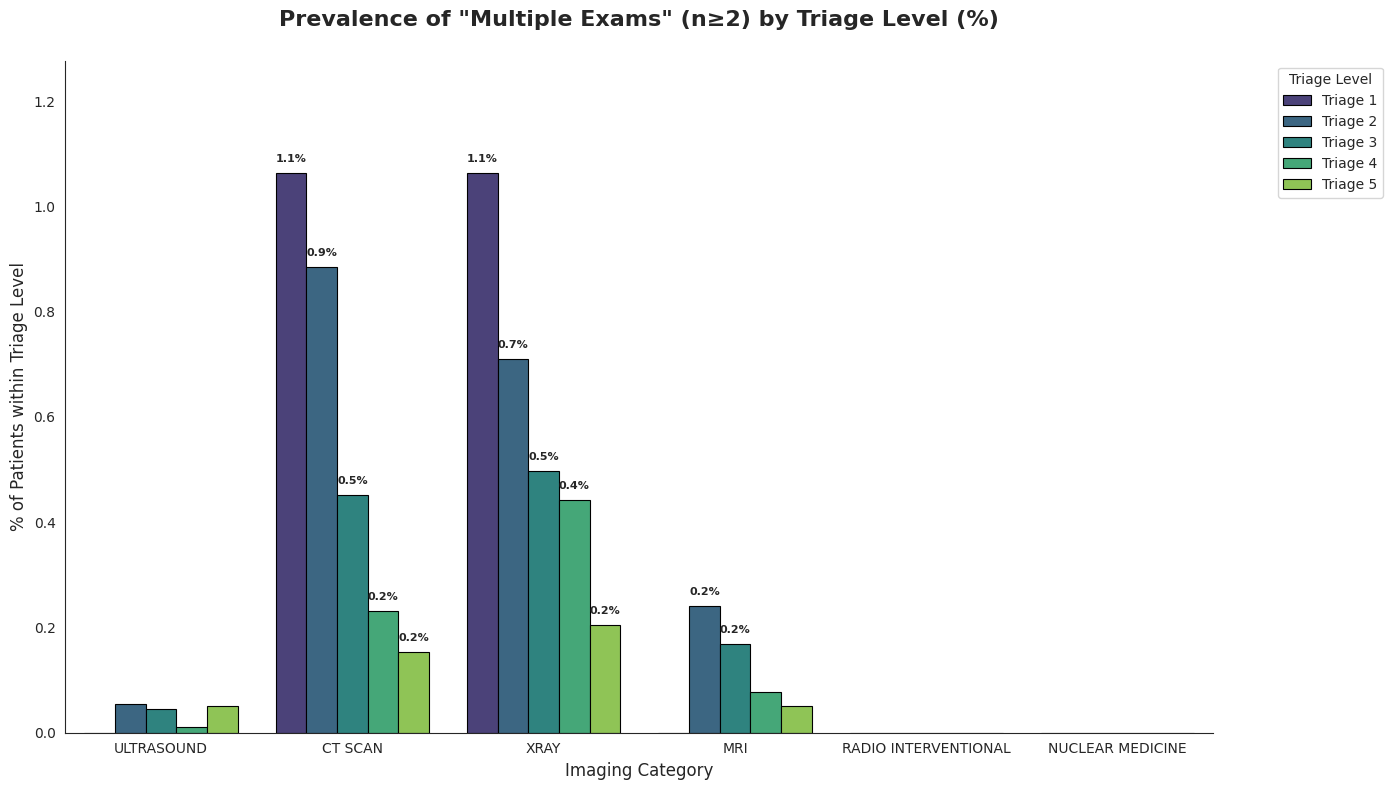

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================================================================
# 1. CALCULATE PERCENTAGES BY TRIAGE LEVEL
# ================================
# Identify our count columns again
count_cols = [c for c in df.columns if c.startswith('count_')]
df['triage_label'] = 'Triage ' + df['triage'].astype(int).astype(str)

# Calculate total patients per triage level for normalization
triage_totals = df['triage_label'].value_counts()

multi_pct_data = []

for col in count_cols:
    exam_category = col.replace('count_', '').upper().replace('_', ' ')

    # Count how many patients in each triage have >= 2 exams
    multi_counts = df[df[col] >= 2].groupby('triage_label').size()

    # Convert to percentage relative to the TOTAL number of patients in that Triage
    multi_pct = (multi_counts / triage_totals * 100).fillna(0).reset_index()
    multi_pct.columns = ['Triage', 'Percentage']
    multi_pct['Exam_Category'] = exam_category

    multi_pct_data.append(multi_pct)

# Combine results
df_multi_pct = pd.concat(multi_pct_data, ignore_index=True)

# ================================================================
# 2. VISUALIZATION (CLEAN WHITE THEME)
# ================================
sns.set_style("white")
plt.figure(figsize=(14, 8), facecolor='white')

# Create the bar plot
ax = sns.barplot(
    data=df_multi_pct,
    x='Exam_Category',
    y='Percentage',
    hue='Triage',
    palette='viridis',
    edgecolor='black',
    linewidth=0.8
)

# Styling
plt.title('Prevalence of "Multiple Exams" (n≥2) by Triage Level (%)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('% of Patients within Triage Level', fontsize=12)
plt.xlabel('Imaging Category', fontsize=12)
plt.legend(title='Triage Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels
for p in ax.patches:
    height = p.get_height()
    if height > 0.1: # Display only for significant values
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 10),
                    textcoords='offset points', fontsize=8, fontweight='bold')

sns.despine()
plt.ylim(0, df_multi_pct['Percentage'].max() * 1.2) # Add space for labels
plt.tight_layout()
plt.show()

📊 AVERAGE IMAGING INTENSITY PER TRIAGE LEVEL


,Triage Level,Average Exam Count
0,Triage 1,0.49
1,Triage 2,0.74
2,Triage 3,0.66
3,Triage 4,0.48
4,Triage 5,0.27


/tmp/ipykernel_599530/162480945.py:44: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




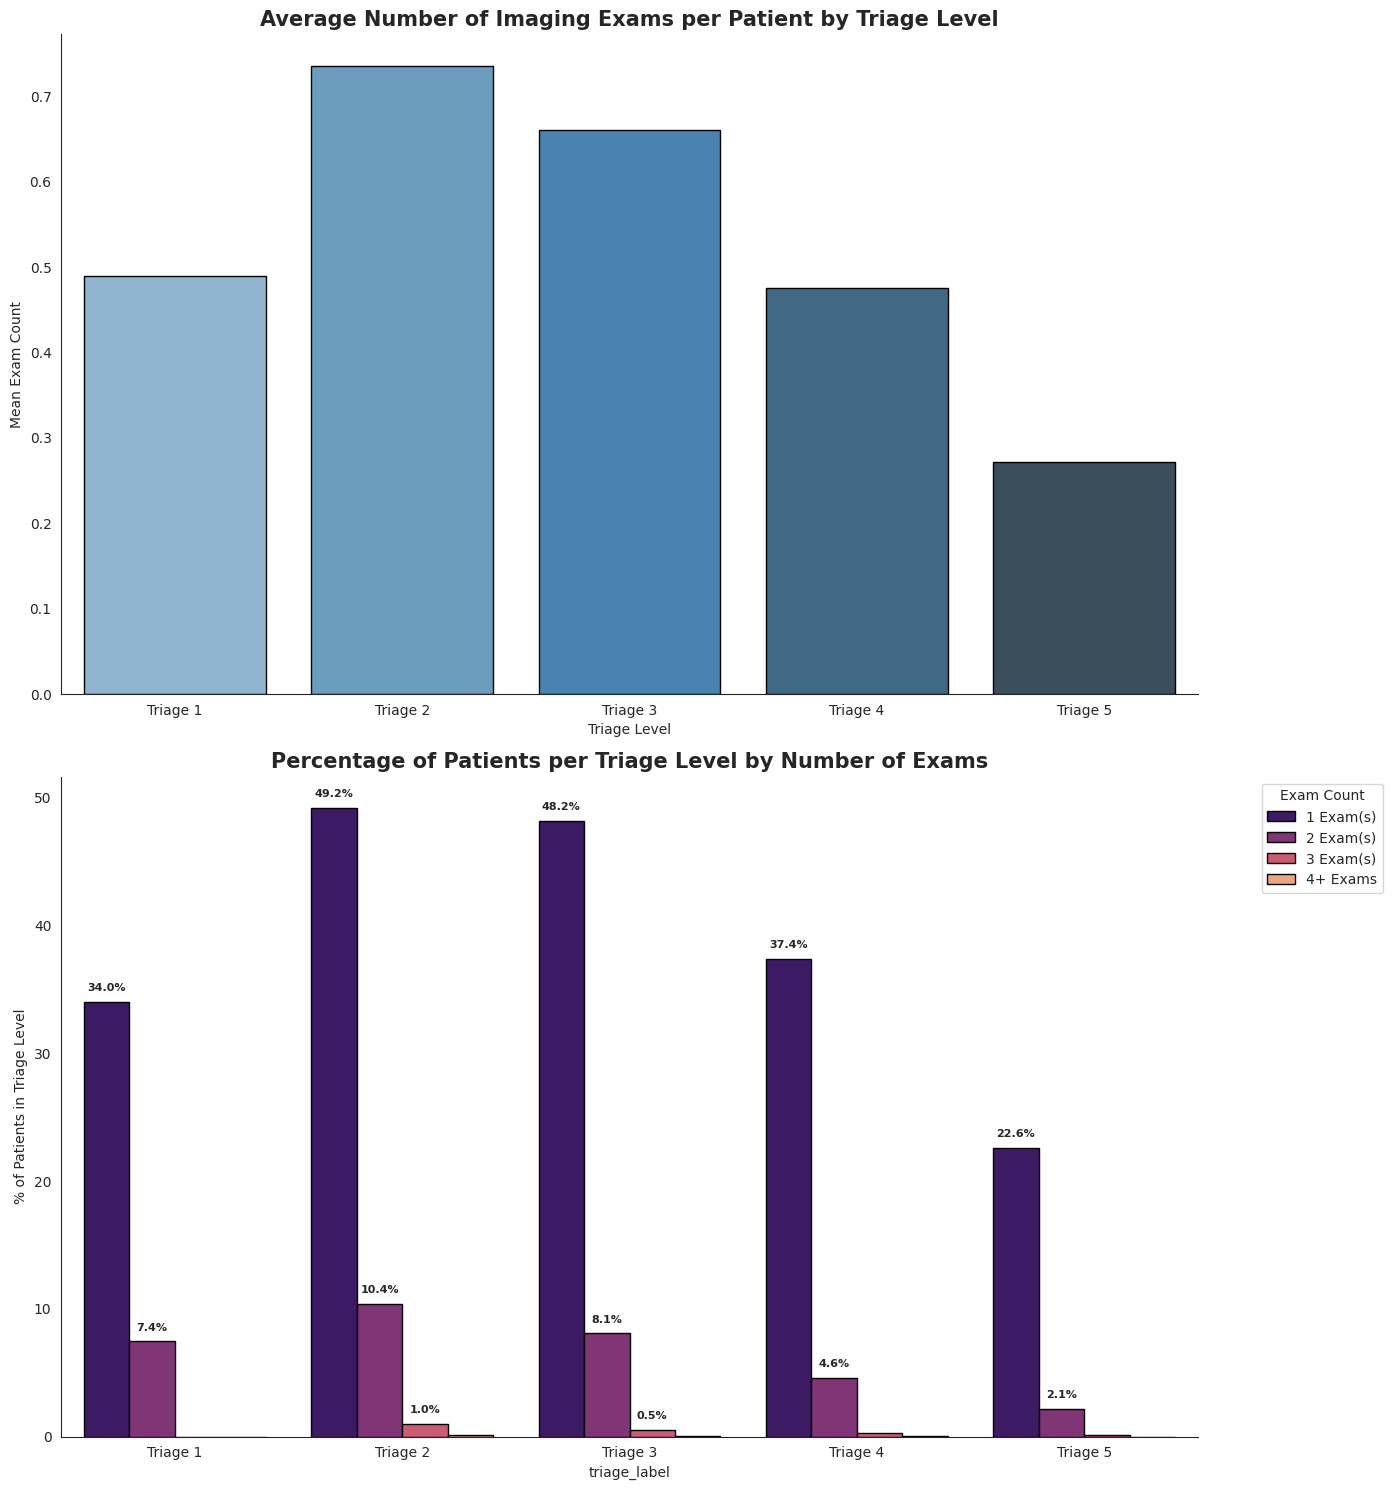

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# ================================================================
# 1. MEAN TOTAL_EXAM_COUNT PER TRIAGE
# ================================================================
df['triage_label'] = 'Triage ' + df['triage'].astype(int).astype(str)

# Calculate the average intensity per level
mean_intensity = df.groupby('triage_label')['imaging_exam_count'].mean().reset_index()
mean_intensity.columns = ['Triage Level', 'Average Exam Count']

print("📊 AVERAGE IMAGING INTENSITY PER TRIAGE LEVEL")
display(mean_intensity.round(2))

# ================================================================
# 2. PERCENTAGE OF PATIENTS BY EXAM VOLUME (1, 2, 3, 4+)
# ================================================================
# We define groups for the number of exams
def group_exam_counts(x):
    if x == 0: return '0 Exams'
    if x >= 4: return '4+ Exams'
    return f'{int(x)} Exam(s)'

df['exam_volume_group'] = df['imaging_exam_count'].apply(group_exam_counts)

# Calculate the distribution: % of Triage X that has Y exams
volume_dist = pd.crosstab(df['triage_label'], df['exam_volume_group'], normalize='index') * 100

# Reorder columns for a logical progression (1, 2, 3, 4+)
# Note: We exclude '0 Exams' if you only want to see patients with imaging
desired_order = ['1 Exam(s)', '2 Exam(s)', '3 Exam(s)', '4+ Exams']
volume_dist = volume_dist.reindex(columns=[c for c in desired_order if c in volume_dist.columns])

# ================================================================
# 3. VISUALIZATION (CLEAN WHITE THEME)
# ================================================================
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 15), facecolor='white')

# --- Plot 1: Mean Intensity (Line/Bar) ---
sns.barplot(data=mean_intensity, x='Triage Level', y='Average Exam Count',
            palette='Blues_d', ax=ax1, edgecolor='black')
ax1.set_title('Average Number of Imaging Exams per Patient by Triage Level', fontsize=15, fontweight='bold')
ax1.set_ylabel('Mean Exam Count')

# --- Plot 2: Percentage Distribution (1, 2, 3, 4+) ---
plot_data_long = volume_dist.reset_index().melt(id_vars='triage_label', var_name='Volume', value_name='Percentage')
sns.barplot(data=plot_data_long, x='triage_label', y='Percentage', hue='Volume',
            palette='magma', ax=ax2, edgecolor='black')

ax2.set_title('Percentage of Patients per Triage Level by Number of Exams', fontsize=15, fontweight='bold')
ax2.set_ylabel('% of Patients in Triage Level')
ax2.legend(title='Exam Count', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels
for p in ax2.patches:
    h = p.get_height()
    if h > 0.5:
        ax2.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', xytext=(0, 10),
                     textcoords='offset points', fontsize=8, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

In [72]:
# ======================================================================
# IMAGING EXAM REPARTITION (ORGAN/TEXT CONTENT ONLY)
# ======================================================================

import pandas as pd
import numpy as np

# 1. Manually define or strictly filter content columns
# We exclude any column starting with 'has_' to avoid binary flags
imaging_groups = {
    'Scanner': [c for c in df.columns if 'ct_scan_' in c and not c.startswith('has_')],
    'MRI': [c for c in df.columns if 'mri_' in c and not c.startswith('has_')],
    'Conventional Radio': [c for c in df.columns if 'xray_' in c and not c.startswith('has_')],
    'Ultrasound': [c for c in df.columns if 'ultrasound_' in c and not c.startswith('has_')],
    'Interventional': [c for c in df.columns if 'radio_interventional_' in c and not c.startswith('has_')],
    'Nuclear Medicine': [c for c in df.columns if 'nuclear_medicine_' in c and not c.startswith('has_')]
}

def get_imaging_stats_refined(sub_df):
    """
    Calculates stats using only the text columns containing exam names.
    Ignores binary summary flags and 'NONE' entries.
    """
    stats = {}
    total_patients = len(sub_df)

    if total_patients == 0:
        return pd.DataFrame()

    for group, cols in imaging_groups.items():
        if not cols: # Skip if no columns were found for this category
            continue

        # Create mask: True only if value is not 'NONE', not NaN, and not a 0/1 flag
        # We ensure we are looking at the string content
        group_data = sub_df[cols]
        mask = group_data.notna() & (group_data.astype(str) != 'NONE') & (group_data.astype(str) != '0')

        total_exams = mask.sum().sum()
        patients_with_exam = mask.any(axis=1).sum()

        stats[group] = {
            'Total Exams Count': int(total_exams),
            'Patients Count': int(patients_with_exam),
            '% of Sub-Population': round((patients_with_exam / total_patients) * 100, 1)
        }
    return pd.DataFrame(stats).T

# 2. Execution
stats_all = get_imaging_stats_refined(df)
stats_imaging_only = get_imaging_stats_refined(df[df['has_imaging_any'] == 1])

print("📊 STATS: GENERAL POPULATION")
display(stats_all)

print("\n🔍 STATS: IMAGING POPULATION (has_imaging_any == 1)")
display(stats_imaging_only)

📊 STATS: GENERAL POPULATION


,Total Exams Count,Patients Count,% of Sub-Population
Scanner,7623.0,7478.0,25.1
MRI,2750.0,2705.0,9.1
Conventional Radio,6898.0,6736.0,22.6
Ultrasound,509.0,498.0,1.7
Interventional,40.0,40.0,0.1
Nuclear Medicine,2.0,2.0,0.0



🔍 STATS: IMAGING POPULATION (has_imaging_any == 1)


,Total Exams Count,Patients Count,% of Sub-Population
Scanner,7623.0,7478.0,48.9
MRI,2750.0,2705.0,17.7
Conventional Radio,6898.0,6736.0,44.0
Ultrasound,509.0,498.0,3.3
Interventional,40.0,40.0,0.3
Nuclear Medicine,2.0,2.0,0.0


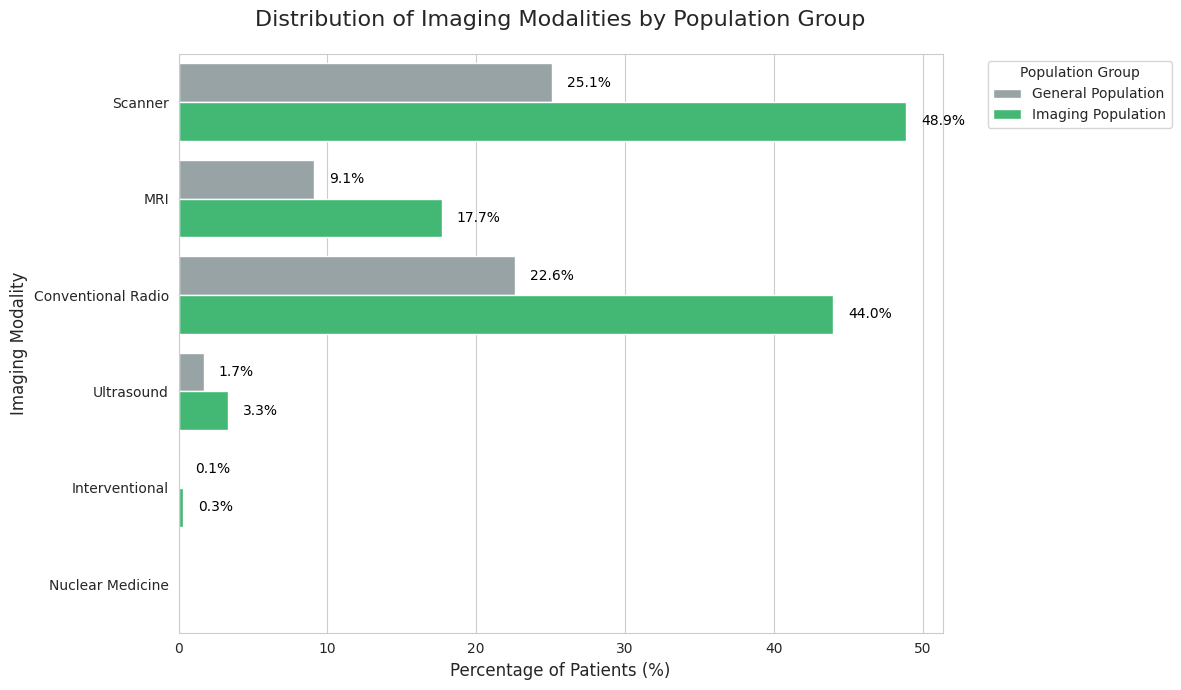

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================================
# GRAPH: IMAGING MODALITIES DISTRIBUTION
# ======================================================================

# 1. Prepare data for plotting
# We combine both dataframes into a long format for Seaborn
stats_all['Population'] = 'General Population'
stats_imaging_only['Population'] = 'Imaging Population'

df_plot = pd.concat([
    stats_all.reset_index().rename(columns={'index': 'Modality'}),
    stats_imaging_only.reset_index().rename(columns={'index': 'Modality'})
])

# 2. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create the grouped bar chart
ax = sns.barplot(
    data=df_plot,
    x='% of Sub-Population',
    y='Modality',
    hue='Population',
    palette=['#95a5a6', '#2ecc71'] # Grey for general, Green for specific
)

# 3. Aesthetics & Labels
plt.title('Distribution of Imaging Modalities by Population Group', fontsize=16, pad=20)
plt.xlabel('Percentage of Patients (%)', fontsize=12)
plt.ylabel('Imaging Modality', fontsize=12)
plt.legend(title='Population Group', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels on the bars for clarity
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Only label bars with values
        ax.annotate(f'{width:.1f}%',
                    (width + 1, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [74]:
# ======================================================================
# FULL LIST OF UNIQUE EXAM TYPES PER CATEGORY
# ======================================================================

def get_all_unique_modalities(sub_df):
    all_categories_report = {}

    for group, cols in imaging_groups.items():
        # 1. On récupère toutes les valeurs de toutes les colonnes du groupe
        all_values = sub_df[cols].values.flatten()

        # 2. On filtre pour ne garder que les vrais noms d'examens
        # On ignore 'NONE', '0', les NaN et les espaces vides
        filtered_values = [
            str(val).strip() for val in all_values
            if pd.notna(val) and str(val).strip() not in ['NONE', '0', 'nan', '']
        ]

        if filtered_values:
            # 3. On compte les occurrences pour chaque examen unique
            counts = pd.Series(filtered_values).value_counts()

            # 4. On crée un DataFrame propre pour cette catégorie
            df_res = pd.DataFrame({
                'Exam Name': counts.index,
                'Count': counts.values,
                'Percentage': (counts.values / counts.sum() * 100).round(2)
            })
            all_categories_report[group] = df_res

    return all_categories_report

# On génère le rapport pour la population ayant eu de l'imagerie
full_report = get_all_unique_modalities(df[df['has_imaging_any'] == 1])

# Affichage des résultats pour chaque catégorie
for group, report_df in full_report.items():
    print(f"\n{'='*50}")
    print(f"📋 CATEGORY: {group}")
    print(f"{'='*50}")
    # On affiche tout le tableau (sans limite de lignes)
    display(report_df)


📋 CATEGORY: Scanner


,Exam Name,Count,Percentage
0,ct head / brain,2129,27.93
1,ct abdomen pelvis,1632,21.41
2,ct brain facial bones,508,6.66
3,ct angiography brain neck,454,5.96
4,ct angiography chest pulmonary embolism,411,5.39
5,ct head trauma,264,3.46
6,ct head neck chest abdomen pelvis,251,3.29
7,ct angiography brain,239,3.14
8,ct chest,208,2.73
9,ct chest abdomen pelvis,158,2.07



📋 CATEGORY: MRI


,Exam Name,Count,Percentage
0,mri angiography brain,1352,49.16
1,mri brain,517,18.80
2,mri stroke protocol,453,16.47
3,mri angiography neck brain,134,4.87
4,mri spinal cord,99,3.60
5,mri lumbar spine,80,2.91
6,mri brain and spinal cord,33,1.20
7,mri cervical spine,18,0.65
8,mri angiography spine,15,0.55
9,mri angiography neck,8,0.29



📋 CATEGORY: Conventional Radio


...

,Exam Name,Count,Percentage
0,scrotal doppler ultrasound,168,33.01
1,abdomen pelvis ultrasound,148,29.08
2,abdominal ultrasound,37,7.27
3,venous doppler ultrasound lower limb,36,7.07
4,scrotal ultrasound,23,4.52
5,renal and bladder ultrasound,16,3.14
6,upper limb soft tissue ultrasound,8,1.57
7,venous doppler ultrasound upper limb,8,1.57
8,lower limb joint ultrasound,7,1.38
9,renal transplant doppler ultrasound,7,1.38



📋 CATEGORY: Interventional


,Exam Name,Count,Percentage
0,mechanical thrombectomy stroke,24,60.0
1,gastrostomy tube replacement,8,20.0
2,hepatic drainage,1,2.5
3,lumbar puncture,1,2.5
4,percutaneous nephrostomy,1,2.5
5,pelvic drainage,1,2.5
6,genitourinary guided biopsy,1,2.5
7,midline catheter insertion,1,2.5
8,picc line insertion,1,2.5
9,av fistula thrombectomy,1,2.5



📋 CATEGORY: Nuclear Medicine


,Exam Name,Count,Percentage
0,v/q lung scintigraphy pulmonary embolism krypton,2,100.0


/tmp/ipykernel_599530/3311457480.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/3311457480.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/3311457480.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/3311457480.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/3311457480.py:35: FutureWarning:



Passing `palette` without assigning `hue` 

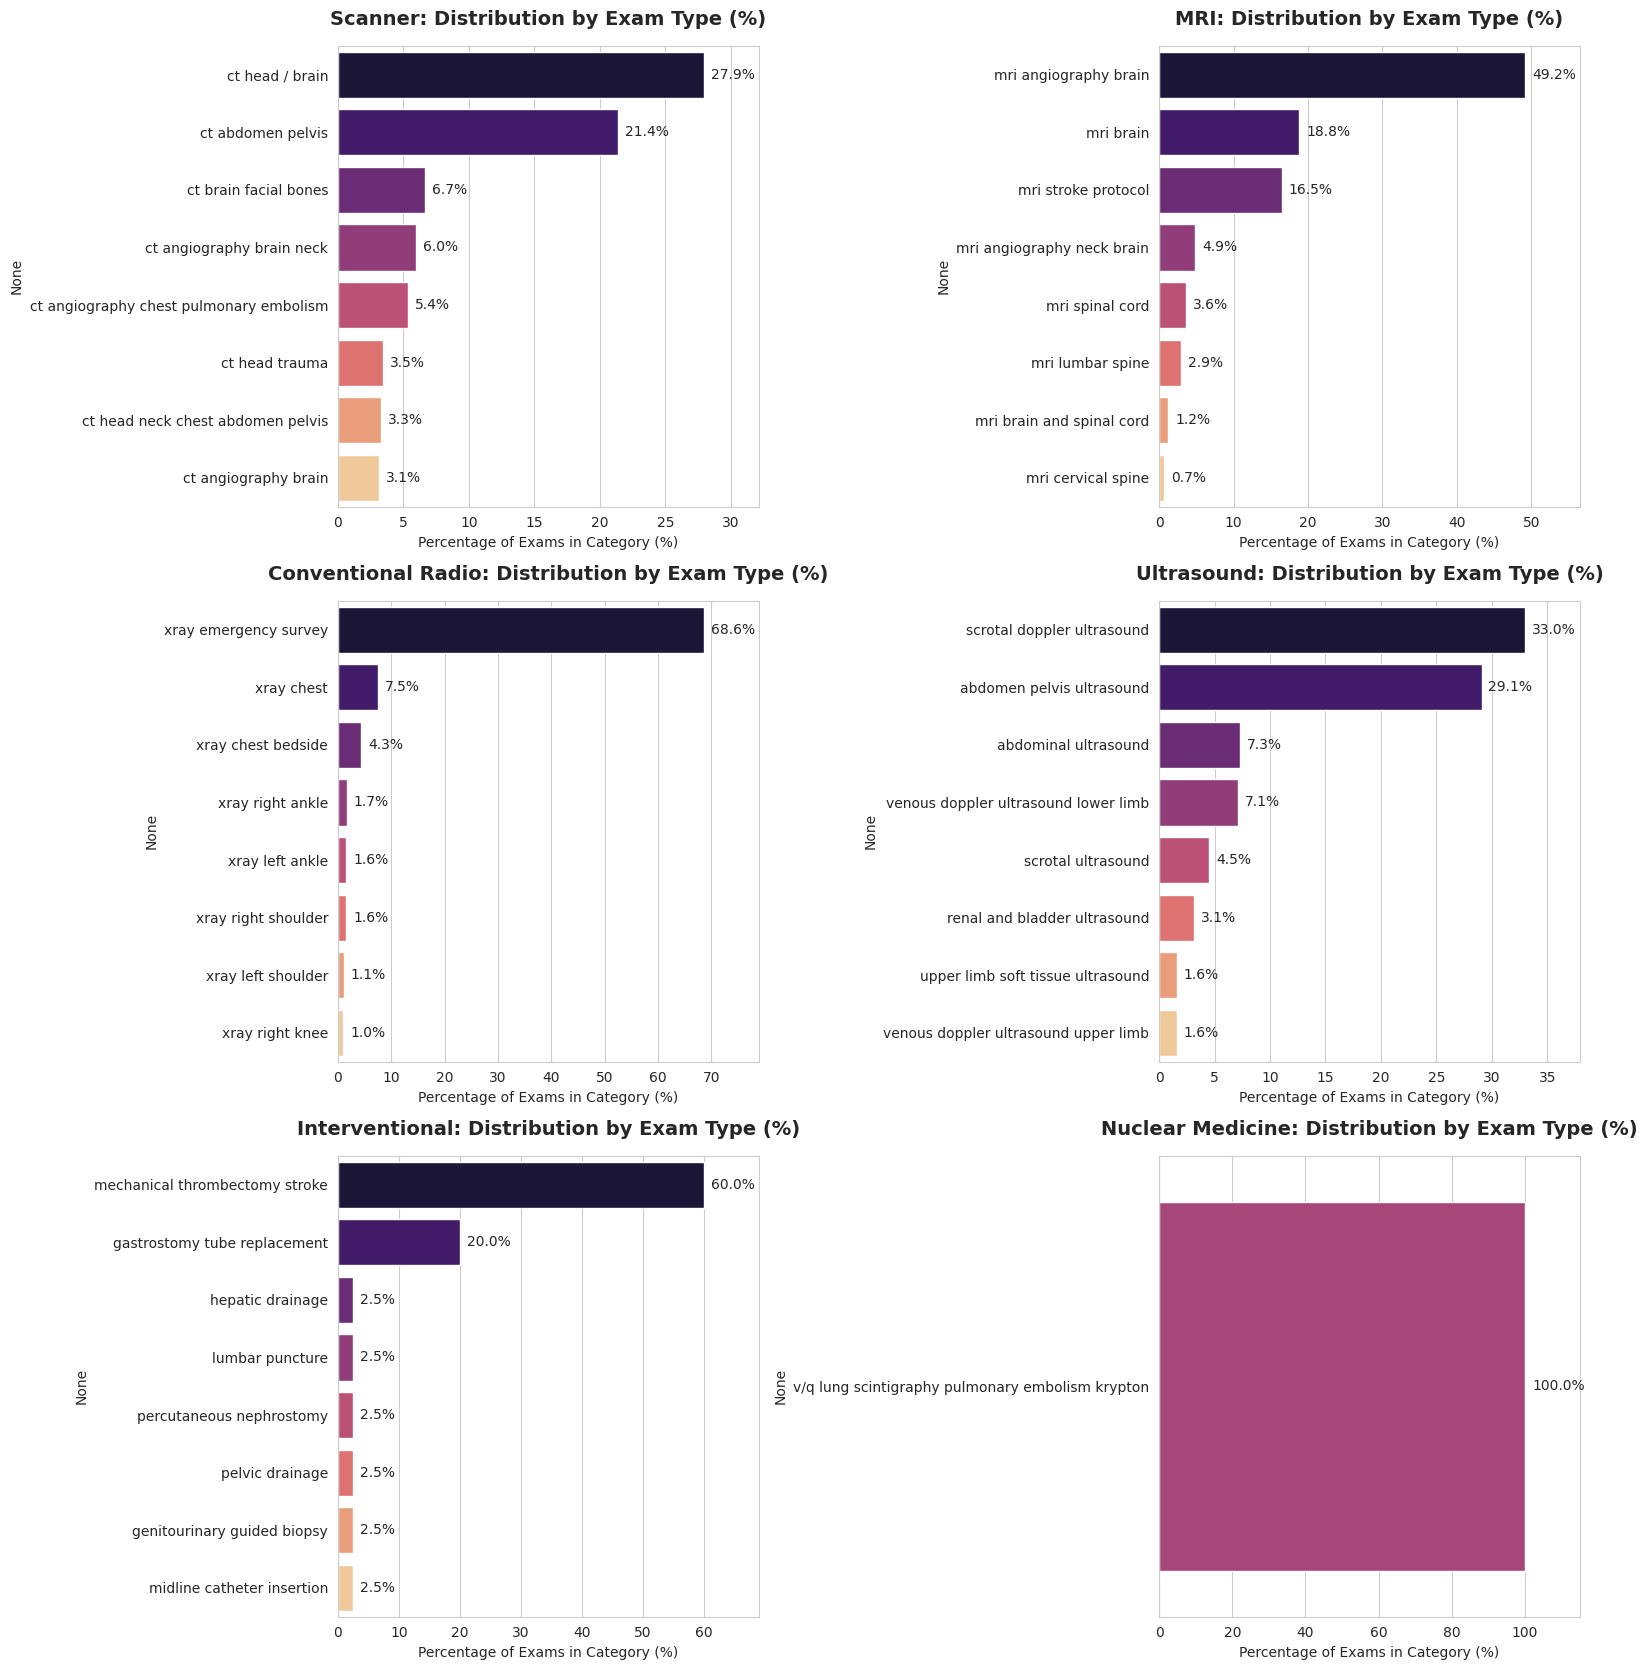

In [75]:
# ======================================================================
# PERCENTAGE BREAKDOWN OF EXAM TYPES PER CATEGORY
# ======================================================================

def get_top_exams_pct(sub_df, top_n=8):
    group_results = {}

    for group, cols in imaging_groups.items():
        # 1. Collect all valid text values
        all_values = sub_df[cols].values.flatten()
        filtered_values = [
            str(val).strip() for val in all_values
            if pd.notna(val) and str(val).strip() not in ['NONE', '0', 'nan', '']
        ]

        if filtered_values:
            # 2. Calculate Value Counts
            counts = pd.Series(filtered_values).value_counts()
            # 3. Convert to Percentage relative to the total exams in THIS group
            pcts = (counts / counts.sum()) * 100
            group_results[group] = pcts.head(top_n)

    return group_results

# Analyze the imaging population
top_exams_pct_data = get_top_exams_pct(df[df['has_imaging_any'] == 1])

# --- PLOTTING ---
n_groups = len(top_exams_pct_data)
fig, axes = plt.subplots(nrows=(n_groups + 1) // 2, ncols=2, figsize=(16, n_groups * 2.8))
axes = axes.flatten()

for i, (group, data) in enumerate(top_exams_pct_data.items()):
    # Plot horizontal bars
    sns.barplot(x=data.values, y=data.index, ax=axes[i], palette='magma')

    axes[i].set_title(f'{group}: Distribution by Exam Type (%)', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel('Percentage of Exams in Category (%)')
    axes[i].set_xlim(0, max(data.values) * 1.15) # Leave room for labels

    # Add percentage labels on the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].annotate(f'{width:.1f}%',
                        (width, p.get_y() + p.get_height() / 2),
                        ha='left', va='center', xytext=(5, 0),
                        textcoords='offset points', fontsize=10)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_599530/2100626370.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/2100626370.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/2100626370.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/2100626370.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/2100626370.py:31: FutureWarning:



Passing `palette` without assigning `hue` 

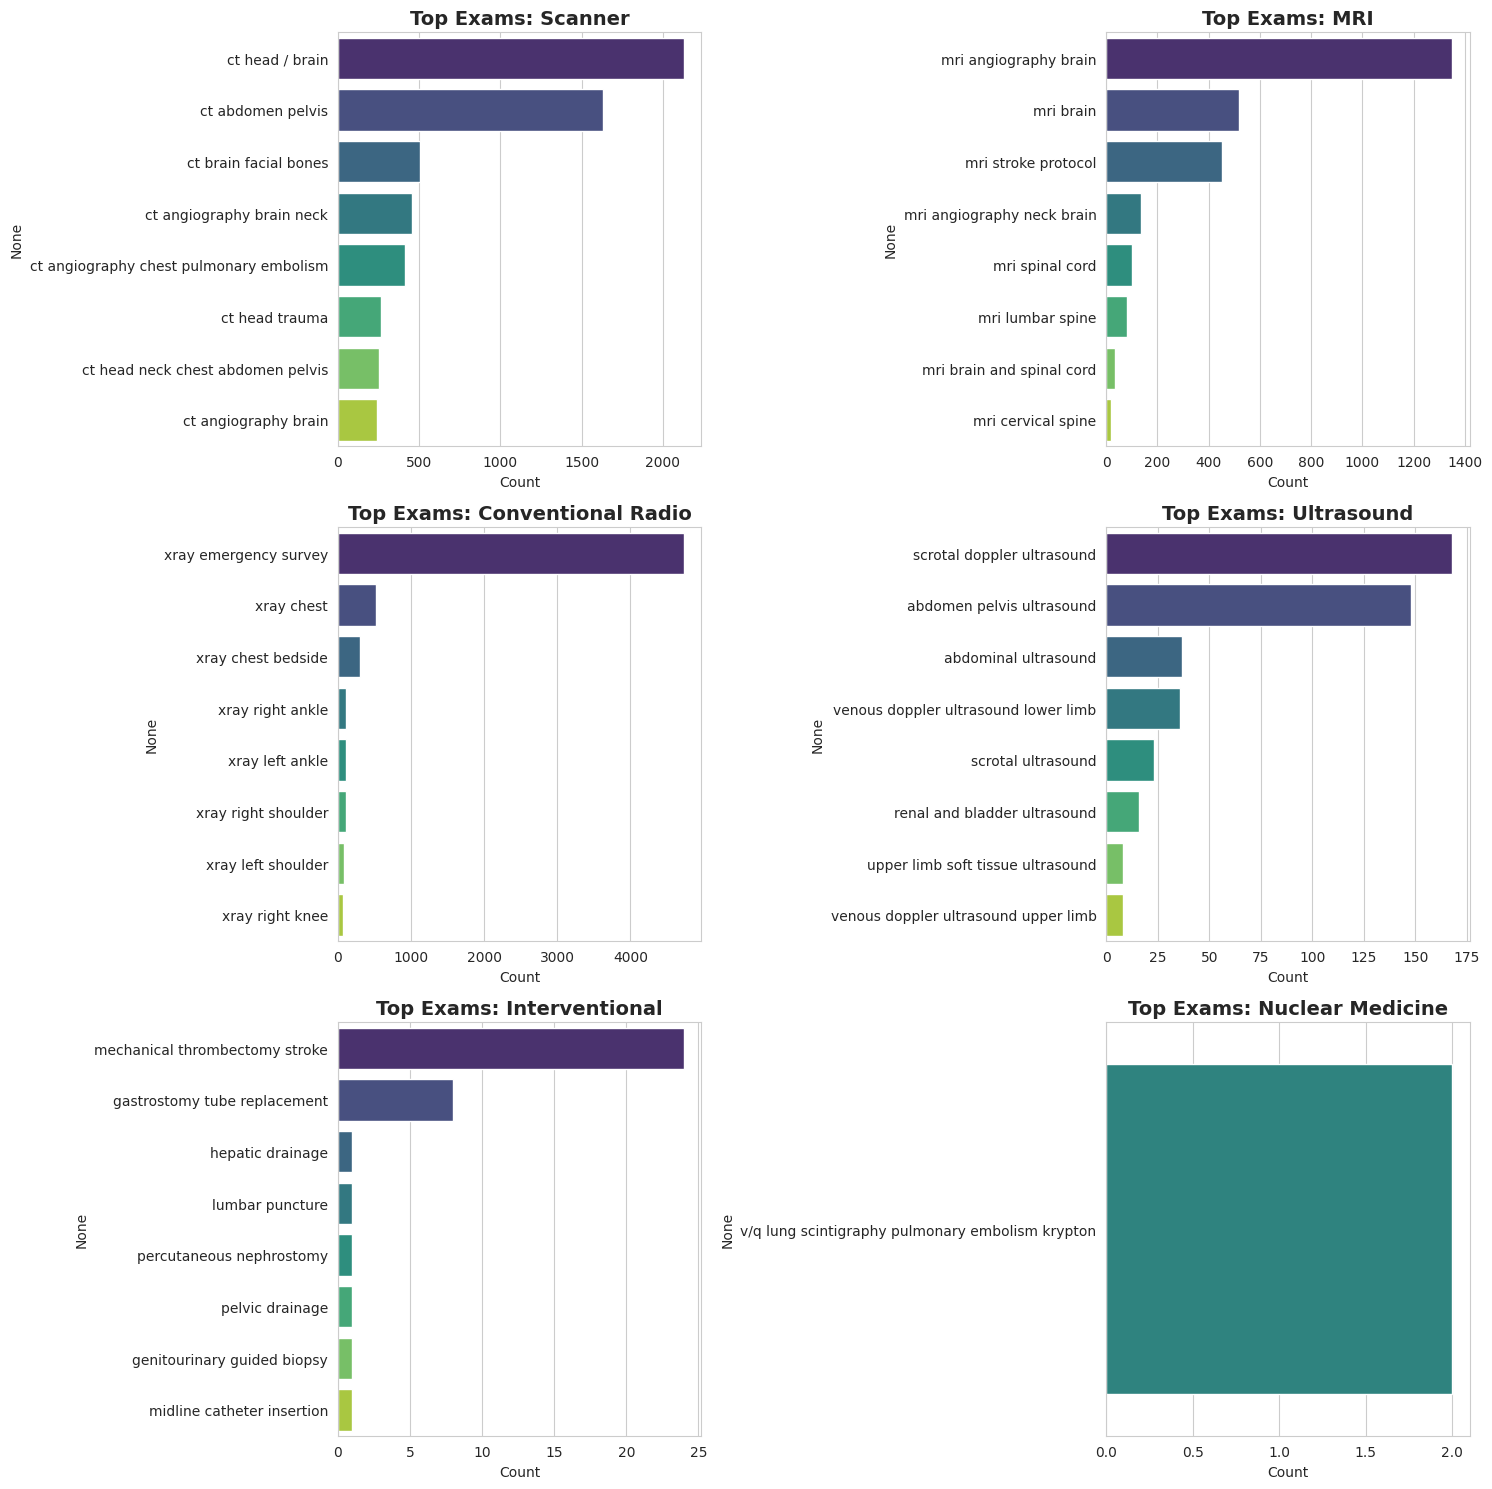

In [76]:
# ======================================================================
# BREAKDOWN OF EXAM TYPES (ORGAN/SPECIFIC) PER CATEGORY
# ======================================================================

def get_top_exams_per_group(sub_df, top_n=8):
    group_results = {}

    for group, cols in imaging_groups.items():
        # 1. Collect all non-NONE text values from all columns in the group
        all_values = sub_df[cols].values.flatten()
        # 2. Filter out NONE, NaN, 0, and empty strings
        filtered_values = [
            str(val).strip() for val in all_values
            if pd.notna(val) and str(val).strip() not in ['NONE', '0', 'nan', '']
        ]

        if filtered_values:
            group_results[group] = pd.Series(filtered_values).value_counts().head(top_n)

    return group_results

# Analyze the imaging population
top_exams_data = get_top_exams_per_group(df[df['has_imaging_any'] == 1])

# --- PLOTTING ---
n_groups = len(top_exams_data)
fig, axes = plt.subplots(nrows=(n_groups + 1) // 2, ncols=2, figsize=(15, n_groups * 2.5))
axes = axes.flatten()

for i, (group, data) in enumerate(top_exams_data.items()):
    sns.barplot(x=data.values, y=data.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Exams: {group}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].tick_params(axis='both', which='major', labelsize=10)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### TRIAGE DURATION EXPLORATION BY LVL OF TRIAGE ###

📊 TRIAGE DURATION STATISTICS (Ordered 1 to 5)


,triage_label,mean,median,std
0,Triage 1,7.37,5.0,5.68
1,Triage 2,7.31,6.0,4.11
2,Triage 3,6.30,6.0,3.37
3,Triage 4,5.29,5.0,3.02
4,Triage 5,4.08,3.0,2.56


/tmp/ipykernel_599530/12786262.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_599530/12786262.py:47: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




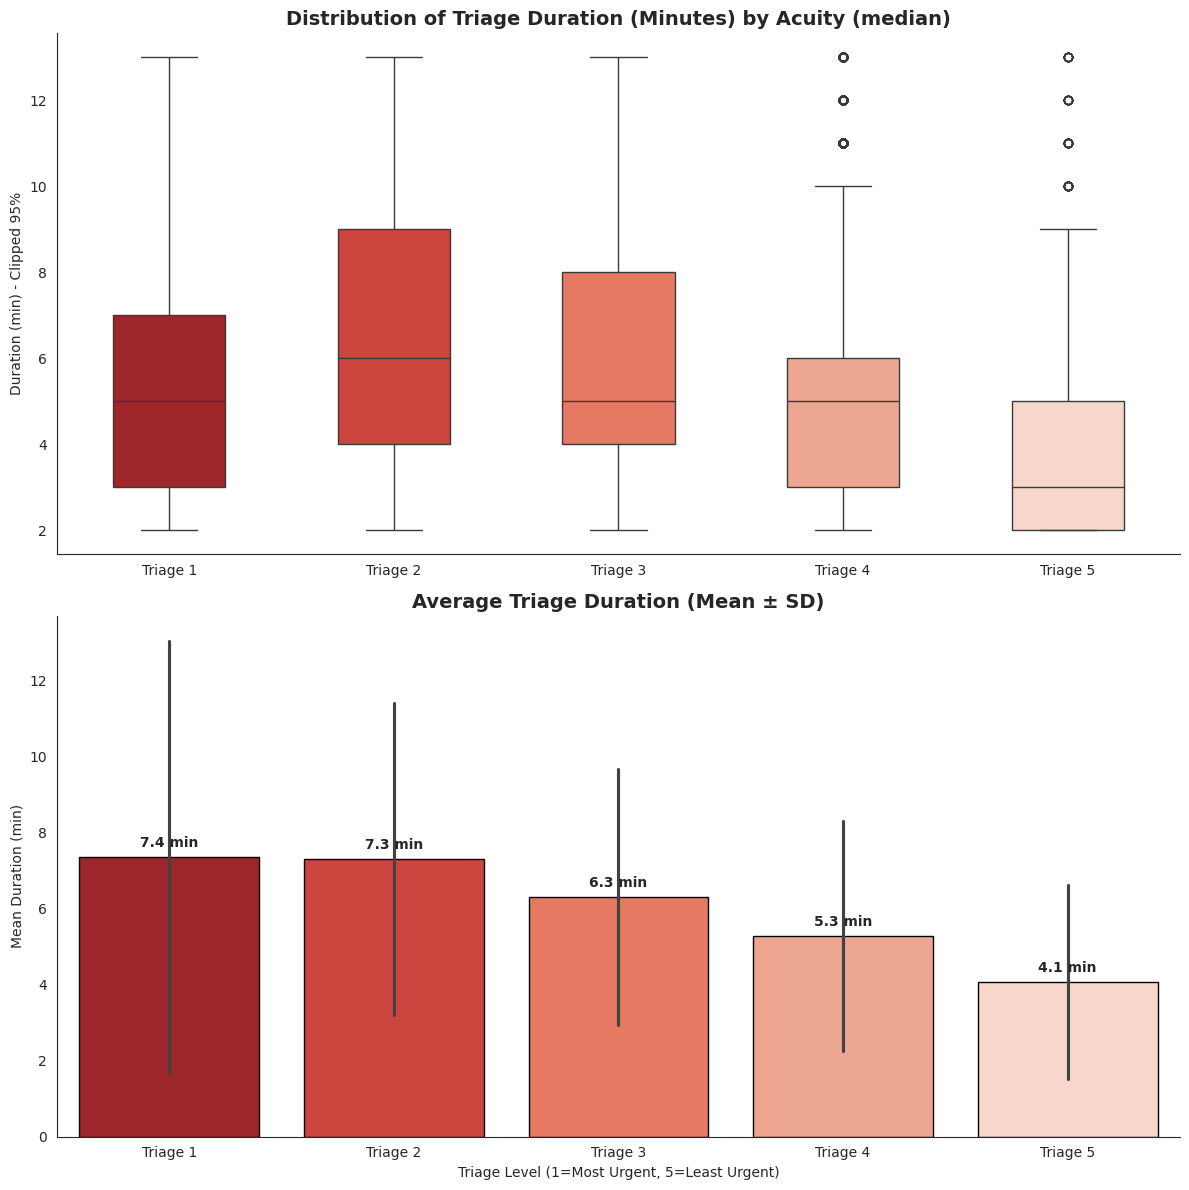

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# ================================================================
# 1. DATA PREPARATION & ORDERING
# ================================================================
df_time = df.copy()

# Ensure triage is numeric and create the ordered string label
df_time = df_time.sort_values(by='triage')
df_time['triage_label'] = 'Triage ' + df_time['triage'].astype(int).astype(str)

# Define the explicit order for categorical plotting
triage_order = ['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5']

# Filter out missing/negative values and clip outliers (95th percentile)
df_time = df_time[df_time['duration_triage_ioa_min'] > 0]
upper_limit = df_time['duration_triage_ioa_min'].quantile(0.95)
df_time_filtered = df_time[df_time['duration_triage_ioa_min'] <= upper_limit]

# ================================================================
# 2. STATISTICAL SUMMARY
# ================================================================
duration_stats = df_time.groupby('triage_label')['duration_triage_ioa_min'].agg(['mean', 'median', 'std'])
# Reindex to ensure the table follows the 1 -> 5 order
duration_stats = duration_stats.reindex(triage_order).reset_index()

print(f"📊 TRIAGE DURATION STATISTICS (Ordered 1 to 5)")
display(duration_stats.round(2))

# ================================================================
# 3. VISUALIZATION (CLEAN WHITE THEME)
# ================================================================
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), facecolor='white')

# --- Plot 1: Boxplot (Distribution) ---
sns.boxplot(data=df_time_filtered, x='triage_label', y='duration_triage_ioa_min',
            order=triage_order, palette='Reds_r', ax=ax1, width=0.5)
ax1.set_title('Distribution of Triage Duration (Minutes) by Acuity (median)', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Duration (min) - Clipped 95%')

# --- Plot 2: Barplot (Average with Error Bars) ---
sns.barplot(data=df_time, x='triage_label', y='duration_triage_ioa_min',
            order=triage_order, palette='Reds_r', ax=ax2, edgecolor='black', errorbar='sd')
ax2.set_title('Average Triage Duration (Mean ± SD)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean Duration (min)')
ax2.set_xlabel('Triage Level (1=Most Urgent, 5=Least Urgent)')

# Add mean values on top
for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f'{h:.1f} min', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', xytext=(0, 10),
                     textcoords='offset points', fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

### Repartion of biological acts (raw and by triage level) large cut

📦 RAW GLOBAL DISTRIBUTION (BIOLOGY & PROCEDURES)


,Act Type,Total Patients
0,BLOOD_TEST,17022
2,CULTURE,4295
3,BLOOD_GAS,2208
1,LUMBAR_PUNCTURE,227


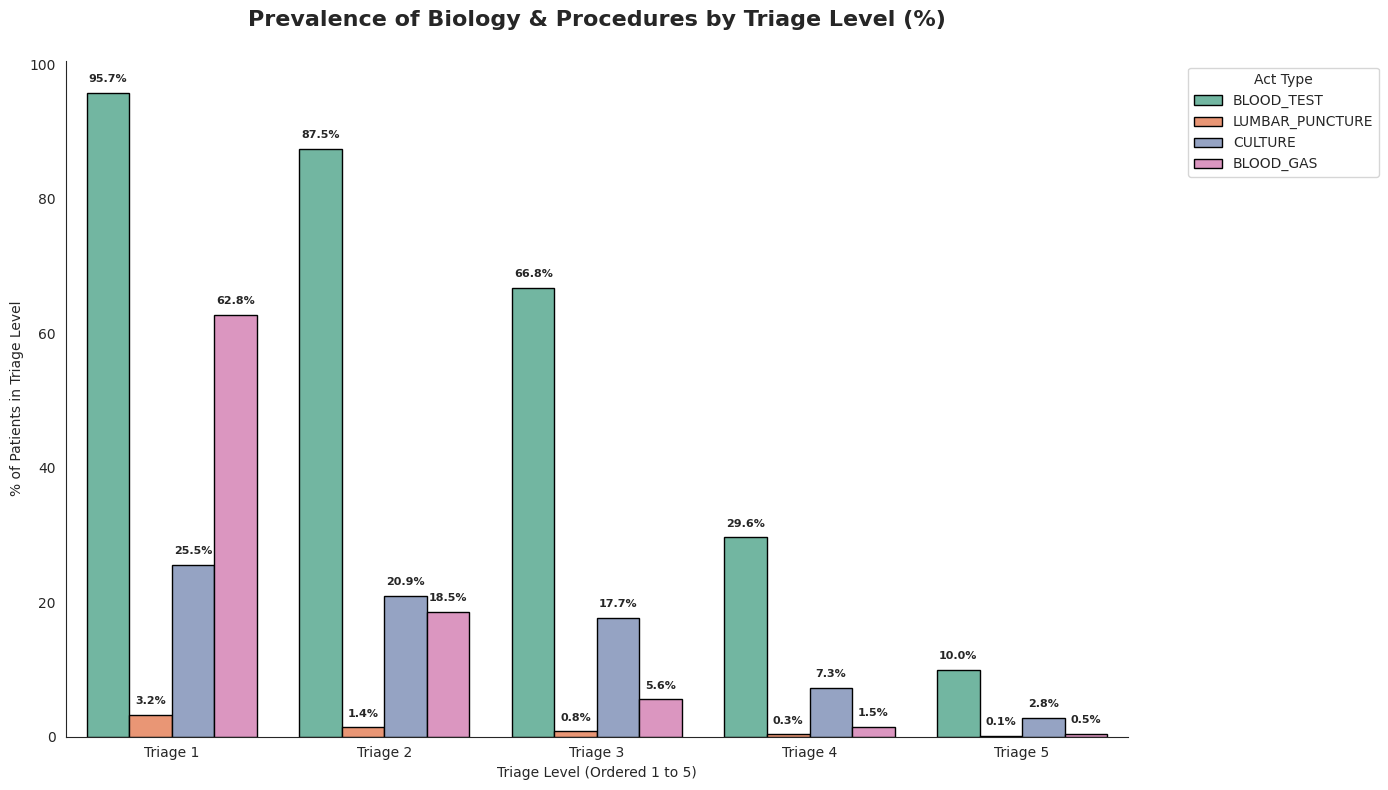

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display



#================================
# Data preparation
#================================


# Lists provided by the user
cols_veinous_analysis = [
    'is_hemoglobine', 'is_leucocytes', 'is_formule_leuco', 'is_urea', 'is_creatinine',
    'is_sodium', 'is_potassium', 'is_platelets', 'is_pt', 'is_aptt',
    'is_calcium', 'is_ck', 'is_lactates', 'is_troponine', 'is_bnp',
    'is_ckmb', 'is_ddimer', 'is_crp', 'is_pct', 'is_alat',
    'is_asat', 'is_bili_total', 'is_lipase', 'is_alp', 'is_iron',
    'is_ferritin', 'is_calcium_ionized', 'is_aXa_aIIa', 'fibrinogen'
]


# Group of focus
bio_features = ['has_blood_test', 'has_lumbar_puncture', 'has_culture', 'has_blood_gas']

# Convert bio features to integers to allow summation
df[bio_features] = df[bio_features].astype(int)


#==================
# Raw counts
#==================
raw_bio_counts = df[bio_features].sum().reset_index()
raw_bio_counts.columns = ['Act Type', 'Total Patients']
raw_bio_counts['Act Type'] = raw_bio_counts['Act Type'].str.replace('has_', '').str.upper()

print("📦 RAW GLOBAL DISTRIBUTION (BIOLOGY & PROCEDURES)")
display(raw_bio_counts.sort_values(by='Total Patients', ascending=False))


#=====================
# Order by Triage
#=====================

triage_order = ['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5']
df['triage_label'] = 'Triage ' + df['triage'].astype(int).astype(str)

# Calculate Percentages
bio_triage_dist = df.groupby('triage_label')[bio_features].mean() * 100
bio_triage_dist.columns = [c.replace('has_', '').upper() for c in bio_triage_dist.columns]
bio_triage_dist = bio_triage_dist.reindex(triage_order)

# Plotting (White Background)
sns.set_style("white")
plt.figure(figsize=(14, 8), facecolor='white')

df_plot_bio = bio_triage_dist.reset_index().melt(id_vars='triage_label', var_name='Bio Act', value_name='Percentage')

ax = sns.barplot(data=df_plot_bio, x='triage_label', y='Percentage', hue='Bio Act', palette='Set2', edgecolor='black')

plt.title('Prevalence of Biology & Procedures by Triage Level (%)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('% of Patients in Triage Level')
plt.xlabel('Triage Level (Ordered 1 to 5)')
plt.legend(title='Act Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotations
for p in ax.patches:
    h = p.get_height()
    if h > 0.1:
        ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', xytext=(0, 10),
                     textcoords='offset points', fontsize=8, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_599530/165681194.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




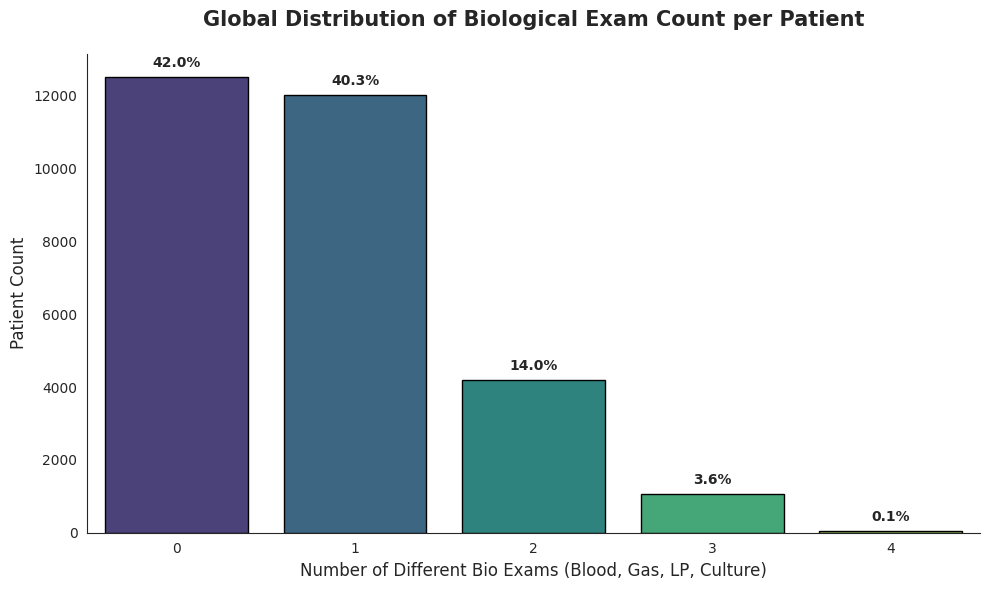

<Figure size 1200x700 with 0 Axes>

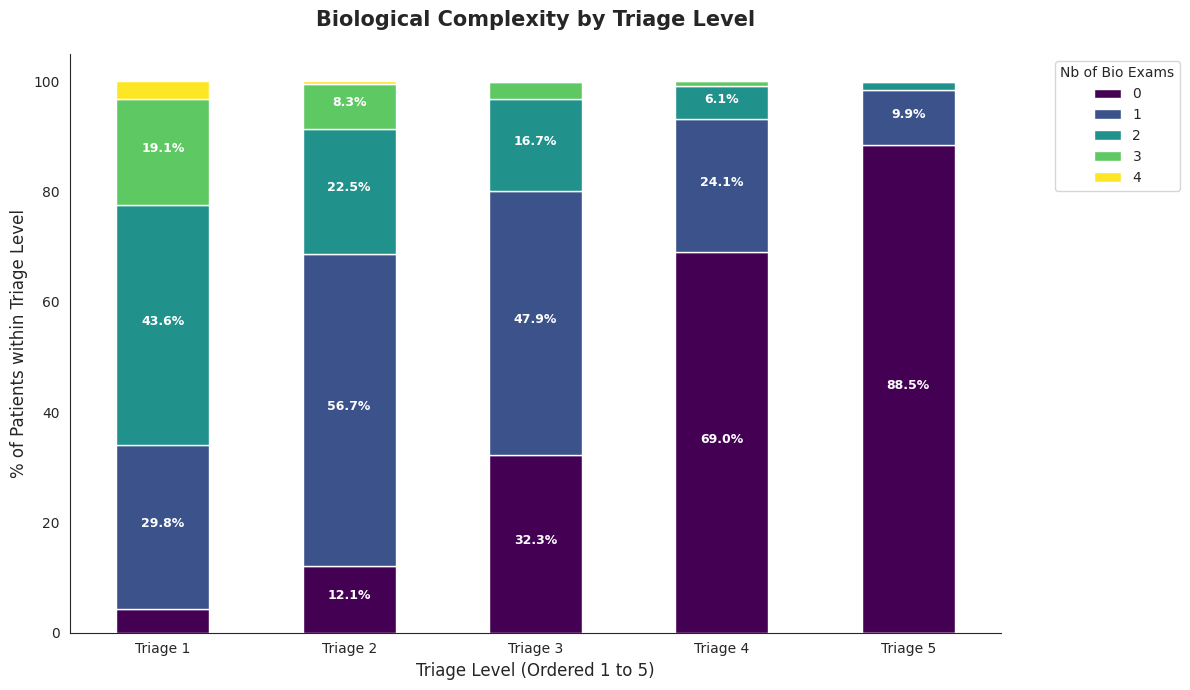

📊 BIOLOGICAL SCORE SUMMARY BY TRIAGE LEVEL:


,mean,std,max
triage_label,,,
Triage 1,1.872340,0.882738,4.0
Triage 2,1.282746,0.796941,4.0
Triage 3,0.907882,0.781689,4.0
Triage 4,0.387471,0.639763,4.0
Triage 5,0.133436,0.395740,3.0


In [79]:
#---------------------------------------------------------------------------------------------------------
# Number of bio exam per level of triage
#---------------------------------------------------------------------------------------
# Set the visual style
sns.set_style("white")

#=========================================================
# PLOT 1: GLOBAL DISTRIBUTION OF BIO SCORE
#=========================================================
plt.figure(figsize=(10, 6), facecolor='white')
ax1 = sns.countplot(data=df, x='bio_exam_count', palette='viridis', edgecolor='black')

plt.title('Global Distribution of Biological Exam Count per Patient', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Different Bio Exams (Blood, Gas, LP, Culture)', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)

# Add percentage annotations on top of bars
total_patients = len(df)
for p in ax1.patches:
    percentage = f'{100 * p.get_height() / total_patients:.1f}%'
    ax1.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                 fontweight='bold', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

#=========================================================
# PLOT 2: BIO SCORE DISTRIBUTION BY TRIAGE LEVEL
#=========================================================
# We use the 'triage_order' defined in your previous snippet
plt.figure(figsize=(12, 7), facecolor='white')

# Pivot the data to get percentages per triage level (Stacked Bar Chart)
df_prop = df.groupby('triage_label')['bio_exam_count'].value_counts(normalize=True).unstack().fillna(0) * 100
df_prop = df_prop.reindex(triage_order)

# Plotting
ax2 = df_prop.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='white', figsize=(12, 7))

plt.title('Biological Complexity by Triage Level', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Triage Level (Ordered 1 to 5)', fontsize=12)
plt.ylabel('% of Patients within Triage Level', fontsize=12)
plt.legend(title='Nb of Bio Exams', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Add simple percentage labels inside the stacks if the segment is large enough
for n, x in enumerate([*df_prop.index.values]):
    for (proportion, y_loc) in zip(df_prop.loc[x], df_prop.loc[x].cumsum()):
        if proportion > 5: # Only annotate segments > 5% for clarity
            plt.text(x=n, y=(y_loc - proportion/2), s=f'{proportion:.1f}%',
                     color="white", fontsize=9, fontweight="bold", ha="center")

sns.despine()
plt.tight_layout()
plt.show()

#=========================================================
# SUMMARY STATISTICS (English Output)
#=========================================================
print("📊 BIOLOGICAL SCORE SUMMARY BY TRIAGE LEVEL:")
summary_stats = df.groupby('triage_label')['bio_exam_count'].describe()[['mean', 'std', 'max']].reindex(triage_order)
display(summary_stats)

### EKG ###

🌍 GLOBAL EKG PREVALENCE
Total Patients: 29,839
Total EKGs performed: 7,806
Global Percentage: 26.16%



/tmp/ipykernel_599530/323580776.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




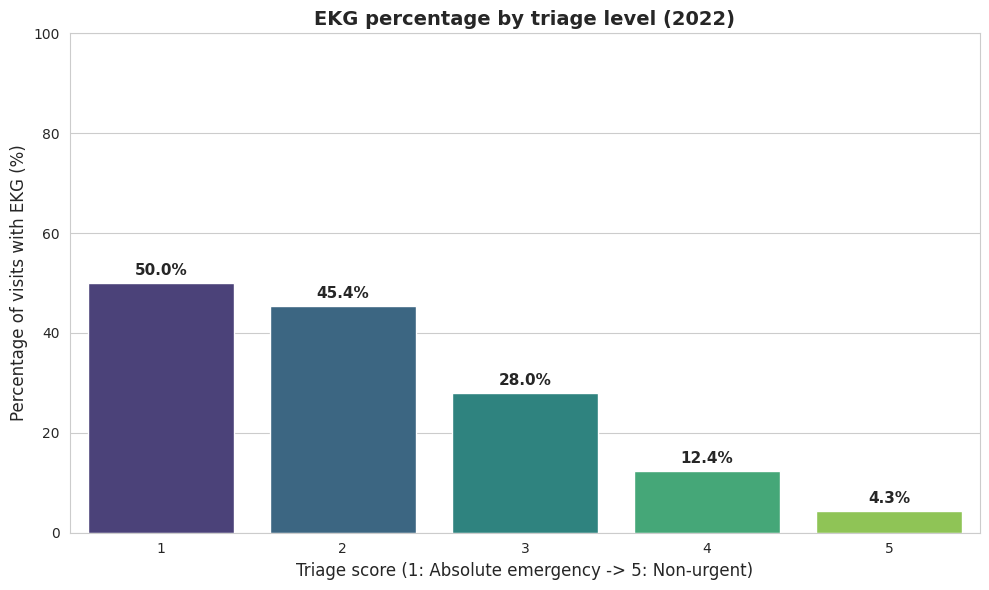


📊 EKG per triage traige level stats :
 triage  count  sum  percentage
      1     94   47   50.000000
      2   7459 3390   45.448452
      3  11279 3162   28.034400
      4   9051 1122   12.396420
      5   1956   85    4.345603


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

df['had_ekg'] = df['had_ekg'].astype(int)
# ============================================================
# GLOBAL EKG STATISTICS
# ============================================================

# Calculate global percentage
global_ekg_pct = df['had_ekg'].mean() * 100
total_patients = len(df)
total_ekg = df['had_ekg'].sum()

print(f"{'='*40}")
print(f"🌍 GLOBAL EKG PREVALENCE")
print(f"{'='*40}")
print(f"Total Patients: {total_patients:,}")
print(f"Total EKGs performed: {total_ekg:,}")
print(f"Global Percentage: {global_ekg_pct:.2f}%")
print(f"{'='*40}\n")



# ============================================================
# VISUALIZATION: EKG DISTRIBUTION BY TRIAGE SCORE
# ============================================================

# 1. Computing percentage of patient who have ekg per triage level
# filtering triage level = nan (but there is not, hopefully)
df_plot = df[df['triage'].notna()].copy()

# computing percentage
stats_ekg = df_plot.groupby('triage')['had_ekg'].agg(['count', 'sum'])
stats_ekg['percentage'] = (stats_ekg['sum'] / stats_ekg['count']) * 100
stats_ekg = stats_ekg.reset_index()

# 2. barplot building
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# drawing ekg percentage per triage level
ax = sns.barplot(x='triage', y='percentage', data=stats_ekg, palette="viridis")

# 3. config and label
plt.title('EKG percentage by triage level (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Triage score (1: Absolute emergency -> 5: Non-urgent)', fontsize=12)
plt.ylabel('Percentage of visits with EKG (%)', fontsize=12)
plt.ylim(0, 100) # Pour voir la proportion réelle sur 100

# label above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# small textual report
print("\n📊 EKG per triage traige level stats :")
print(stats_ekg[['triage', 'count', 'sum', 'percentage']].to_string(index=False))